In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [2]:
import math, random, gsw
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import minimize_scalar
from scipy.signal import find_peaks
from scipy.stats import wilcoxon, binomtest
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams["axes.unicode_minus"] = False
import numpy as np; np.set_printoptions(suppress=True)
import pandas as pd; pd.set_option('display.max_columns', None)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
print(torch.version.cuda, torch.cuda.is_available())

13.0 True


In [3]:
def _rho_from_SP_t(SP, t, p_dbar=0.0, lon=128.0, lat=35.0):
    """
    SP: Practical Salinity (array-like)
    t : in-situ temperature (°C, ITS-90)
    p_dbar: sea pressure (dbar)
    returns: rho (kg/m^3) with NaN where inputs invalid
    """
    SP = np.asarray(SP, dtype=float)
    t  = np.asarray(t, dtype=float)

    p = np.full_like(SP, float(p_dbar), dtype=float)

    m = np.isfinite(SP) & np.isfinite(t)
    rho = np.full_like(SP, np.nan, dtype=float)

    if m.sum() == 0:
        return rho

    SA = gsw.SA_from_SP(SP[m], p[m], lon, lat) # g/kg
    CT = gsw.CT_from_t(SA, t[m], p[m])         # °C
    rho[m] = gsw.rho(SA, CT, p[m])             # kg/m^3
    return rho

def add_rho_columns(
    df: pd.DataFrame,
    stations,
    sal_suffix: str = "_염분도",
    temp_suffix: str = "_수온",
    out_suffix: str = "_rho",
    p_dbar: float = 0.0,
    lon: float = 129.0,
    lat: float = 35.0,
    coords_map: dict | None = None, # {"지점명": (lon, lat)} 형태로 지점별 좌표 다르게 줄 때
    inplace: bool = False,
    strict: bool = False):          # True면 컬럼 없을 때 에러, False면 건너뜀
    """
    df에 각 지점의 rho 컬럼 추가.
    coords_map이 있으면 지점별 (lon, lat) 사용, 없으면 lon/lat 공통 사용.
    """
    out = df if inplace else df.copy()

    for st in stations:
        sal_col = f"{st}{sal_suffix}"
        tmp_col = f"{st}{temp_suffix}"
        out_col = f"{st}{out_suffix}"

        if sal_col not in out.columns or tmp_col not in out.columns:
            if strict:
                missing = [c for c in [sal_col, tmp_col] if c not in out.columns]
                raise KeyError(f"[{st}] missing columns: {missing}")
            else:
                # 없으면 스킵
                continue

        if coords_map is not None and st in coords_map:
            lon_i, lat_i = coords_map[st]
        else:
            lon_i, lat_i = lon, lat

        out[out_col] = _rho_from_SP_t(
            out[sal_col].to_numpy(dtype=float),
            out[tmp_col].to_numpy(dtype=float),
            p_dbar=p_dbar, lon=lon_i, lat=lat_i)
    return out

In [4]:
df         = pd.read_csv(r"..\낙동강하굿둑데이터_2022-2023_v4.1.csv")
df['Date'] = pd.to_datetime(df['Date'])
df         = df.sort_values('Date').reset_index(drop=True)

m               = df["Date"].dt.month - 1  # 0..11
df["month_sin"] = np.sin(2*np.pi*m/12)
df["month_cos"] = np.cos(2*np.pi*m/12)

doy           = df["Date"].dt.dayofyear - 1
year_len      = np.where(df["Date"].dt.is_leap_year, 366, 365)
df["doy_sin"] = np.sin(2*np.pi*doy/year_len)
df["doy_cos"] = np.cos(2*np.pi*doy/year_len)

dow           = df["Date"].dt.dayofweek  # 0..6 (Mon=0)
df["dow_sin"] = np.sin(2*np.pi*dow/7)
df["dow_cos"] = np.cos(2*np.pi*dow/7)

horizon_steps = (3, 6, 12)
resp_variable = '서부산낙동강교_염분도'
pi_cols = ["p_w", "I_w", "p_prev", "I_prev"]
covariance_type = "tied" # "tied", "full"
random_state = 42
# rg_cols = ["I_w", "p_w", "K_hat_w", "beta_hat_c",]
log_rg_cols = ["I_w", "p_w", "log10_K_hat_w", "beta_hat_c"]
regime_cols = log_rg_cols
regime_col = "regime_gmm"
s0_col = '을숙도선착장_염분도'
a1 = 5590 #10360.0

stations = ['을숙도선착장', '좌안배수문', '하굿둑', '서부산낙동강교', 
            '감전철교', '상류7h', '강서낙동강교', '구포대교']
df = add_rho_columns(df, stations, p_dbar=0.0, lon=128.0, lat=35.0)

display('df.shape', df.shape, 'df', df,)

'df.shape'

(9980, 57)

'df'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho
0,2022-01-01 01:00:00,8.0,9.0,26.31,8.0,7.89,4.56,0.20,12.55,2.5,-0.79,0.8300,7.900000,4.485714,0.190000,12.928571,98.441,0.0,-1.6200,0.22,8.011111,4.700000,0.180000,10.955556,5.188682,0.182758,12.419749,0.855000,8.548889,4.561667,0.216667,8.53,8.300000,4.200000,0.18,13.236364,55.2,-2.0,3.6,200.0,24.0,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.974928,-0.222521,1020.325292,1000.133910,1000.126579,1000.116328,1000.110791,1000.491619,1000.147264,1000.120401
1,2022-01-01 02:00:00,8.0,8.7,25.89,8.4,7.88,4.56,0.20,12.59,3.0,-0.63,0.8400,7.900000,4.400000,0.190000,12.900000,97.103,0.0,-1.4700,0.22,8.000000,4.700000,0.180000,10.955556,5.182669,0.182758,12.483367,0.843000,8.524444,4.540000,0.216667,8.65,8.300000,4.190909,0.18,13.227273,55.1,-2.3,2.4,230.0,24.0,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.974928,-0.222521,1020.038609,1000.133910,1000.127271,1000.116328,1000.110909,1000.483879,1000.147478,1000.120438
2,2022-01-01 03:00:00,8.0,8.6,26.64,8.3,7.88,4.51,0.20,12.63,2.9,-0.40,0.8500,7.885714,4.400000,0.190000,12.900000,94.686,0.0,-1.2500,0.22,8.000000,4.722222,0.180000,10.866667,5.206237,0.182758,12.454625,0.850000,8.548889,4.500000,0.216667,8.70,8.300000,4.181818,0.18,13.200000,55.0,-2.8,3.5,270.0,27.0,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.974928,-0.222521,1020.638671,1000.134387,1000.127271,1000.116056,1000.110444,1000.487678,1000.147852,1000.120475
3,2022-01-01 04:00:00,8.0,8.7,26.62,8.3,7.88,4.48,0.20,12.66,3.0,-0.18,0.8400,7.871429,4.385714,0.190000,12.900000,89.602,0.0,-1.0200,0.22,8.000000,4.700000,0.185556,10.866667,5.187316,0.182758,12.433419,0.852000,8.543333,4.440000,0.216667,8.66,8.300000,4.163636,0.18,13.200000,55.1,-2.3,2.4,230.0,20.0,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.974928,-0.222521,1020.609299,1000.134655,1000.127376,1000.120782,1000.110818,1000.489646,1000.148368,1000.120544
4,2022-01-01 05:00:00,8.0,8.8,23.02,8.0,7.87,4.42,0.20,12.59,2.4,0.20,0.8300,7.900000,4.300000,0.192857,12.985714,83.167,0.0,-0.6300,0.22,8.000000,4.600000,0.180000,10.877778,5.112418,0.182758,12.472134,0.852000,8.560000,4.420000,0.216667,8.72,8.300000,4.181818,0.18,13.200000,55.5,-2.2,4.2,320.0,19.0,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.974928,-0.222521,1017.782912,1000.135148,1000.130228,1000.117456,1000.112243,1000.488470,1000.148527,1000.120475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9975,2023-05-19 06:00:00,7.9,17.7,28.35,5.9,8.11,18.87,17.61,5.84,4.5,0.48,0.8615,7.200000,19.400000,0.150000,8.700000,131.304,0.0,-0.3815,0.12,7.222222,18.844444,0.151111,7.100000,18.780000,0.148000,8.042000,0.136667,18.544444,16.150000,0.181667,3.21,7.272727,18.618182,0.15,8.209091,174.1,16.1,2.7,50.0,95.0,0.01,0.0,0.866025,-0.5,0.693281,-0.720667,-0.433884,-0.900969,1020.263178,1011.814983,998.444546,998.555044,998.565162,998.601785,999.062408,998.597895
9976,2023-05-19 07:00:00,7.9,17.5,29.50,5.6,8.19,18.94,16.26,5.42,3.8,0.66,0.8722,7.200000,19.400000,0.150000,8.500000,252.136,0.0,-0.2122,0.12,7.211111,18.788889,0.150000,7.011111,18.728000,0.148000,7.994000,0.136667,18.544444,16.106667,0.181667,3.11,7.281818,18.136364,0.15,8.327273,247.3,16.3,1.9,50.0,97.0,0.09,0.1,0.866025,-0.5,0.693281,-0.720667,-0.433884,-0.900969,1021.188764,1010.774319,998.444546,998.564974,998.575218,99

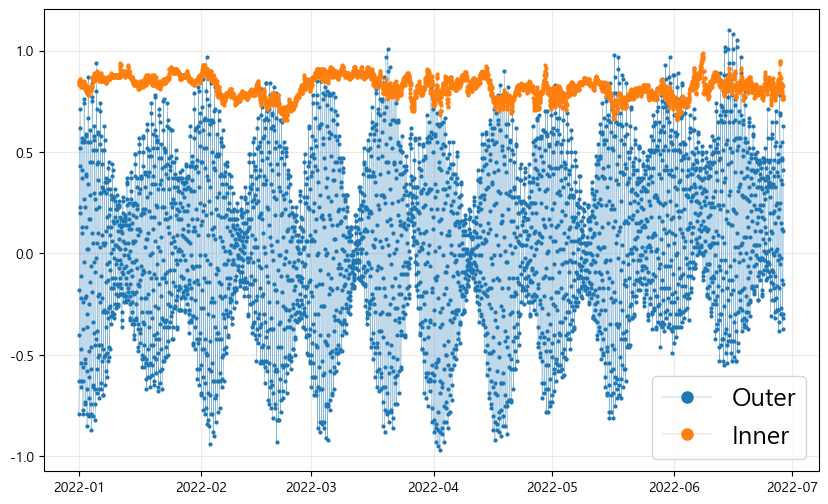

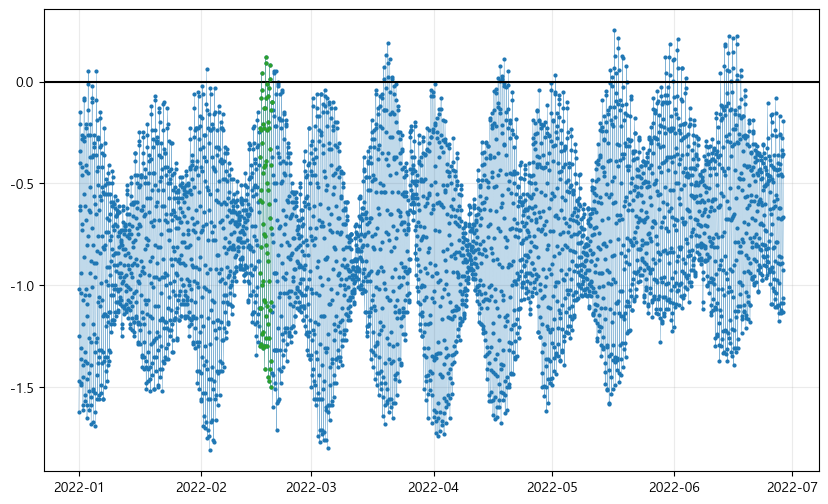

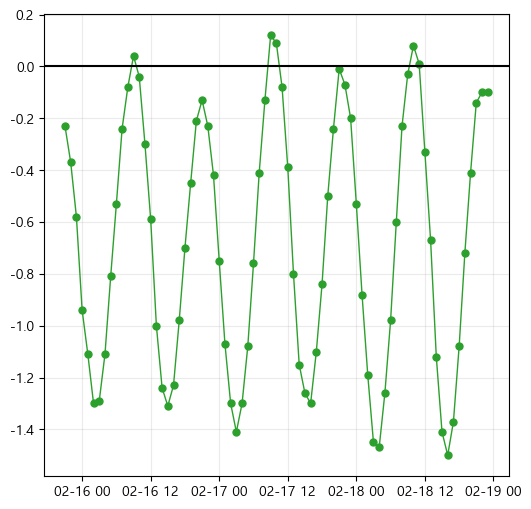

In [5]:
tr  = df[(df['Date'] <= '2022-06-29')] # SourceDomain
val = df[(df['Date'] >= '2022-09-24') & (df['Date'] < '2023-01-01')]
ts  = df[(df['Date'] >= '2023-01-01')] # TargetDomain
assert len(tr) + len(val) + len(ts) == len(df)

tr.index = tr.Date

# fig. 1
plt.figure(figsize=(10, 6))
plt.plot(tr['하굿둑_외수위(EL.m)'], linewidth=0.2, 
         marker='o', markersize=2, label=f'Outer')
plt.plot(tr['하굿둑_내수위(EL.m)'], linewidth=0.2, 
         marker='o', markersize=2, label=f'Inner')
plt.grid(alpha=.25)
plt.legend(markerscale=4, fontsize=18)
plt.show()

# fig. 2
n_head = 1100; n_tail = n_head + 75
plt.figure(figsize=(10, 6))
plt.plot(tr['하굿둑_수위차'], linewidth=0.2, 
         marker='o', markersize=2, label=f'Training')
plt.axhline(0, color='black')
plt.plot(tr['하굿둑_수위차'].iloc[n_head:n_tail], linewidth=0.1, 
         marker='o', markersize=2, label=f'Training', color='tab:green')
plt.grid(alpha=.25)
plt.show()

# fig. 3
plt.figure(figsize=(6, 6))
plt.plot(tr['하굿둑_수위차'].iloc[n_head:n_tail], linewidth=1, 
         marker='o', markersize=5, label=f'Training', color='tab:green')
plt.axhline(0, color='black')
plt.grid(alpha=.25)
plt.show()

tr.reset_index(drop=True, inplace=True)

In [6]:
def make_tide_windows_peak2peak(
    df:           pd.DataFrame,
    col:          str="하굿둑_외수위(EL.m)",
    min_period_h: float=10.0,
    prominence:   float=0.05,
    trend_window: str="48h",):
    
    df.index = df['Date']

    # slow trend 제거
    trend = df[col].rolling(trend_window, center=True, min_periods=1).mean()
    x     = (df[col] - trend).to_numpy()

    # 샘플링 간격 추정 → peak distance를 "샘플 개수"로 변환
    dt       = df.index.to_series().diff().median()
    dt_hours = float(dt / pd.Timedelta(hours=1)) if pd.notna(dt) else 1.0
    min_dist = max(1, int(round(min_period_h / dt_hours)))

    peaks, _ = find_peaks(x, distance=min_dist, prominence=prominence) # 피크의 위치 인덱스

    win = pd.Series(index=df.index, data=pd.NA, dtype="Int64")
    for k in range(len(peaks) - 1):
        a, b = peaks[k], peaks[k + 1]
        win.iloc[a:b] = k

    df_out = df.copy()
    df_out["tide_win_id"] = win

    g       = df_out.dropna(subset=["tide_win_id"]).groupby("tide_win_id")[col]
    summary = pd.DataFrame({
        "t_start":    g.apply(lambda v: v.index[0]),
        "t_end":      g.apply(lambda v: v.index[-1]),
        # "tide_mean":  g.mean(),
        # "tide_range": g.max() - g.min(),
        # "tide_std":   g.std(),
        "n":          g.size()})
    summary["tide_win_id"] = summary.index.astype("Int64")
    summary.reset_index(drop=True, inplace=True)
    return df_out, summary

In [7]:
valts = df[(df['Date'] >= '2022-09-24')]

win_tr,  sum_tr  = make_tide_windows_peak2peak(tr)
win_valts, sum_valts = make_tide_windows_peak2peak(valts)

win_tr.dropna(inplace=True);  win_tr.reset_index(drop=True, inplace=True)
win_valts.dropna(inplace=True); win_valts.reset_index(drop=True, inplace=True)

win_valts["tide_win_id"] += win_tr["tide_win_id"].max() + 1
sum_valts["tide_win_id"] += sum_tr["tide_win_id"].max() + 1

display('win_tr', win_tr, 'win_valts', win_valts,  
        'sum_tr', sum_tr, 'sum_valts', sum_valts )

'win_tr'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id
0,2022-01-01 08:00:00,8.0,9.9,30.91,7.1,7.87,4.24,0.20,12.66,3.1,0.71,0.8600,7.900000,4.000000,0.190000,13.000000,27.697,0.0,-0.1500,0.22,8.000000,4.500000,0.180000,10.811111,5.002265,0.182586,12.409491,0.841,8.433333,4.376667,0.216667,8.68,8.300000,4.090909,0.180000,13.190909,59.9,-3.3,0.4,0.0,28.0,0.03,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.779928,1000.136288,1000.128969,1000.118428,1000.114044,1000.488638,1000.148850,1000.120766,0
1,2022-01-01 09:00:00,7.9,10.1,31.53,6.6,7.87,4.08,0.20,12.74,2.8,0.52,0.8600,7.900000,4.000000,0.190000,13.100000,26.000,0.0,-0.3400,0.22,8.000000,4.500000,0.180000,10.833333,4.983407,0.182558,12.380891,0.834,8.356667,4.371667,0.216667,8.60,8.300000,4.000000,0.180000,13.200000,89.4,0.3,1.4,230.0,22.0,0.49,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1024.230911,1000.136871,1000.128969,1000.118428,1000.114335,1000.488358,1000.148886,1000.120926,0
2,2022-01-01 10:00:00,8.0,10.2,31.79,6.9,7.88,4.07,0.20,12.72,2.5,0.23,0.8400,7.900000,4.100000,0.190000,13.200000,60.924,0.0,-0.6100,0.22,8.000000,4.422222,0.182222,10.911111,4.949568,0.182311,12.418632,0.847,8.468889,4.345000,0.216667,8.58,8.300000,4.000000,0.180000,13.200000,90.1,1.8,1.2,320.0,21.0,1.13,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1024.417096,1000.136894,1000.128782,1000.120859,1000.114685,1000.490910,1000.149068,1000.120926,0
3,2022-01-01 11:00:00,8.0,9.9,30.59,7.6,7.90,4.19,0.20,13.01,2.7,-0.11,0.8300,7.900000,4.200000,0.190000,13.300000,81.139,0.0,-0.9400,0.22,8.000000,4.400000,0.180000,10.933333,4.869974,0.182243,12.421841,0.807,8.216667,4.341667,0.215000,8.56,8.300000,4.081818,0.180000,13.300000,88.0,4.3,1.3,270.0,19.0,1.66,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.530342,1000.136514,1000.128436,1000.119243,1000.115851,1000.476404,1000.147752,1000.120788,0
4,2022-01-01 12:00:00,8.1,9.4,28.05,8.2,7.94,4.29,0.20,12.95,2.4,-0.47,0.8400,7.900000,4.300000,0.190000,13.300000,89.145,0.0,-1.3100,0.22,8.011111,4.500000,0.180000,10.966667,4.980401,0.182154,12.458464,0.830,8.344444,4.348333,0.213333,8.59,8.309091,4.100000,0.180000,13.290909,81.3,5.3,1.8,250.0,19.0,2.03,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1021.625935,1000.136022,1000.127933,1000.118428,1000.114061,1000.486030,1000.146369,1000.120743,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4267,2022-06-28 03:00:00,8.0,24.5,5.32,5.9,8.05,25.42,0.25,7.30,6.1,-0.27,0.8653,8.300000,25.400000,0.237143,7.500000,905.626,0.0,-1.1353,0.29,8.222222,24.577778,1.217778,5.977778,24.585000,1.397500,6.545000,4.100,19.893333,25.750000,0.200000,4.74,8.301419,25.273555,0.160484,8.518766,287.7,24.2,11.7,230.0,100.0,0.00,0.0,0.5,-0.866025,0.077386,-0.997001,0.781831,0.623490,1001.181585,997.128648,997.124145,998.076512,998.210296,1001.350855,997.004274,997.099061,343
4268,2022-06-28 04:00:00,8.0,24.5,5.04,6.0,7.85,25.17,0.51,6.59,8.8,-0.02,0.8417,8.300000,25.371429,0.314286,7.400000,735.439,0.0,-0.8617,0.29,8.222222,24.655556,1.167778,5.933333,24.960000,1.095000,6.912500,4.100,19.893333,25.750000,0.198333,4.68,8.290302,25.303832,0.160350,8.425941,310.6,23.8,10.7,230.0,100.0,0.00,0.0,0.5,-0.866025,0.077386,-0.997001,0.781831,0.623490,1000.971483,997.390092,997.1

'win_valts'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id
0,2022-09-24 20:00:00,7.8,23.0,30.37,2.9,8.29,23.53,4.42,8.07,7.2,0.92,0.8082,8.127996,23.689557,0.430297,9.408768,223.615847,0.0,0.1118,0.10,8.098675,23.738426,0.064177,7.697442,23.250,0.090,9.010,0.110000,23.155556,23.586667,0.081667,5.36,6.420327,23.570907,0.091989,9.574930,206.7,20.6,1.5,70.0,54.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.431205,1000.752222,997.702484,997.412872,997.550718,997.588506,997.463135,997.474798,344
1,2022-09-24 21:00:00,7.8,23.1,30.43,2.7,8.24,23.50,4.75,7.78,4.7,0.89,0.8064,8.129243,23.687044,0.427987,9.415123,219.950197,0.0,0.0836,0.09,8.092494,23.734394,0.063816,7.700142,23.206,0.092,9.036,0.108889,23.155556,23.545000,0.083333,5.26,6.418823,23.566440,0.091974,9.579529,217.6,20.0,1.8,20.0,56.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.448319,1001.007929,997.701347,997.413584,997.562774,997.587662,997.474516,997.475872,344
2,2022-09-24 22:00:00,7.7,23.1,30.23,2.5,8.12,23.43,5.51,8.20,7.8,0.62,0.8067,8.130489,23.684532,0.425676,9.421478,216.284546,0.0,-0.1867,0.10,8.086313,23.730362,0.063455,7.702841,23.230,0.092,8.940,0.111111,23.155556,23.525000,0.083333,5.35,6.417318,23.561972,0.091960,9.584127,245.4,19.7,1.8,20.0,59.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.297055,1001.596881,997.700210,997.414296,997.557029,997.589350,997.479366,997.476946,344
3,2022-09-24 23:00:00,7.8,23.1,30.30,3.1,8.17,23.43,6.17,8.48,4.9,0.27,0.8120,8.131735,23.682020,0.423365,9.427833,212.618896,0.0,-0.5420,0.10,8.080132,23.726329,0.063094,7.705541,23.202,0.090,8.878,0.110000,23.183333,23.525000,0.083333,5.34,6.415813,23.557504,0.091946,9.588725,250.5,19.4,1.8,50.0,58.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.349996,1002.092967,997.699073,997.415007,997.562212,997.581869,997.479366,997.478020,344
4,2022-09-25 00:00:00,7.9,23.1,27.85,3.6,8.31,23.45,6.18,8.29,3.6,-0.10,0.8080,8.132982,23.679507,0.421055,9.434187,208.953246,0.0,-0.9080,0.10,8.073951,23.722297,0.062734,7.708240,23.202,0.094,9.036,0.104444,23.211111,23.503333,0.083333,5.26,6.414308,23.553037,0.091931,9.593323,257.5,19.5,1.9,50.0,57.0,0.00,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1018.498006,1002.095463,997.697935,997.415718,997.565251,997.571004,997.484616,997.479093,344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5671,2023-05-19 03:00:00,7.8,17.9,27.77,5.5,8.08,18.75,19.05,6.27,4.2,-0.34,0.8404,7.200000,19.400000,0.150000,8.800000,69.470000,0.0,-1.1804,0.12,7.222222,18.877778,0.152222,7.233333,18.914,0.152,8.344,0.136667,18.544444,16.066667,0.180000,2.97,7.272727,18.100000,0.150000,8.318182,114.4,15.9,3.1,50.0,98.0,0.00,0.0,0.866025,-0.5,0.693281,-0.720667,-0.433884,-0.900969,1019.773542,1012.936035,998.444546,998.549411,998.542179,998.601785,999.074787,998.695887,800
5672,2023-05-19 04:00:00,7.9,17.9,26.28,5.8,8.09,18.82,18.47,6.24,3.2,-0.11,0.8486,7.200000,19.400000,0.150000,8.800000,77.895000,0.0,-0.9586,0.11,7.233333,18.911111,0.152222,7.288889,18.930,0.148,8.396,0.136667,18.544444,16.128333,0.180000,2.76,7.281818,17.600000,0.151818,8.463636,138.7,15.9,3.0,50.0,97.0,0.00,0.5,0.866025,-0.5,0.693281,-0.720667,-0.433884,-0.900969,1018.636198,1012.479487,998.4

'sum_tr'

,t_start,t_end,n,tide_win_id
0,2022-01-01 08:00:00,2022-01-01 19:00:00,12,0
1,2022-01-01 20:00:00,2022-01-02 08:00:00,13,1
2,2022-01-02 09:00:00,2022-01-02 19:00:00,11,2
3,2022-01-02 20:00:00,2022-01-03 08:00:00,13,3
4,2022-01-03 09:00:00,2022-01-03 20:00:00,12,4
...,...,...,...,...
339,2022-06-25 19:00:00,2022-06-26 06:00:00,12,339
340,2022-06-26 07:00:00,2022-06-26 18:00:00,12,340
341,2022-06-26 19:00:00,2022-06-27 07:00:00,13,341
342,2022-06-27 08:00:00,2022-06-27 19:00:00,12,342


'sum_valts'

,t_start,t_end,n,tide_win_id
0,2022-09-24 20:00:00,2022-09-25 07:00:00,12,344
1,2022-09-25 08:00:00,2022-09-25 19:00:00,12,345
2,2022-09-25 20:00:00,2022-09-26 08:00:00,13,346
3,2022-09-26 09:00:00,2022-09-26 20:00:00,12,347
4,2022-09-26 21:00:00,2022-09-27 08:00:00,12,348
...,...,...,...,...
452,2023-05-16 18:00:00,2023-05-17 06:00:00,13,796
453,2023-05-17 07:00:00,2023-05-17 18:00:00,12,797
454,2023-05-17 19:00:00,2023-05-18 07:00:00,13,798
455,2023-05-18 08:00:00,2023-05-18 19:00:00,12,799


In [8]:
def add_phase_sin_cos_from_window_id(
    df: pd.DataFrame,
    win_col: str = "tide_win_id",
    time_col: str = "Date",    # 없으면 그룹 내 현재 row 순서를 사용
    prefix: str = "tidephi",
    drop_na_win: bool = False, # True면 tide_win_id NA 행 제거
    normalize: str = "n-1",    # "n" or "n-1"
    add_pos_n: bool = False):  # pos, n도 같이 저장할지
    """
    각 tide_win_id 내부에서 상대 위치를 위상으로 변환:
      pos = 0..n-1
      phase = 2π * pos / n     (normalize="n")  -> [0, 2π) 근사
      phase = 2π * pos / (n-1) (normalize="n-1")-> 마지막이 2π에 더 가까움(단 n=1 처리)
    """
    out = df.copy()

    if drop_na_win:
        out = out.dropna(subset=[win_col]).copy()

    # 정렬: 위상이 "시간 순서"를 따르게 하려면 반드시 정렬 권장
    if time_col in out.columns:
        out[time_col] = pd.to_datetime(out[time_col])
        out = out.sort_values([win_col, time_col])

    # 그룹 내 위치/길이
    pos = out.groupby(win_col, sort=False).cumcount()
    n   = out.groupby(win_col, sort=False)[win_col].transform("size")

    if normalize == "n-1":
        denom = (n - 1).clip(lower=1) # n=1 방어
        phase = 2.0 * np.pi * (pos / denom)
    elif normalize == "n":
        phase = 2.0 * np.pi * (pos / n)
    else:
        raise ValueError("normalize must be 'n' or 'n-1'")

    out[f"{prefix}_sin"] = np.sin(phase)
    out[f"{prefix}_cos"] = np.cos(phase)

    if add_pos_n:
        out[f"{prefix}_pos"] = pos.astype(int)
        out[f"{prefix}_n"]   = n.astype(int)

    return out

In [9]:
win_tr    = add_phase_sin_cos_from_window_id(win_tr, win_col="tide_win_id", time_col="Date", prefix="tidephi")
win_valts = add_phase_sin_cos_from_window_id(win_valts, win_col="tide_win_id", time_col="Date", prefix="tidephi")

display('win_tr', win_tr, 'win_valts', win_valts)

'win_tr'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos
0,2022-01-01 08:00:00,8.0,9.9,30.91,7.1,7.87,4.24,0.20,12.66,3.1,0.71,0.8600,7.900000,4.000000,0.190000,13.000000,27.697,0.0,-0.1500,0.22,8.000000,4.500000,0.180000,10.811111,5.002265,0.182586,12.409491,0.841,8.433333,4.376667,0.216667,8.68,8.300000,4.090909,0.180000,13.190909,59.9,-3.3,0.4,0.0,28.0,0.03,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.779928,1000.136288,1000.128969,1000.118428,1000.114044,1000.488638,1000.148850,1000.120766,0,0.0,1.0
1,2022-01-01 09:00:00,7.9,10.1,31.53,6.6,7.87,4.08,0.20,12.74,2.8,0.52,0.8600,7.900000,4.000000,0.190000,13.100000,26.000,0.0,-0.3400,0.22,8.000000,4.500000,0.180000,10.833333,4.983407,0.182558,12.380891,0.834,8.356667,4.371667,0.216667,8.60,8.300000,4.000000,0.180000,13.200000,89.4,0.3,1.4,230.0,22.0,0.49,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1024.230911,1000.136871,1000.128969,1000.118428,1000.114335,1000.488358,1000.148886,1000.120926,0,0.540641,0.841254
2,2022-01-01 10:00:00,8.0,10.2,31.79,6.9,7.88,4.07,0.20,12.72,2.5,0.23,0.8400,7.900000,4.100000,0.190000,13.200000,60.924,0.0,-0.6100,0.22,8.000000,4.422222,0.182222,10.911111,4.949568,0.182311,12.418632,0.847,8.468889,4.345000,0.216667,8.58,8.300000,4.000000,0.180000,13.200000,90.1,1.8,1.2,320.0,21.0,1.13,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1024.417096,1000.136894,1000.128782,1000.120859,1000.114685,1000.490910,1000.149068,1000.120926,0,0.909632,0.415415
3,2022-01-01 11:00:00,8.0,9.9,30.59,7.6,7.90,4.19,0.20,13.01,2.7,-0.11,0.8300,7.900000,4.200000,0.190000,13.300000,81.139,0.0,-0.9400,0.22,8.000000,4.400000,0.180000,10.933333,4.869974,0.182243,12.421841,0.807,8.216667,4.341667,0.215000,8.56,8.300000,4.081818,0.180000,13.300000,88.0,4.3,1.3,270.0,19.0,1.66,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.530342,1000.136514,1000.128436,1000.119243,1000.115851,1000.476404,1000.147752,1000.120788,0,0.989821,-0.142315
4,2022-01-01 12:00:00,8.1,9.4,28.05,8.2,7.94,4.29,0.20,12.95,2.4,-0.47,0.8400,7.900000,4.300000,0.190000,13.300000,89.145,0.0,-1.3100,0.22,8.011111,4.500000,0.180000,10.966667,4.980401,0.182154,12.458464,0.830,8.344444,4.348333,0.213333,8.59,8.309091,4.100000,0.180000,13.290909,81.3,5.3,1.8,250.0,19.0,2.03,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1021.625935,1000.136022,1000.127933,1000.118428,1000.114061,1000.486030,1000.146369,1000.120743,0,0.75575,-0.654861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4267,2022-06-28 03:00:00,8.0,24.5,5.32,5.9,8.05,25.42,0.25,7.30,6.1,-0.27,0.8653,8.300000,25.400000,0.237143,7.500000,905.626,0.0,-1.1353,0.29,8.222222,24.577778,1.217778,5.977778,24.585000,1.397500,6.545000,4.100,19.893333,25.750000,0.200000,4.74,8.301419,25.273555,0.160484,8.518766,287.7,24.2,11.7,230.0,100.0,0.00,0.0,0.5,-0.866025,0.077386,-0.997001,0.781831,0.623490,1001.181585,997.128648,997.124145,998.076512,998.210296,1001.350855,997.004274,997.099061,343,-0.75575,-0.654861
4268,2022-06-28 04:00:00,8.0,24.5,5.04,6.0,7.85,25.17,0.51,6.59,8.8,-0.02,0.8417,8.300000,25.371429,0.314286,7.400000,735.439,0.0,-0.8617,0.29,8.222222,24.655556,1.167778,5.933333,24.960000,1.095000,6.912500,4.100,19.893333,25.750000,0.198333,4.68,8.290302,25.303832,0.

'win_valts'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos
0,2022-09-24 20:00:00,7.8,23.0,30.37,2.9,8.29,23.53,4.42,8.07,7.2,0.92,0.8082,8.127996,23.689557,0.430297,9.408768,223.615847,0.0,0.1118,0.10,8.098675,23.738426,0.064177,7.697442,23.250,0.090,9.010,0.110000,23.155556,23.586667,0.081667,5.36,6.420327,23.570907,0.091989,9.574930,206.7,20.6,1.5,70.0,54.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.431205,1000.752222,997.702484,997.412872,997.550718,997.588506,997.463135,997.474798,344,0.0,1.0
1,2022-09-24 21:00:00,7.8,23.1,30.43,2.7,8.24,23.50,4.75,7.78,4.7,0.89,0.8064,8.129243,23.687044,0.427987,9.415123,219.950197,0.0,0.0836,0.09,8.092494,23.734394,0.063816,7.700142,23.206,0.092,9.036,0.108889,23.155556,23.545000,0.083333,5.26,6.418823,23.566440,0.091974,9.579529,217.6,20.0,1.8,20.0,56.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.448319,1001.007929,997.701347,997.413584,997.562774,997.587662,997.474516,997.475872,344,0.540641,0.841254
2,2022-09-24 22:00:00,7.7,23.1,30.23,2.5,8.12,23.43,5.51,8.20,7.8,0.62,0.8067,8.130489,23.684532,0.425676,9.421478,216.284546,0.0,-0.1867,0.10,8.086313,23.730362,0.063455,7.702841,23.230,0.092,8.940,0.111111,23.155556,23.525000,0.083333,5.35,6.417318,23.561972,0.091960,9.584127,245.4,19.7,1.8,20.0,59.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.297055,1001.596881,997.700210,997.414296,997.557029,997.589350,997.479366,997.476946,344,0.909632,0.415415
3,2022-09-24 23:00:00,7.8,23.1,30.30,3.1,8.17,23.43,6.17,8.48,4.9,0.27,0.8120,8.131735,23.682020,0.423365,9.427833,212.618896,0.0,-0.5420,0.10,8.080132,23.726329,0.063094,7.705541,23.202,0.090,8.878,0.110000,23.183333,23.525000,0.083333,5.34,6.415813,23.557504,0.091946,9.588725,250.5,19.4,1.8,50.0,58.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.349996,1002.092967,997.699073,997.415007,997.562212,997.581869,997.479366,997.478020,344,0.989821,-0.142315
4,2022-09-25 00:00:00,7.9,23.1,27.85,3.6,8.31,23.45,6.18,8.29,3.6,-0.10,0.8080,8.132982,23.679507,0.421055,9.434187,208.953246,0.0,-0.9080,0.10,8.073951,23.722297,0.062734,7.708240,23.202,0.094,9.036,0.104444,23.211111,23.503333,0.083333,5.26,6.414308,23.553037,0.091931,9.593323,257.5,19.5,1.9,50.0,57.0,0.00,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1018.498006,1002.095463,997.697935,997.415718,997.565251,997.571004,997.484616,997.479093,344,0.75575,-0.654861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5671,2023-05-19 03:00:00,7.8,17.9,27.77,5.5,8.08,18.75,19.05,6.27,4.2,-0.34,0.8404,7.200000,19.400000,0.150000,8.800000,69.470000,0.0,-1.1804,0.12,7.222222,18.877778,0.152222,7.233333,18.914,0.152,8.344,0.136667,18.544444,16.066667,0.180000,2.97,7.272727,18.100000,0.150000,8.318182,114.4,15.9,3.1,50.0,98.0,0.00,0.0,0.866025,-0.5,0.693281,-0.720667,-0.433884,-0.900969,1019.773542,1012.936035,998.444546,998.549411,998.542179,998.601785,999.074787,998.695887,800,-0.75575,-0.654861
5672,2023-05-19 04:00:00,7.9,17.9,26.28,5.8,8.09,18.82,18.47,6.24,3.2,-0.11,0.8486,7.200000,19.400000,0.150000,8.800000,77.895000,0.0,-0.9586,0.11,7.233333,18.911111,0.152222,7.288889,18.930,0.148,8.396,0.136667,18.544444,16.128333,0.180000,2.76,7.281818,17.600000,0.

In [10]:
def add_pI_online(
    df: pd.DataFrame,
    win_col: str = "tide_win_id",
    dh_col: str = "하굿둑_수위차",
    dh0: float = 0.0,
    use_time_integral: bool = True,
    interp_limit: int = 0,
    interp_forward_only: bool = True,
    add_prev_window: bool = True,
    mask_invalid_rows: bool = True,):
    out = df.copy()

    # DatetimeIndex 보장 + 정렬
    if not isinstance(out.index, pd.DatetimeIndex):
        if "Date" in out.columns:
            out["Date"] = pd.to_datetime(out["Date"])
            out = out.sort_values("Date")
            out.index = out["Date"]
        else:
            raise ValueError("Need DatetimeIndex or 'Date' column.")
    else:
        out = out.sort_index()

    # 윈도우 없는 행 제거
    out = out.dropna(subset=[win_col]).copy()
    out[win_col] = out[win_col].astype("Int64")

    if dh_col not in out.columns:
        raise KeyError(f"Missing dh_col: {dh_col}")

    s = out[dh_col].astype(float)

    # 온라인 보간(선택)
    if interp_limit and interp_limit > 0:
        if interp_forward_only:
            s = s.interpolate("time", limit=interp_limit, limit_direction="forward")
        else:
            s = s.interpolate("time", limit=interp_limit)

    # dt(초)
    if use_time_integral:
        dt = out.index.to_series().diff().median()
        dt_sec = float(dt / pd.Timedelta(seconds=1)) if pd.notna(dt) else 3600.0
        dt_sec = max(dt_sec, 1.0)
    else:
        dt_sec = 1.0

    valid = s.notna()

    exceed = (s > dh0).astype(float)
    exceed[~valid] = np.nan

    excess = (s - dh0).clip(lower=0.0)
    excess[~valid] = np.nan

    out["_exceed_dt"] = exceed * dt_sec
    out["_excess_dt"] = excess * dt_sec
    out["_valid_dt"]  = valid.astype(float) * dt_sec

    # GroupBy 객체에 fillna 호출하지 않기 (FutureWarning 회피)
    gb = out[win_col]

    num_p = out["_exceed_dt"].fillna(0.0).groupby(gb, sort=True).cumsum()
    num_I = out["_excess_dt"].fillna(0.0).groupby(gb, sort=True).cumsum()
    denom = out["_valid_dt"].groupby(gb, sort=True).cumsum().replace(0.0, np.nan)

    out["p_o"] = (num_p / denom).astype(float)
    out["I_o"] = (num_I / denom).astype(float)

    if mask_invalid_rows:
        out.loc[~valid, ["p_o", "I_o"]] = np.nan

    if add_prev_window:
        w_p = out["_exceed_dt"].fillna(0.0).groupby(gb, sort=True).sum()
        w_I = out["_excess_dt"].fillna(0.0).groupby(gb, sort=True).sum()
        w_T = out["_valid_dt"].groupby(gb, sort=True).sum().replace(0.0, np.nan)

        win_stat = pd.DataFrame({
            "p_w": (w_p / w_T).astype(float),
            "I_w": (w_I / w_T).astype(float),
        }).sort_index()

        win_stat["p_prev"] = win_stat["p_w"].shift(1)
        win_stat["I_prev"] = win_stat["I_w"].shift(1)

        out = out.join(win_stat[["p_prev", "I_prev"]], on=win_col)

    out.drop(columns=["_exceed_dt", "_excess_dt", "_valid_dt"], inplace=True)
    return out

In [11]:
win_tr    = add_pI_online(win_tr)
win_valts = add_pI_online(win_valts)

display('win_tr', win_tr, 'win_valts', win_valts)

'win_tr'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 08:00:00,2022-01-01 08:00:00,8.0,9.9,30.91,7.1,7.87,4.24,0.20,12.66,3.1,0.71,0.8600,7.900000,4.000000,0.190000,13.000000,27.697,0.0,-0.1500,0.22,8.000000,4.500000,0.180000,10.811111,5.002265,0.182586,12.409491,0.841,8.433333,4.376667,0.216667,8.68,8.300000,4.090909,0.180000,13.190909,59.9,-3.3,0.4,0.0,28.0,0.03,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.779928,1000.136288,1000.128969,1000.118428,1000.114044,1000.488638,1000.148850,1000.120766,0,0.0,1.0,0.0,0.0,NaN,NaN
2022-01-01 09:00:00,2022-01-01 09:00:00,7.9,10.1,31.53,6.6,7.87,4.08,0.20,12.74,2.8,0.52,0.8600,7.900000,4.000000,0.190000,13.100000,26.000,0.0,-0.3400,0.22,8.000000,4.500000,0.180000,10.833333,4.983407,0.182558,12.380891,0.834,8.356667,4.371667,0.216667,8.60,8.300000,4.000000,0.180000,13.200000,89.4,0.3,1.4,230.0,22.0,0.49,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1024.230911,1000.136871,1000.128969,1000.118428,1000.114335,1000.488358,1000.148886,1000.120926,0,0.540641,0.841254,0.0,0.0,NaN,NaN
2022-01-01 10:00:00,2022-01-01 10:00:00,8.0,10.2,31.79,6.9,7.88,4.07,0.20,12.72,2.5,0.23,0.8400,7.900000,4.100000,0.190000,13.200000,60.924,0.0,-0.6100,0.22,8.000000,4.422222,0.182222,10.911111,4.949568,0.182311,12.418632,0.847,8.468889,4.345000,0.216667,8.58,8.300000,4.000000,0.180000,13.200000,90.1,1.8,1.2,320.0,21.0,1.13,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1024.417096,1000.136894,1000.128782,1000.120859,1000.114685,1000.490910,1000.149068,1000.120926,0,0.909632,0.415415,0.0,0.0,NaN,NaN
2022-01-01 11:00:00,2022-01-01 11:00:00,8.0,9.9,30.59,7.6,7.90,4.19,0.20,13.01,2.7,-0.11,0.8300,7.900000,4.200000,0.190000,13.300000,81.139,0.0,-0.9400,0.22,8.000000,4.400000,0.180000,10.933333,4.869974,0.182243,12.421841,0.807,8.216667,4.341667,0.215000,8.56,8.300000,4.081818,0.180000,13.300000,88.0,4.3,1.3,270.0,19.0,1.66,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.530342,1000.136514,1000.128436,1000.119243,1000.115851,1000.476404,1000.147752,1000.120788,0,0.989821,-0.142315,0.0,0.0,NaN,NaN
2022-01-01 12:00:00,2022-01-01 12:00:00,8.1,9.4,28.05,8.2,7.94,4.29,0.20,12.95,2.4,-0.47,0.8400,7.900000,4.300000,0.190000,13.300000,89.145,0.0,-1.3100,0.22,8.011111,4.500000,0.180000,10.966667,4.980401,0.182154,12.458464,0.830,8.344444,4.348333,0.213333,8.59,8.309091,4.100000,0.180000,13.290909,81.3,5.3,1.8,250.0,19.0,2.03,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1021.625935,1000.136022,1000.127933,1000.118428,1000.114061,1000.486030,1000.146369,1000.120743,0,0.75575,-0.654861,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-28 03:00:00,2022-06-28 03:00:00,8.0,24.5,5.32,5.9,8.05,25.42,0.25,7.30,6.1,-0.27,0.8653,8.300000,25.400000,0.237143,7.500000,905.626,0.0,-1.1353,0.29,8.222222,24.577778,1.217778,5.977778,24.585000,1.397500,6.545000,4.100,19.893333,25.750000,0.200000,4.74,8.301419,25.273555,0.160484,8.518766,287.7,24.2,11.7,230.0,100.0,0.00,0.0,0.5,-0.866025,0.077386,-0.997001,0.781831,0.623490,1001.181585,997.128648,997.124145,998.076512,998.210296,1001.350855,997.004274,997.099061,

'win_valts'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-09-24 20:00:00,2022-09-24 20:00:00,7.8,23.0,30.37,2.9,8.29,23.53,4.42,8.07,7.2,0.92,0.8082,8.127996,23.689557,0.430297,9.408768,223.615847,0.0,0.1118,0.10,8.098675,23.738426,0.064177,7.697442,23.250,0.090,9.010,0.110000,23.155556,23.586667,0.081667,5.36,6.420327,23.570907,0.091989,9.574930,206.7,20.6,1.5,70.0,54.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.431205,1000.752222,997.702484,997.412872,997.550718,997.588506,997.463135,997.474798,344,0.0,1.0,1.000000,0.111800,NaN,NaN
2022-09-24 21:00:00,2022-09-24 21:00:00,7.8,23.1,30.43,2.7,8.24,23.50,4.75,7.78,4.7,0.89,0.8064,8.129243,23.687044,0.427987,9.415123,219.950197,0.0,0.0836,0.09,8.092494,23.734394,0.063816,7.700142,23.206,0.092,9.036,0.108889,23.155556,23.545000,0.083333,5.26,6.418823,23.566440,0.091974,9.579529,217.6,20.0,1.8,20.0,56.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.448319,1001.007929,997.701347,997.413584,997.562774,997.587662,997.474516,997.475872,344,0.540641,0.841254,1.000000,0.097700,NaN,NaN
2022-09-24 22:00:00,2022-09-24 22:00:00,7.7,23.1,30.23,2.5,8.12,23.43,5.51,8.20,7.8,0.62,0.8067,8.130489,23.684532,0.425676,9.421478,216.284546,0.0,-0.1867,0.10,8.086313,23.730362,0.063455,7.702841,23.230,0.092,8.940,0.111111,23.155556,23.525000,0.083333,5.35,6.417318,23.561972,0.091960,9.584127,245.4,19.7,1.8,20.0,59.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.297055,1001.596881,997.700210,997.414296,997.557029,997.589350,997.479366,997.476946,344,0.909632,0.415415,0.666667,0.065133,NaN,NaN
2022-09-24 23:00:00,2022-09-24 23:00:00,7.8,23.1,30.30,3.1,8.17,23.43,6.17,8.48,4.9,0.27,0.8120,8.131735,23.682020,0.423365,9.427833,212.618896,0.0,-0.5420,0.10,8.080132,23.726329,0.063094,7.705541,23.202,0.090,8.878,0.110000,23.183333,23.525000,0.083333,5.34,6.415813,23.557504,0.091946,9.588725,250.5,19.4,1.8,50.0,58.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.349996,1002.092967,997.699073,997.415007,997.562212,997.581869,997.479366,997.478020,344,0.989821,-0.142315,0.500000,0.048850,NaN,NaN
2022-09-25 00:00:00,2022-09-25 00:00:00,7.9,23.1,27.85,3.6,8.31,23.45,6.18,8.29,3.6,-0.10,0.8080,8.132982,23.679507,0.421055,9.434187,208.953246,0.0,-0.9080,0.10,8.073951,23.722297,0.062734,7.708240,23.202,0.094,9.036,0.104444,23.211111,23.503333,0.083333,5.26,6.414308,23.553037,0.091931,9.593323,257.5,19.5,1.9,50.0,57.0,0.00,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1018.498006,1002.095463,997.697935,997.415718,997.565251,997.571004,997.484616,997.479093,344,0.75575,-0.654861,0.400000,0.039080,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-05-19 03:00:00,2023-05-19 03:00:00,7.8,17.9,27.77,5.5,8.08,18.75,19.05,6.27,4.2,-0.34,0.8404,7.200000,19.400000,0.150000,8.800000,69.470000,0.0,-1.1804,0.12,7.222222,18.877778,0.152222,7.233333,18.914,0.152,8.344,0.136667,18.544444,16.066667,0.180000,2.97,7.272727,18.100000,0.150000,8.318182,114.4,15.9,3.1,50.0,98.0,0.00,0.0,0.866025,-0.5,0.693281,-0.720667,-0.433884,-0.900969,1019.773542,1012.936035,998.444546,998

In [12]:
def compute_pI_by_tide_window(
    df_with_win:       pd.DataFrame,
    win_col:           str = "tide_win_id",
    dh_col:            str = "하굿둑_수위차", # Δh 컬럼명 (out-in이든 in-out이든 본인 정의에 맞게)
    dh0:               float = 0.0, # Δh_0 사용자가 지정
    use_time_integral: bool = True, # True면 dt를 반영한 적분형 I 계산
    interp_limit:      int = 0):
    
    df_out = df_with_win.copy()

    # DateTimeIndex 세팅
    if not isinstance(df_out.index, pd.DatetimeIndex):
        if "Date" in df_out.columns:
            df_out["Date"] = pd.to_datetime(df_out["Date"])
            df_out = df_out.sort_values("Date")
            df_out.index = df_out["Date"]
        else:
            raise ValueError("df_with_win must have a DatetimeIndex or a 'Date' column.")

    # (권장) 중복 timestamp 제거
    df_out = df_out[~df_out.index.duplicated(keep="first")]

    # 윈도우 없는 행 제거
    df_out = df_out.dropna(subset=[win_col]).copy()
    df_out[win_col] = df_out[win_col].astype("Int64")

    # Δh 시계열
    s = df_out[dh_col].astype(float)
    if interp_limit and interp_limit > 0:
        s = s.interpolate("time", limit=interp_limit)

    df_out["delta_h"] = s

    # 대표 dt(초)
    dt = df_out.index.to_series().diff().median()
    dt_sec = float(dt / pd.Timedelta(seconds=1)) if pd.notna(dt) else 0.0

    # exceed: 임계치 초과 여부
    df_out["exceed"] = (s > dh0).where(s.notna())  # True/False/NA

    # excess: 임계치 초과량
    df_out["excess"] = (s - dh0).clip(lower=0.0).where(s.notna())

    # 적분 기여량
    if use_time_integral and dt_sec > 0:
        df_out["excess_dt"] = df_out["excess"] * dt_sec
    else:
        df_out["excess_dt"] = df_out["excess"]

    g = df_out.groupby(win_col, sort=True)

    # p_w
    p_w = g["exceed"].mean().rename("p_w")  # NA는 자동 제외

    idx_s = df_out.index.to_series()
    t_start = idx_s.groupby(df_out[win_col]).min().rename("t_start")
    t_end   = idx_s.groupby(df_out[win_col]).max().rename("t_end")

    # I_w
    if use_time_integral and dt_sec > 0:
        T_w_sec = (t_end - t_start).dt.total_seconds() + dt_sec
        T_w_sec = T_w_sec.clip(lower=dt_sec)

        int_excess = g["excess_dt"].sum().rename("int_excess")
        I_w = (int_excess / T_w_sec).rename("I_w")
    else:
        I_w = g["excess"].mean().rename("I_w")

    n = g.size().rename("n")
    n_valid = g["delta_h"].apply(lambda x: x.notna().sum()).rename("n_valid")
    frac_valid = (n_valid / n).rename("frac_valid")

    summary = pd.concat([t_start, t_end, n, 
                        #  n_valid, frac_valid, 
                         p_w, I_w], axis=1).reset_index()

    df_out = df_out.join(summary.set_index(win_col)[["p_w", "I_w"]], on=win_col)
    
    df_out.drop(columns=['delta_h', 'exceed', 'excess', 'excess_dt'], inplace=True)
    df_out.reset_index(drop=True, inplace=True)
    return df_out, summary

In [13]:
win_tr_s,  sum_tr_s  = compute_pI_by_tide_window(win_tr)
win_valts_s, sum_valts_s = compute_pI_by_tide_window(win_valts)

sum_tr_s['p_prev'] = sum_tr_s['p_w'].shift(1)
sum_tr_s['I_prev'] = sum_tr_s['I_w'].shift(1)
sum_valts_s['p_prev'] = sum_valts_s['p_w'].shift(1)
sum_valts_s['I_prev'] = sum_valts_s['I_w'].shift(1)

display('win_tr_s', win_tr_s, 'win_valts_s', win_valts_s, 
        'sum_tr_s', sum_tr_s, 'sum_valts_s', sum_valts_s)

'win_tr_s'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w
0,2022-01-01 08:00:00,8.0,9.9,30.91,7.1,7.87,4.24,0.20,12.66,3.1,0.71,0.8600,7.900000,4.000000,0.190000,13.000000,27.697,0.0,-0.1500,0.22,8.000000,4.500000,0.180000,10.811111,5.002265,0.182586,12.409491,0.841,8.433333,4.376667,0.216667,8.68,8.300000,4.090909,0.180000,13.190909,59.9,-3.3,0.4,0.0,28.0,0.03,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.779928,1000.136288,1000.128969,1000.118428,1000.114044,1000.488638,1000.148850,1000.120766,0,0.0,1.0,0.0,0.0,NaN,NaN,0.0,0.0
1,2022-01-01 09:00:00,7.9,10.1,31.53,6.6,7.87,4.08,0.20,12.74,2.8,0.52,0.8600,7.900000,4.000000,0.190000,13.100000,26.000,0.0,-0.3400,0.22,8.000000,4.500000,0.180000,10.833333,4.983407,0.182558,12.380891,0.834,8.356667,4.371667,0.216667,8.60,8.300000,4.000000,0.180000,13.200000,89.4,0.3,1.4,230.0,22.0,0.49,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1024.230911,1000.136871,1000.128969,1000.118428,1000.114335,1000.488358,1000.148886,1000.120926,0,0.540641,0.841254,0.0,0.0,NaN,NaN,0.0,0.0
2,2022-01-01 10:00:00,8.0,10.2,31.79,6.9,7.88,4.07,0.20,12.72,2.5,0.23,0.8400,7.900000,4.100000,0.190000,13.200000,60.924,0.0,-0.6100,0.22,8.000000,4.422222,0.182222,10.911111,4.949568,0.182311,12.418632,0.847,8.468889,4.345000,0.216667,8.58,8.300000,4.000000,0.180000,13.200000,90.1,1.8,1.2,320.0,21.0,1.13,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1024.417096,1000.136894,1000.128782,1000.120859,1000.114685,1000.490910,1000.149068,1000.120926,0,0.909632,0.415415,0.0,0.0,NaN,NaN,0.0,0.0
3,2022-01-01 11:00:00,8.0,9.9,30.59,7.6,7.90,4.19,0.20,13.01,2.7,-0.11,0.8300,7.900000,4.200000,0.190000,13.300000,81.139,0.0,-0.9400,0.22,8.000000,4.400000,0.180000,10.933333,4.869974,0.182243,12.421841,0.807,8.216667,4.341667,0.215000,8.56,8.300000,4.081818,0.180000,13.300000,88.0,4.3,1.3,270.0,19.0,1.66,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.530342,1000.136514,1000.128436,1000.119243,1000.115851,1000.476404,1000.147752,1000.120788,0,0.989821,-0.142315,0.0,0.0,NaN,NaN,0.0,0.0
4,2022-01-01 12:00:00,8.1,9.4,28.05,8.2,7.94,4.29,0.20,12.95,2.4,-0.47,0.8400,7.900000,4.300000,0.190000,13.300000,89.145,0.0,-1.3100,0.22,8.011111,4.500000,0.180000,10.966667,4.980401,0.182154,12.458464,0.830,8.344444,4.348333,0.213333,8.59,8.309091,4.100000,0.180000,13.290909,81.3,5.3,1.8,250.0,19.0,2.03,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1021.625935,1000.136022,1000.127933,1000.118428,1000.114061,1000.486030,1000.146369,1000.120743,0,0.75575,-0.654861,0.0,0.0,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4267,2022-06-28 03:00:00,8.0,24.5,5.32,5.9,8.05,25.42,0.25,7.30,6.1,-0.27,0.8653,8.300000,25.400000,0.237143,7.500000,905.626,0.0,-1.1353,0.29,8.222222,24.577778,1.217778,5.977778,24.585000,1.397500,6.545000,4.100,19.893333,25.750000,0.200000,4.74,8.301419,25.273555,0.160484,8.518766,287.7,24.2,11.7,230.0,100.0,0.00,0.0,0.5,-0.866025,0.077386,-0.997001,0.781831,0.623490,1001.181585,997.128648,997.124145,998.076512,998.210296,1001.350855,997.004274,997.099061,343,-0.75575,-0.654861,0.0,0.0,0.0,0.0,0.0,0.0
4268,2022-06-28 04:00:00,8.0,24.5,5.04,6.0,7.85,25.17,0.51,6.59,8.8,-0.

'win_valts_s'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w
0,2022-09-24 20:00:00,7.8,23.0,30.37,2.9,8.29,23.53,4.42,8.07,7.2,0.92,0.8082,8.127996,23.689557,0.430297,9.408768,223.615847,0.0,0.1118,0.10,8.098675,23.738426,0.064177,7.697442,23.250,0.090,9.010,0.110000,23.155556,23.586667,0.081667,5.36,6.420327,23.570907,0.091989,9.574930,206.7,20.6,1.5,70.0,54.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.431205,1000.752222,997.702484,997.412872,997.550718,997.588506,997.463135,997.474798,344,0.0,1.0,1.000000,0.111800,NaN,NaN,0.166667,0.016283
1,2022-09-24 21:00:00,7.8,23.1,30.43,2.7,8.24,23.50,4.75,7.78,4.7,0.89,0.8064,8.129243,23.687044,0.427987,9.415123,219.950197,0.0,0.0836,0.09,8.092494,23.734394,0.063816,7.700142,23.206,0.092,9.036,0.108889,23.155556,23.545000,0.083333,5.26,6.418823,23.566440,0.091974,9.579529,217.6,20.0,1.8,20.0,56.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.448319,1001.007929,997.701347,997.413584,997.562774,997.587662,997.474516,997.475872,344,0.540641,0.841254,1.000000,0.097700,NaN,NaN,0.166667,0.016283
2,2022-09-24 22:00:00,7.7,23.1,30.23,2.5,8.12,23.43,5.51,8.20,7.8,0.62,0.8067,8.130489,23.684532,0.425676,9.421478,216.284546,0.0,-0.1867,0.10,8.086313,23.730362,0.063455,7.702841,23.230,0.092,8.940,0.111111,23.155556,23.525000,0.083333,5.35,6.417318,23.561972,0.091960,9.584127,245.4,19.7,1.8,20.0,59.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.297055,1001.596881,997.700210,997.414296,997.557029,997.589350,997.479366,997.476946,344,0.909632,0.415415,0.666667,0.065133,NaN,NaN,0.166667,0.016283
3,2022-09-24 23:00:00,7.8,23.1,30.30,3.1,8.17,23.43,6.17,8.48,4.9,0.27,0.8120,8.131735,23.682020,0.423365,9.427833,212.618896,0.0,-0.5420,0.10,8.080132,23.726329,0.063094,7.705541,23.202,0.090,8.878,0.110000,23.183333,23.525000,0.083333,5.34,6.415813,23.557504,0.091946,9.588725,250.5,19.4,1.8,50.0,58.0,0.00,0.0,-0.866025,-0.5,-0.991114,-0.133015,-0.974928,-0.222521,1020.349996,1002.092967,997.699073,997.415007,997.562212,997.581869,997.479366,997.478020,344,0.989821,-0.142315,0.500000,0.048850,NaN,NaN,0.166667,0.016283
4,2022-09-25 00:00:00,7.9,23.1,27.85,3.6,8.31,23.45,6.18,8.29,3.6,-0.10,0.8080,8.132982,23.679507,0.421055,9.434187,208.953246,0.0,-0.9080,0.10,8.073951,23.722297,0.062734,7.708240,23.202,0.094,9.036,0.104444,23.211111,23.503333,0.083333,5.26,6.414308,23.553037,0.091931,9.593323,257.5,19.5,1.9,50.0,57.0,0.00,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1018.498006,1002.095463,997.697935,997.415718,997.565251,997.571004,997.484616,997.479093,344,0.75575,-0.654861,0.400000,0.039080,NaN,NaN,0.166667,0.016283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5671,2023-05-19 03:00:00,7.8,17.9,27.77,5.5,8.08,18.75,19.05,6.27,4.2,-0.34,0.8404,7.200000,19.400000,0.150000,8.800000,69.470000,0.0,-1.1804,0.12,7.222222,18.877778,0.152222,7.233333,18.914,0.152,8.344,0.136667,18.544444,16.066667,0.180000,2.97,7.272727,18.100000,0.150000,8.318182,114.4,15.9,3.1,50.0,98.0,0.00,0.0,0.866025,-0.5,0.693281,-0.720667,-0.433884,-0.900969,1019.773542,1012.936035,998.444546,998.549411,998.542179,998.601785,999.074787,998.695887,800,-0.75575,-0.

'sum_tr_s'

,tide_win_id,t_start,t_end,n,p_w,I_w,p_prev,I_prev
0,0,2022-01-01 08:00:00,2022-01-01 19:00:00,12,0.000000,0.000000,NaN,NaN
1,1,2022-01-01 20:00:00,2022-01-02 08:00:00,13,0.000000,0.000000,0.0,0.0
2,2,2022-01-02 09:00:00,2022-01-02 19:00:00,11,0.000000,0.000000,0.0,0.0
3,3,2022-01-02 20:00:00,2022-01-03 08:00:00,13,0.000000,0.000000,0.0,0.0
4,4,2022-01-03 09:00:00,2022-01-03 20:00:00,12,0.083333,0.004167,0.0,0.0
...,...,...,...,...,...,...,...,...
339,339,2022-06-25 19:00:00,2022-06-26 06:00:00,12,0.000000,0.000000,0.0,0.0
340,340,2022-06-26 07:00:00,2022-06-26 18:00:00,12,0.000000,0.000000,0.0,0.0
341,341,2022-06-26 19:00:00,2022-06-27 07:00:00,13,0.000000,0.000000,0.0,0.0
342,342,2022-06-27 08:00:00,2022-06-27 19:00:00,12,0.000000,0.000000,0.0,0.0


'sum_valts_s'

,tide_win_id,t_start,t_end,n,p_w,I_w,p_prev,I_prev
0,344,2022-09-24 20:00:00,2022-09-25 07:00:00,12,0.166667,0.016283,NaN,NaN
1,345,2022-09-25 08:00:00,2022-09-25 19:00:00,12,0.166667,0.002000,0.166667,0.016283
2,346,2022-09-25 20:00:00,2022-09-26 08:00:00,13,0.153846,0.014038,0.166667,0.002000
3,347,2022-09-26 09:00:00,2022-09-26 20:00:00,12,0.000000,0.000000,0.153846,0.014038
4,348,2022-09-26 21:00:00,2022-09-27 08:00:00,12,0.250000,0.014167,0.000000,0.000000
...,...,...,...,...,...,...,...,...
452,796,2023-05-16 18:00:00,2023-05-17 06:00:00,13,0.000000,0.000000,0.000000,0.000000
453,797,2023-05-17 07:00:00,2023-05-17 18:00:00,12,0.000000,0.000000,0.000000,0.000000
454,798,2023-05-17 19:00:00,2023-05-18 07:00:00,13,0.000000,0.000000,0.000000,0.000000
455,799,2023-05-18 08:00:00,2023-05-18 19:00:00,12,0.083333,0.001183,0.000000,0.000000


In [14]:
win_tr_s.dropna(inplace=True)
win_valts_s.dropna(inplace=True)
sum_tr_s.dropna(inplace=True)
sum_valts_s.dropna(inplace=True)

win_tr_s.reset_index(drop=True, inplace=True)
win_valts_s.reset_index(drop=True, inplace=True)
sum_tr_s.reset_index(drop=True, inplace=True)
sum_valts_s.reset_index(drop=True, inplace=True)

display('win_tr_s', win_tr_s, 'win_valts_s', win_valts_s, 
        'sum_tr_s', sum_tr_s, 'sum_valts_s', sum_valts_s)

'win_tr_s'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w
0,2022-01-01 20:00:00,8.0,9.6,30.24,7.5,7.89,4.61,0.20,12.66,2.3,0.57,0.8300,7.900000,4.400000,0.195714,13.171429,71.248,0.0,-0.2600,0.22,8.055556,4.466667,0.180000,11.033333,4.974019,0.182687,12.483997,0.831,8.425556,4.380000,0.218333,8.56,8.381818,4.300000,0.180000,13.400000,78.2,2.1,0.5,290.0,22.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.304712,1000.133393,1000.131859,1000.118717,1000.114592,1000.481286,1000.150165,1000.119901,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-01-01 21:00:00,8.0,9.3,29.46,8.1,7.88,4.61,0.20,12.58,2.3,0.41,0.8300,7.900000,4.400000,0.190000,13.100000,72.721,0.0,-0.4200,0.22,8.066667,4.500000,0.180000,11.022222,5.006364,0.182754,12.540709,0.834,8.450000,4.378333,0.216667,8.68,8.363636,4.200000,0.180000,13.400000,78.1,2.6,2.1,320.0,18.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.741808,1000.133393,1000.127271,1000.118428,1000.114110,1000.481967,1000.148839,1000.120401,1,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-01-01 22:00:00,8.0,9.4,29.92,7.9,7.89,4.60,0.20,12.59,2.3,0.13,0.8300,7.900000,4.400000,0.190000,13.085714,77.288,0.0,-0.7000,0.22,8.077778,4.600000,0.180000,11.033333,5.078255,0.182759,12.409776,0.830,8.421111,4.373333,0.216667,8.42,8.327273,4.200000,0.180000,13.400000,77.8,2.1,1.3,320.0,20.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.085830,1000.133499,1000.127271,1000.117456,1000.112865,1000.480803,1000.148874,1000.120401,1,0.866025,0.5,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-01-01 23:00:00,8.1,9.4,29.01,8.2,7.89,4.57,0.20,12.58,2.2,-0.24,0.8300,7.900000,4.385714,0.190000,13.100000,83.911,0.0,-1.0700,0.22,8.077778,4.600000,0.180000,11.033333,5.075522,0.182760,12.499902,0.828,8.410000,4.366667,0.215000,8.59,8.309091,4.163636,0.180000,13.400000,77.5,2.3,1.4,290.0,21.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.375304,1000.133809,1000.127376,1000.117456,1000.112915,1000.479988,1000.147583,1000.120544,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-01-02 00:00:00,8.0,9.4,28.84,8.0,7.90,4.52,0.20,12.73,2.3,-0.56,0.8300,7.900000,4.300000,0.190000,13.100000,91.226,0.0,-1.3900,0.22,8.055556,4.600000,0.180000,11.000000,5.073063,0.182759,12.526897,0.826,8.400000,4.366667,0.215000,8.68,8.300000,4.190909,0.180000,13.336364,77.5,2.3,1.6,320.0,21.0,0.00,0.0,0.0,1.000000,0.017213,0.999852,-0.781831,0.623490,1022.242589,1000.134295,1000.127933,1000.117456,1000.112958,1000.479095,1000.147583,1000.120438,1,0.866025,-0.5,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4255,2022-06-28 03:00:00,8.0,24.5,5.32,5.9,8.05,25.42,0.25,7.30,6.1,-0.27,0.8653,8.300000,25.400000,0.237143,7.500000,905.626,0.0,-1.1353,0.29,8.222222,24.577778,1.217778,5.977778,24.585000,1.397500,6.545000,4.100,19.893333,25.750000,0.200000,4.74,8.301419,25.273555,0.160484,8.518766,287.7,24.2,11.7,230.0,100.0,0.00,0.0,0.5,-0.866025,0.077386,-0.997001,0.781831,0.623490,1001.181585,997.128648,997.124145,998.076512,998.210296,1001.350855,997.004274,997.099061,343,-0.75575,-0.654861,0.0,0.0,0.0,0.0,0.0,0.0
4256,2022-06-28 04:00:00,8.0,24.5,5.04,6.0,7.85,25.17,0.51,6.59,8.8,-0.02,0.8417,8.300000,25.37142

'win_valts_s'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w
0,2022-09-25 08:00:00,7.8,23.1,29.80,3.4,8.00,23.06,6.86,7.70,6.5,0.80,0.7870,8.142953,23.659409,0.402570,9.485025,179.628044,0.0,0.0130,0.10,8.024503,23.690038,0.059848,7.729837,23.254,0.104,9.094,0.131111,23.212222,23.500000,0.095000,5.64,6.402270,23.517297,0.091817,9.630107,170.4,19.6,3.0,70.0,63.0,0.32,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1019.971881,1002.703989,997.688834,997.421404,997.560392,997.590993,997.494280,997.487674,345,0.0,1.0,1.000000,0.013000,0.166667,0.016283,0.166667,0.002000
1,2022-09-25 09:00:00,7.8,23.1,28.69,3.3,8.09,23.08,6.96,7.55,4.5,0.80,0.7890,8.144199,23.656897,0.400259,9.491379,175.962393,0.0,0.0110,0.10,8.018322,23.686005,0.059487,7.732536,23.246,0.102,9.154,0.142222,23.238889,23.480000,0.098333,5.37,6.400765,23.512829,0.091803,9.634706,166.4,21.1,2.2,50.0,61.0,0.74,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1019.132757,1002.774200,997.687696,997.422114,997.560791,997.593044,997.501652,997.488745,345,0.540641,0.841254,1.000000,0.012000,0.166667,0.016283,0.166667,0.002000
2,2022-09-25 10:00:00,7.9,23.1,12.15,4.2,7.98,23.08,7.09,7.14,8.2,0.59,0.7820,8.145446,23.654384,0.397948,9.497734,172.296743,0.0,-0.1920,0.09,8.012141,23.681973,0.059126,7.735236,23.246,0.104,9.216,0.145556,23.224444,23.500000,0.080000,4.36,6.399261,23.508362,0.091788,9.639304,181.9,20.9,2.3,50.0,65.0,0.67,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1006.669772,1002.871932,997.686558,997.422823,997.562310,997.599036,997.482892,997.489817,345,0.909632,0.415415,0.666667,0.008000,0.166667,0.016283,0.166667,0.002000
3,2022-09-25 11:00:00,7.9,23.0,24.60,3.7,8.02,23.00,7.98,7.45,6.5,0.34,0.7740,8.146692,23.651872,0.395638,9.504089,168.631093,0.0,-0.4340,0.10,8.005960,23.677941,0.058765,7.737935,23.194,0.102,9.322,0.138889,23.197778,23.480000,0.278333,5.54,6.397756,23.503894,0.091774,9.643902,206.6,21.3,2.5,50.0,63.0,0.70,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1016.071616,1003.560918,997.685419,997.423533,997.573241,997.600357,997.638257,997.490888,345,0.989821,-0.142315,0.500000,0.006000,0.166667,0.016283,0.166667,0.002000
4,2022-09-25 12:00:00,7.9,23.0,25.07,3.6,8.11,23.03,8.05,6.92,4.3,0.02,0.7725,8.147939,23.649360,0.393327,9.510443,164.965443,0.0,-0.7525,0.10,7.999779,23.673908,0.058405,7.740635,23.194,0.100,9.216,0.142222,23.212222,23.460000,0.283333,5.65,6.396251,23.499426,0.091760,9.648500,226.1,22.4,2.2,70.0,60.0,1.10,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1016.426352,1003.606044,997.684281,997.424242,997.571722,997.599431,997.646894,997.491959,345,0.75575,-0.654861,0.400000,0.004800,0.166667,0.016283,0.166667,0.002000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5659,2023-05-19 03:00:00,7.8,17.9,27.77,5.5,8.08,18.75,19.05,6.27,4.2,-0.34,0.8404,7.200000,19.400000,0.150000,8.800000,69.470000,0.0,-1.1804,0.12,7.222222,18.877778,0.152222,7.233333,18.914,0.152,8.344,0.136667,18.544444,16.066667,0.180000,2.97,7.272727,18.100000,0.150000,8.318182,114.4,15.9,3.1,50.0,98.0,0.00,0.0,0.866025,-0.5,0.693281,-0.720667,-0.433884,-0.900969,1019.773542,1012.936035,998.444546,998.549411,998.542179,998.

'sum_tr_s'

,tide_win_id,t_start,t_end,n,p_w,I_w,p_prev,I_prev
0,1,2022-01-01 20:00:00,2022-01-02 08:00:00,13,0.000000,0.000000,0.000000,0.000000
1,2,2022-01-02 09:00:00,2022-01-02 19:00:00,11,0.000000,0.000000,0.000000,0.000000
2,3,2022-01-02 20:00:00,2022-01-03 08:00:00,13,0.000000,0.000000,0.000000,0.000000
3,4,2022-01-03 09:00:00,2022-01-03 20:00:00,12,0.083333,0.004167,0.000000,0.000000
4,5,2022-01-03 21:00:00,2022-01-04 09:00:00,13,0.000000,0.000000,0.083333,0.004167
...,...,...,...,...,...,...,...,...
338,339,2022-06-25 19:00:00,2022-06-26 06:00:00,12,0.000000,0.000000,0.000000,0.000000
339,340,2022-06-26 07:00:00,2022-06-26 18:00:00,12,0.000000,0.000000,0.000000,0.000000
340,341,2022-06-26 19:00:00,2022-06-27 07:00:00,13,0.000000,0.000000,0.000000,0.000000
341,342,2022-06-27 08:00:00,2022-06-27 19:00:00,12,0.000000,0.000000,0.000000,0.000000


'sum_valts_s'

,tide_win_id,t_start,t_end,n,p_w,I_w,p_prev,I_prev
0,345,2022-09-25 08:00:00,2022-09-25 19:00:00,12,0.166667,0.002000,0.166667,0.016283
1,346,2022-09-25 20:00:00,2022-09-26 08:00:00,13,0.153846,0.014038,0.166667,0.002000
2,347,2022-09-26 09:00:00,2022-09-26 20:00:00,12,0.000000,0.000000,0.153846,0.014038
3,348,2022-09-26 21:00:00,2022-09-27 08:00:00,12,0.250000,0.014167,0.000000,0.000000
4,349,2022-09-27 09:00:00,2022-09-27 20:00:00,12,0.166667,0.024000,0.250000,0.014167
...,...,...,...,...,...,...,...,...
451,796,2023-05-16 18:00:00,2023-05-17 06:00:00,13,0.000000,0.000000,0.000000,0.000000
452,797,2023-05-17 07:00:00,2023-05-17 18:00:00,12,0.000000,0.000000,0.000000,0.000000
453,798,2023-05-17 19:00:00,2023-05-18 07:00:00,13,0.000000,0.000000,0.000000,0.000000
454,799,2023-05-18 08:00:00,2023-05-18 19:00:00,12,0.083333,0.001183,0.000000,0.000000


bast K: 5


'ts_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC
0,2022-01-01 20:00:00,8.0,9.6,30.24,7.5,7.89,4.61,0.20,12.66,2.3,0.57,0.8300,7.900000,4.400000,0.195714,13.171429,71.248,0.0,-0.2600,0.22,8.055556,4.466667,0.180000,11.033333,4.974019,0.182687,12.483997,0.831,8.425556,4.380000,0.218333,8.56,8.381818,4.300000,0.180000,13.400000,78.2,2.1,0.5,290.0,22.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.304712,1000.133393,1000.131859,1000.118717,1000.114592,1000.481286,1000.150165,1000.119901,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2022-01-01 21:00:00,8.0,9.3,29.46,8.1,7.88,4.61,0.20,12.58,2.3,0.41,0.8300,7.900000,4.400000,0.190000,13.100000,72.721,0.0,-0.4200,0.22,8.066667,4.500000,0.180000,11.022222,5.006364,0.182754,12.540709,0.834,8.450000,4.378333,0.216667,8.68,8.363636,4.200000,0.180000,13.400000,78.1,2.6,2.1,320.0,18.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.741808,1000.133393,1000.127271,1000.118428,1000.114110,1000.481967,1000.148839,1000.120401,1,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2022-01-01 22:00:00,8.0,9.4,29.92,7.9,7.89,4.60,0.20,12.59,2.3,0.13,0.8300,7.900000,4.400000,0.190000,13.085714,77.288,0.0,-0.7000,0.22,8.077778,4.600000,0.180000,11.033333,5.078255,0.182759,12.409776,0.830,8.421111,4.373333,0.216667,8.42,8.327273,4.200000,0.180000,13.400000,77.8,2.1,1.3,320.0,20.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.085830,1000.133499,1000.127271,1000.117456,1000.112865,1000.480803,1000.148874,1000.120401,1,0.866025,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1
3,2022-01-01 23:00:00,8.1,9.4,29.01,8.2,7.89,4.57,0.20,12.58,2.2,-0.24,0.8300,7.900000,4.385714,0.190000,13.100000,83.911,0.0,-1.0700,0.22,8.077778,4.600000,0.180000,11.033333,5.075522,0.182760,12.499902,0.828,8.410000,4.366667,0.215000,8.59,8.309091,4.163636,0.180000,13.400000,77.5,2.3,1.4,290.0,21.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.375304,1000.133809,1000.127376,1000.117456,1000.112915,1000.479988,1000.147583,1000.120544,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,2022-01-02 00:00:00,8.0,9.4,28.84,8.0,7.90,4.52,0.20,12.73,2.3,-0.56,0.8300,7.900000,4.300000,0.190000,13.100000,91.226,0.0,-1.3900,0.22,8.055556,4.600000,0.180000,11.000000,5.073063,0.182759,12.526897,0.826,8.400000,4.366667,0.215000,8.68,8.300000,4.190909,0.180000,13.336364,77.5,2.3,1.6,320.0,21.0,0.00,0.0,0.0,1.000000,0.017213,0.999852,-0.781831,0.623490,1022.242589,1000.134295,1000.127933,1000.117456,1000.112958,1000.479095,1000.147583,1000.120438,1,0.866025,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4255,2022-06-28 03:00:00,8.0,24.5,5.32,5.9,8.05,25.42,0.25,7.30,6.1,-0.27,0.8653,8.300000,25.400000,0.237143,7.500000,905.626,0.0,-1.1353,0.29,8.222222,24.577778,1.217778,5.977778,24.585000,1.397500,6.545000,4.100,19.893333,25.750000,0.200000,4.74,8.301419,25.273555,0.160484,8.518766,287.7,24.2,11.7,230.0,100.0,0.00,0.0,0.5,-0.866025,0.077386,-0.997001,0.781831,0.623490,1001.181585,997.128648,997.124145,998.076512,998.210296,1001.350855,997.004274,997.099061,343,-0.75575,-0.654861,0.0,0.0,0.0,0.0,0.0,0.0,1
4256,2022-06-28 04:00:00,8.0,24.5,5.04,6.0,7.85,25.17,0.51,6.59,8.8,-0.02,0.84

'valts_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC
0,2022-09-25 08:00:00,7.8,23.1,29.80,3.4,8.00,23.06,6.86,7.70,6.5,0.80,0.7870,8.142953,23.659409,0.402570,9.485025,179.628044,0.0,0.0130,0.10,8.024503,23.690038,0.059848,7.729837,23.254,0.104,9.094,0.131111,23.212222,23.500000,0.095000,5.64,6.402270,23.517297,0.091817,9.630107,170.4,19.6,3.0,70.0,63.0,0.32,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1019.971881,1002.703989,997.688834,997.421404,997.560392,997.590993,997.494280,997.487674,345,0.0,1.0,1.000000,0.013000,0.166667,0.016283,0.166667,0.002000,3
1,2022-09-25 09:00:00,7.8,23.1,28.69,3.3,8.09,23.08,6.96,7.55,4.5,0.80,0.7890,8.144199,23.656897,0.400259,9.491379,175.962393,0.0,0.0110,0.10,8.018322,23.686005,0.059487,7.732536,23.246,0.102,9.154,0.142222,23.238889,23.480000,0.098333,5.37,6.400765,23.512829,0.091803,9.634706,166.4,21.1,2.2,50.0,61.0,0.74,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1019.132757,1002.774200,997.687696,997.422114,997.560791,997.593044,997.501652,997.488745,345,0.540641,0.841254,1.000000,0.012000,0.166667,0.016283,0.166667,0.002000,3
2,2022-09-25 10:00:00,7.9,23.1,12.15,4.2,7.98,23.08,7.09,7.14,8.2,0.59,0.7820,8.145446,23.654384,0.397948,9.497734,172.296743,0.0,-0.1920,0.09,8.012141,23.681973,0.059126,7.735236,23.246,0.104,9.216,0.145556,23.224444,23.500000,0.080000,4.36,6.399261,23.508362,0.091788,9.639304,181.9,20.9,2.3,50.0,65.0,0.67,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1006.669772,1002.871932,997.686558,997.422823,997.562310,997.599036,997.482892,997.489817,345,0.909632,0.415415,0.666667,0.008000,0.166667,0.016283,0.166667,0.002000,3
3,2022-09-25 11:00:00,7.9,23.0,24.60,3.7,8.02,23.00,7.98,7.45,6.5,0.34,0.7740,8.146692,23.651872,0.395638,9.504089,168.631093,0.0,-0.4340,0.10,8.005960,23.677941,0.058765,7.737935,23.194,0.102,9.322,0.138889,23.197778,23.480000,0.278333,5.54,6.397756,23.503894,0.091774,9.643902,206.6,21.3,2.5,50.0,63.0,0.70,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1016.071616,1003.560918,997.685419,997.423533,997.573241,997.600357,997.638257,997.490888,345,0.989821,-0.142315,0.500000,0.006000,0.166667,0.016283,0.166667,0.002000,3
4,2022-09-25 12:00:00,7.9,23.0,25.07,3.6,8.11,23.03,8.05,6.92,4.3,0.02,0.7725,8.147939,23.649360,0.393327,9.510443,164.965443,0.0,-0.7525,0.10,7.999779,23.673908,0.058405,7.740635,23.194,0.100,9.216,0.142222,23.212222,23.460000,0.283333,5.65,6.396251,23.499426,0.091760,9.648500,226.1,22.4,2.2,70.0,60.0,1.10,0.0,-0.866025,-0.5,-0.993257,-0.115935,-0.781831,0.623490,1016.426352,1003.606044,997.684281,997.424242,997.571722,997.599431,997.646894,997.491959,345,0.75575,-0.654861,0.400000,0.004800,0.166667,0.016283,0.166667,0.002000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5659,2023-05-19 03:00:00,7.8,17.9,27.77,5.5,8.08,18.75,19.05,6.27,4.2,-0.34,0.8404,7.200000,19.400000,0.150000,8.800000,69.470000,0.0,-1.1804,0.12,7.222222,18.877778,0.152222,7.233333,18.914,0.152,8.344,0.136667,18.544444,16.066667,0.180000,2.97,7.272727,18.100000,0.150000,8.318182,114.4,15.9,3.1,50.0,98.0,0.00,0.0,0.866025,-0.5,0.693281,-0.720667,-0.433884,-0.900969,1019.773542,1012.936035,998.444546,998.5494

'W_ts'

,tide_win_id,t_start,t_end,n,p_w,I_w,p_prev,I_prev,PAC
0,1,2022-01-01 20:00:00,2022-01-02 08:00:00,13,0.000000,0.000000,0.000000,0.000000,1
1,2,2022-01-02 09:00:00,2022-01-02 19:00:00,11,0.000000,0.000000,0.000000,0.000000,1
2,3,2022-01-02 20:00:00,2022-01-03 08:00:00,13,0.000000,0.000000,0.000000,0.000000,1
3,4,2022-01-03 09:00:00,2022-01-03 20:00:00,12,0.083333,0.004167,0.000000,0.000000,4
4,5,2022-01-03 21:00:00,2022-01-04 09:00:00,13,0.000000,0.000000,0.083333,0.004167,1
...,...,...,...,...,...,...,...,...,...
338,339,2022-06-25 19:00:00,2022-06-26 06:00:00,12,0.000000,0.000000,0.000000,0.000000,1
339,340,2022-06-26 07:00:00,2022-06-26 18:00:00,12,0.000000,0.000000,0.000000,0.000000,1
340,341,2022-06-26 19:00:00,2022-06-27 07:00:00,13,0.000000,0.000000,0.000000,0.000000,1
341,342,2022-06-27 08:00:00,2022-06-27 19:00:00,12,0.000000,0.000000,0.000000,0.000000,1


'W_valts'

,tide_win_id,t_start,t_end,n,p_w,I_w,p_prev,I_prev,PAC
0,345,2022-09-25 08:00:00,2022-09-25 19:00:00,12,0.166667,0.002000,0.166667,0.016283,3
1,346,2022-09-25 20:00:00,2022-09-26 08:00:00,13,0.153846,0.014038,0.166667,0.002000,3
2,347,2022-09-26 09:00:00,2022-09-26 20:00:00,12,0.000000,0.000000,0.153846,0.014038,1
3,348,2022-09-26 21:00:00,2022-09-27 08:00:00,12,0.250000,0.014167,0.000000,0.000000,3
4,349,2022-09-27 09:00:00,2022-09-27 20:00:00,12,0.166667,0.024000,0.250000,0.014167,2
...,...,...,...,...,...,...,...,...,...
451,796,2023-05-16 18:00:00,2023-05-17 06:00:00,13,0.000000,0.000000,0.000000,0.000000,1
452,797,2023-05-17 07:00:00,2023-05-17 18:00:00,12,0.000000,0.000000,0.000000,0.000000,1
453,798,2023-05-17 19:00:00,2023-05-18 07:00:00,13,0.000000,0.000000,0.000000,0.000000,1
454,799,2023-05-18 08:00:00,2023-05-18 19:00:00,12,0.083333,0.001183,0.000000,0.000000,4


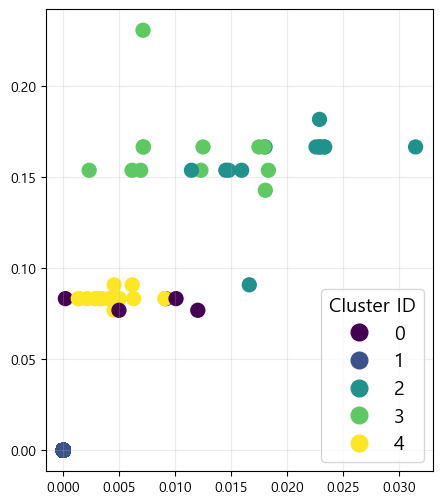

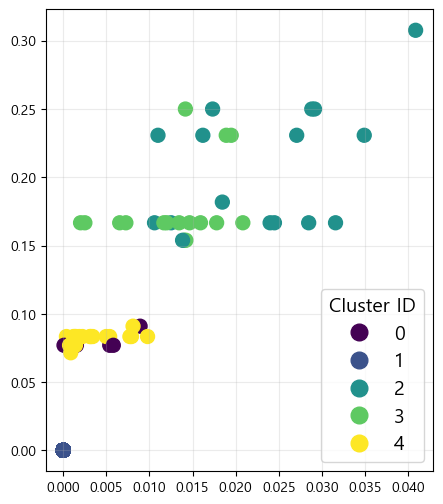

Explained variance ratio: [0.75414778 0.18559823]
Cumulative: 0.9397460168609464


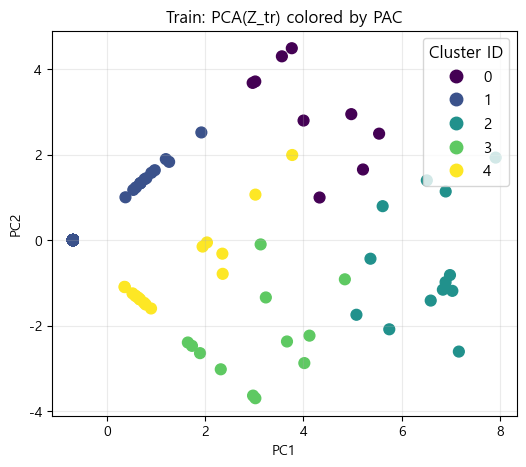

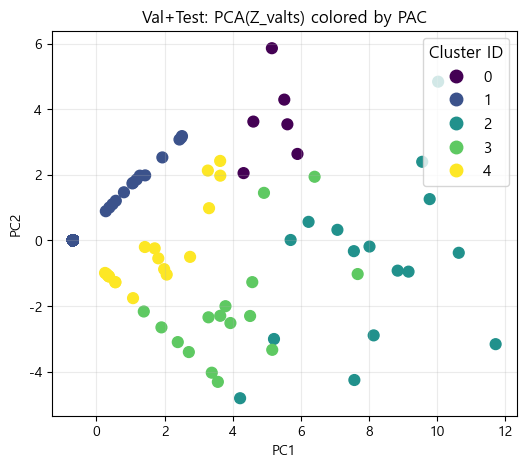

In [15]:
W_tr  = sum_tr_s.dropna(subset=pi_cols).copy()
W_valts = sum_valts_s.dropna(subset=pi_cols).copy()

X_tr  = W_tr[pi_cols].to_numpy()
X_valts = W_valts[pi_cols].to_numpy()

scaler = StandardScaler(); scaler.fit(X_tr)
Z_tr   = pd.DataFrame(scaler.transform(X_tr), columns=pi_cols)
Z_valts  = pd.DataFrame(scaler.transform(X_valts), columns=pi_cols)

Ks = range(2, 6)
bics, aics, gmms = [], [], []
for k in Ks:
    gmm = GaussianMixture(
        n_components=k, covariance_type=covariance_type,
        n_init=50, random_state=random_state)
    gmm.fit(Z_tr)
    bics.append(gmm.bic(Z_tr)); aics.append(gmm.aic(Z_tr))
    gmms.append(gmm)
gmm = gmms[int(np.argmin(bics))]

print('bast K:', Ks[int(np.argmin(bics))])

W_tr["PAC"]       = gmm.predict(Z_tr)
W_tr_proba        = gmm.predict_proba(Z_tr)
# W_tr["PAC_maxp"]  = gmm.predict_proba(Z_tr).max(axis=1)

W_valts["PAC"]      = gmm.predict(Z_valts)
W_valts_proba       = gmm.predict_proba(Z_valts)
# W_valts["PAC_maxp"] = gmm.predict_proba(Z_val).max(axis=1)

merge_cols  = ["tide_win_id", "PAC"]
tr_labeled  = win_tr_s.merge(
    W_tr[merge_cols], on="tide_win_id", how="left", validate="m:1")
valts_labeled = win_valts_s.merge(
    W_valts[merge_cols], on="tide_win_id", how="left", validate="m:1")

display('ts_labeled', tr_labeled, 'valts_labeled', valts_labeled, 
        'W_ts',       W_tr,       'W_valts',       W_valts)

# fig. 1
plt.figure(figsize=(5, 6))
sc = plt.scatter(W_tr[pi_cols[1]], W_tr[pi_cols[0]], c=W_tr["PAC"], s=100)
plt.grid(alpha=.25)
clusters = np.sort(W_tr["PAC"].dropna().unique()).astype(int)
handles, _ = sc.legend_elements()  # 핸들은 자동 생성
labels = [f"{k}" for k in clusters]
plt.legend(handles, labels, title="Cluster ID",
           title_fontsize=14, fontsize=14, markerscale=2)
plt.show()

# fig. 2
plt.figure(figsize=(5, 6))
sc = plt.scatter(W_valts[pi_cols[1]], W_valts[pi_cols[0]], c=W_valts["PAC"], s=100)
plt.grid(alpha=.25)
clusters = np.sort(W_valts["PAC"].dropna().unique()).astype(int)
handles, _ = sc.legend_elements()  # 핸들은 자동 생성
labels = [f"{k}" for k in clusters]
plt.legend(handles, labels, title="Cluster ID", loc='lower right',
           title_fontsize=14, fontsize=14, markerscale=2)
plt.show()

# 1) PCA는 train 표준화 공간(Z_tr)에서만 학습
pca = PCA(n_components=2)
PC_tr    = pca.fit_transform(Z_tr)      # (n_tr, 2)
PC_valts = pca.transform(Z_valts)       # (n_valts, 2)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.sum())

# ---- helper: PAC legend 안정적으로 만들기 ----
def scatter_pca(PC, pac, title, loc="best"):
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(PC[:, 0], PC[:, 1], c=pac, s=60)
    plt.grid(alpha=.25)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)

    clusters = np.sort(np.unique(pac[~pd.isna(pac)])).astype(int)
    handles, _ = sc.legend_elements()
    # legend_elements()는 0..K-1 순서를 보장하진 않아서, clusters 길이에 맞춰 잘라 쓰는 게 안전
    handles = handles[:len(clusters)]
    labels = [f"{k}" for k in clusters]

    plt.legend(handles, labels, title="Cluster ID", loc=loc,
               title_fontsize=12, fontsize=11, markerscale=1.5)
    plt.show()

# 2) PAC로 색칠해서 시각화
scatter_pca(PC_tr,    W_tr["PAC"].to_numpy(),    "Train: PCA(Z_tr) colored by PAC",  loc="best")
scatter_pca(PC_valts, W_valts["PAC"].to_numpy(), "Val+Test: PCA(Z_valts) colored by PAC", loc="best")

In [16]:
def add_future_targets(df, horizon_steps, col='서부산낙동강교_염분도'):
    df2           = df.copy()
    horizon_steps = tuple(sorted(set(horizon_steps)))
    for s in horizon_steps:
        df2[f'Actual_t+{s}'] = df2[col].shift(-s)
    df2 = df2.dropna(
        subset=[f'Actual_t+{s}' for s in horizon_steps]
        ).reset_index(drop=True)
    return df2

In [17]:
tr_labeled    = add_future_targets(tr_labeled, horizon_steps=horizon_steps)
valts_labeled = add_future_targets(valts_labeled, horizon_steps=horizon_steps)
val_labeled = valts_labeled[(valts_labeled['Date'] >= '2022-09-24') & (valts_labeled['Date'] < '2023-01-01')]
ts_labeled  = valts_labeled[(valts_labeled['Date'] >= '2023-01-01')]

sum_val_s = sum_valts_s[(sum_valts_s['t_start'] >= '2022-09-24') & (sum_valts_s['t_start'] < '2023-01-01')]
sum_ts_s  = sum_valts_s[(sum_valts_s['t_start'] >= '2023-01-01')]

display('tr_labeled', tr_labeled, 'val_labeled', val_labeled, 'ts_labeled', ts_labeled,
                                  'sum_val_s',   sum_val_s,   'sum_ts_s',   sum_ts_s)

'tr_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12
0,2022-01-01 20:00:00,8.0,9.6,30.24,7.5,7.89,4.61,0.20,12.66,2.3,0.57,0.8300,7.9,4.400000,0.195714,13.171429,71.248,0.0,-0.2600,0.22,8.055556,4.466667,0.180000,11.033333,4.974019,0.182687,12.483997,0.831,8.425556,4.380000,0.218333,8.56,8.381818,4.300000,0.180000,13.400000,78.2,2.1,0.5,290.0,22.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.304712,1000.133393,1000.131859,1000.118717,1000.114592,1000.481286,1000.150165,1000.119901,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.187778
1,2022-01-01 21:00:00,8.0,9.3,29.46,8.1,7.88,4.61,0.20,12.58,2.3,0.41,0.8300,7.9,4.400000,0.190000,13.100000,72.721,0.0,-0.4200,0.22,8.066667,4.500000,0.180000,11.022222,5.006364,0.182754,12.540709,0.834,8.450000,4.378333,0.216667,8.68,8.363636,4.200000,0.180000,13.400000,78.1,2.6,2.1,320.0,18.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.741808,1000.133393,1000.127271,1000.118428,1000.114110,1000.481967,1000.148839,1000.120401,1,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.186667
2,2022-01-01 22:00:00,8.0,9.4,29.92,7.9,7.89,4.60,0.20,12.59,2.3,0.13,0.8300,7.9,4.400000,0.190000,13.085714,77.288,0.0,-0.7000,0.22,8.077778,4.600000,0.180000,11.033333,5.078255,0.182759,12.409776,0.830,8.421111,4.373333,0.216667,8.42,8.327273,4.200000,0.180000,13.400000,77.8,2.1,1.3,320.0,20.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.085830,1000.133499,1000.127271,1000.117456,1000.112865,1000.480803,1000.148874,1000.120401,1,0.866025,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.184444
3,2022-01-01 23:00:00,8.1,9.4,29.01,8.2,7.89,4.57,0.20,12.58,2.2,-0.24,0.8300,7.9,4.385714,0.190000,13.100000,83.911,0.0,-1.0700,0.22,8.077778,4.600000,0.180000,11.033333,5.075522,0.182760,12.499902,0.828,8.410000,4.366667,0.215000,8.59,8.309091,4.163636,0.180000,13.400000,77.5,2.3,1.4,290.0,21.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.375304,1000.133809,1000.127376,1000.117456,1000.112915,1000.479988,1000.147583,1000.120544,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.180000
4,2022-01-02 00:00:00,8.0,9.4,28.84,8.0,7.90,4.52,0.20,12.73,2.3,-0.56,0.8300,7.9,4.300000,0.190000,13.100000,91.226,0.0,-1.3900,0.22,8.055556,4.600000,0.180000,11.000000,5.073063,0.182759,12.526897,0.826,8.400000,4.366667,0.215000,8.68,8.300000,4.190909,0.180000,13.336364,77.5,2.3,1.6,320.0,21.0,0.00,0.0,0.0,1.000000,0.017213,0.999852,-0.781831,0.623490,1022.242589,1000.134295,1000.127933,1000.117456,1000.112958,1000.479095,1000.147583,1000.120438,1,0.866025,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.182222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,2022-06-27 15:00:00,8.0,24.1,8.19,6.0,7.85,23.89,2.53,2.22,4.5,-0.17,0.8190,8.3,25.000000,0.250000,7.942857,402.300,0.0,-0.9890,0.29,8.233333,23.955556,1.468889,6.100000,23.577500,1.825000,6.220000,4.100,19.893333,25.523333,0.288333,3.42,8.460998,24.838942,0.162092,8.238680,231.3,23.3,7.2,230.0,100.0,0.16,1.3,0.5,-0.866025,0.094537,-0.995521,0.000000,1.000000,1003.438236,999.239465,997.237382,998.422604,998.784990,1001.350855

'val_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12
0,2022-09-25 08:00:00,7.8,23.1,29.80,3.4,8.00,23.06,6.86,7.70,6.5,0.80,0.7870,8.142953,23.659409,0.402570,9.485025,179.628044,0.0,0.0130,0.10,8.024503,23.690038,0.059848,7.729837,23.254,0.104,9.094,0.131111,23.212222,23.500000,0.095000,5.64,6.402270,23.517297,0.091817,9.630107,170.4,19.6,3.000,70.0,63.00,0.32,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1019.971881,1002.703989,997.688834,997.421404,997.560392,997.590993,997.494280,997.487674,345,0.0,1.0,1.000000,0.0130,0.166667,0.016283,0.166667,0.002,3,0.058765,0.057683,0.056277
1,2022-09-25 09:00:00,7.8,23.1,28.69,3.3,8.09,23.08,6.96,7.55,4.5,0.80,0.7890,8.144199,23.656897,0.400259,9.491379,175.962393,0.0,0.0110,0.10,8.018322,23.686005,0.059487,7.732536,23.246,0.102,9.154,0.142222,23.238889,23.480000,0.098333,5.37,6.400765,23.512829,0.091803,9.634706,166.4,21.1,2.200,50.0,61.00,0.74,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1019.132757,1002.774200,997.687696,997.422114,997.560791,997.593044,997.501652,997.488745,345,0.540641,0.841254,1.000000,0.0120,0.166667,0.016283,0.166667,0.002,3,0.058405,0.057322,0.056675
2,2022-09-25 10:00:00,7.9,23.1,12.15,4.2,7.98,23.08,7.09,7.14,8.2,0.59,0.7820,8.145446,23.654384,0.397948,9.497734,172.296743,0.0,-0.1920,0.09,8.012141,23.681973,0.059126,7.735236,23.246,0.104,9.216,0.145556,23.224444,23.500000,0.080000,4.36,6.399261,23.508362,0.091788,9.639304,181.9,20.9,2.300,50.0,65.00,0.67,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1006.669772,1002.871932,997.686558,997.422823,997.562310,997.599036,997.482892,997.489817,345,0.909632,0.415415,0.666667,0.0080,0.166667,0.016283,0.166667,0.002,3,0.058044,0.056962,0.057073
3,2022-09-25 11:00:00,7.9,23.0,24.60,3.7,8.02,23.00,7.98,7.45,6.5,0.34,0.7740,8.146692,23.651872,0.395638,9.504089,168.631093,0.0,-0.4340,0.10,8.005960,23.677941,0.058765,7.737935,23.194,0.102,9.322,0.138889,23.197778,23.480000,0.278333,5.54,6.397756,23.503894,0.091774,9.643902,206.6,21.3,2.500,50.0,63.00,0.70,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1016.071616,1003.560918,997.685419,997.423533,997.573241,997.600357,997.638257,997.490888,345,0.989821,-0.142315,0.500000,0.0060,0.166667,0.016283,0.166667,0.002,3,0.057683,0.056601,0.057471
4,2022-09-25 12:00:00,7.9,23.0,25.07,3.6,8.11,23.03,8.05,6.92,4.3,0.02,0.7725,8.147939,23.649360,0.393327,9.510443,164.965443,0.0,-0.7525,0.10,7.999779,23.673908,0.058405,7.740635,23.194,0.100,9.216,0.142222,23.212222,23.460000,0.283333,5.65,6.396251,23.499426,0.091760,9.648500,226.1,22.4,2.200,70.0,60.00,1.10,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1016.426352,1003.606044,997.684281,997.424242,997.571722,997.599431,997.646894,997.491959,345,0.75575,-0.654861,0.400000,0.0048,0.166667,0.016283,0.166667,0.002,3,0.057322,0.056240,0.057869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2339,2022-12-31 19:00:00,8.4,10.1,27.32,7.7,8.42,4.23,0.28,13.51,2.4,-0.15,0.9186,8.100000,4.171429,0.260000,13.400000,96.960000,0.0,-1.0686,0.16,7.800000,4.833333,0.481111,10.477778,5.710,0.512,10.578,1.285556,10.344

'ts_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12
2344,2023-01-01 00:00:00,8.5,8.9,23.60,9.2,8.42,4.23,0.28,13.51,2.4,-0.30,0.9175,8.014286,4.000000,0.255714,13.257143,104.552,0.0,-1.2175,0.15,7.700000,4.922222,0.540000,9.977778,6.038,0.528,10.108,1.264444,10.192222,4.745000,0.355000,6.55,7.990909,4.009091,0.210000,13.418182,107.6,0.8,1.304,180.0,57.12,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1018.222650,1000.200599,1000.181812,1000.401487,1000.363813,1000.678099,1000.256027,1000.145042,533,-0.989821,-0.142315,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.556667,0.546667,0.526667
2345,2023-01-01 01:00:00,8.4,9.2,26.70,8.7,8.42,4.23,0.28,13.51,2.4,-0.20,0.9226,8.000000,4.000000,0.250000,13.300000,101.484,0.0,-1.1226,0.15,7.700000,4.955556,0.517778,9.922222,6.014,0.522,10.238,1.261111,10.173333,4.735000,0.358333,6.40,7.990909,3.772727,0.210000,13.481818,104.4,0.8,1.300,180.0,57.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1020.601416,1000.200599,1000.177217,1000.383143,1000.359834,1000.677258,1000.258830,1000.144900,533,-0.909632,0.415415,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.572222,0.565556,0.536667
2346,2023-01-01 02:00:00,8.4,9.7,29.50,8.0,8.42,4.23,0.28,13.51,2.4,0.02,0.9209,8.000000,3.957143,0.250000,13.300000,97.953,0.0,-0.9009,0.15,7.700000,5.066667,0.554444,9.777778,5.852,0.500,10.864,1.251111,10.181111,4.741667,0.358333,6.46,7.990909,3.872727,0.210000,13.390909,102.6,1.2,2.600,230.0,54.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1022.711691,1000.200599,1000.177257,1000.410464,1000.347477,1000.668699,1000.258742,1000.145069,533,-0.540641,0.841254,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.528889,0.555556,0.531111
2347,2023-01-01 03:00:00,8.3,10.2,31.74,6.9,8.42,4.23,0.28,13.51,2.4,0.16,0.9190,8.000000,3.900000,0.250000,13.200000,94.397,0.0,-0.7590,0.15,7.666667,5.077778,0.556667,9.544444,5.792,0.496,11.046,1.228889,10.060000,4.735000,0.358333,6.35,7.990909,3.645455,0.210000,13.436364,94.9,1.0,2.100,250.0,53.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1024.378119,1000.200599,1000.177266,1000.412029,1000.346102,1000.662532,1000.258830,1000.144454,533,-0.0,1.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.546667,0.541111,0.498889
2348,2023-01-01 04:00:00,8.3,10.4,32.22,7.2,8.42,4.23,0.28,13.51,2.4,0.18,0.9200,8.000000,3.800000,0.250000,13.200000,92.192,0.0,-0.7400,0.16,7.688889,5.166667,0.572222,9.655556,5.848,0.490,10.942,1.251111,10.138889,4.730000,0.360000,6.44,7.976020,3.944996,0.210000,12.145177,92.7,1.0,1.800,110.0,53.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1024.718729,1000.200599,1000.177155,1000.422700,1000.339627,1000.672640,1000.260231,1000.145091,534,0.0,1.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.565556,0.507778,0.522222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5647,2023-05-18 15:00:00,7.9,18.5,18.66,6.8,7.88,18.36,14.09,4.90,6.3,-0.36,0.7733,7.200000,19.700000,0.150000,9.200000,139.757,0.0,-1.1333,0.11,7.300000,19.367996,0.151111,7.964942,18.962,0.164,8.442,0.136667,18.544444,15.856667,0.180000,3.06,7.281818,17.518182,0.151818,8.472

'sum_val_s'

,tide_win_id,t_start,t_end,n,p_w,I_w,p_prev,I_prev
0,345,2022-09-25 08:00:00,2022-09-25 19:00:00,12,0.166667,0.002000,0.166667,0.016283
1,346,2022-09-25 20:00:00,2022-09-26 08:00:00,13,0.153846,0.014038,0.166667,0.002000
2,347,2022-09-26 09:00:00,2022-09-26 20:00:00,12,0.000000,0.000000,0.153846,0.014038
3,348,2022-09-26 21:00:00,2022-09-27 08:00:00,12,0.250000,0.014167,0.000000,0.000000
4,349,2022-09-27 09:00:00,2022-09-27 20:00:00,12,0.166667,0.024000,0.250000,0.014167
...,...,...,...,...,...,...,...,...
184,529,2022-12-29 13:00:00,2022-12-30 01:00:00,13,0.000000,0.000000,0.000000,0.000000
185,530,2022-12-30 02:00:00,2022-12-30 13:00:00,12,0.000000,0.000000,0.000000,0.000000
186,531,2022-12-30 14:00:00,2022-12-31 03:00:00,14,0.000000,0.000000,0.000000,0.000000
187,532,2022-12-31 04:00:00,2022-12-31 15:00:00,12,0.000000,0.000000,0.000000,0.000000


'sum_ts_s'

,tide_win_id,t_start,t_end,n,p_w,I_w,p_prev,I_prev
189,534,2023-01-01 04:00:00,2023-01-01 15:00:00,12,0.000000,0.000000,0.000000,0.000000
190,535,2023-01-01 16:00:00,2023-01-02 05:00:00,14,0.000000,0.000000,0.000000,0.000000
191,536,2023-01-02 06:00:00,2023-01-02 17:00:00,12,0.000000,0.000000,0.000000,0.000000
192,537,2023-01-02 18:00:00,2023-01-03 06:00:00,13,0.000000,0.000000,0.000000,0.000000
193,538,2023-01-03 07:00:00,2023-01-03 17:00:00,11,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
451,796,2023-05-16 18:00:00,2023-05-17 06:00:00,13,0.000000,0.000000,0.000000,0.000000
452,797,2023-05-17 07:00:00,2023-05-17 18:00:00,12,0.000000,0.000000,0.000000,0.000000
453,798,2023-05-17 19:00:00,2023-05-18 07:00:00,13,0.000000,0.000000,0.000000,0.000000
454,799,2023-05-18 08:00:00,2023-05-18 19:00:00,12,0.083333,0.001183,0.000000,0.000000


In [18]:
def build_long_df_two_points(
    df: pd.DataFrame,
    win_col: str = "tide_win_id",
    PAcluster_col: str = "PAC",
    s1_col: str = "상류7h_염분도",
    sal_cols = ("강서낙동강교_염분도", "구포대교_염분도"),
    x_map = {"강서낙동강교_염분도": 10000.0, "구포대교_염분도": 11500.0},
    agg: str = "median",
    min_valid: int = 3):

    def agg_series(s):
        s = s.astype(float)
        if agg == "median":
            return float(np.nanmedian(s))
        elif agg == "mean":
            return float(np.nanmean(s))
        else:
            raise ValueError("agg must be 'median' or 'mean'")

    rows = []
    for wid, dfi in df.groupby(win_col, sort=True):
        pac = dfi[PAcluster_col].iloc[0]

        # S1(w)
        s1 = dfi[s1_col].astype(float)
        if s1.notna().sum() < min_valid:
            continue
        S1 = agg_series(s1)

        # Sf = 0 (가정)
        Sf = 0.0

        # reach2 points
        pts = []
        for c in sal_cols:
            s = dfi[c].astype(float)
            if s.notna().sum() < min_valid:
                continue
            pts.append((float(x_map[c]), agg_series(s), c))

        # 최소 2점 필요(두 지점 모두 유효해야 안정적)
        if len(pts) < 2:
            continue

        for x, Sobs, st in pts:
            rows.append({
                win_col: wid,
                PAcluster_col: pac,
                "x": x, # 거리
                "S_obs": Sobs, # 염분
                "S1": S1,
                "Sf": Sf,
                "station": st})

    return pd.DataFrame(rows)


def beta_upper_bound(x_max, x1, a2, eps=1e-6): # beta 상한
    # 1 - beta*(exp((x-x1)/a2)-1) >= eps 보장
    u = (x_max - x1) / a2
    u = np.clip(u, None, 80.0)  # exp overflow 방지
    zmax = np.exp(u) - 1.0
    return (1.0 - eps) / max(zmax, 1e-12)


def predict_sal_reach2(x, S1, Sf, K, beta1, x1, a2): # 염분 예측
    u = (x - x1) / a2
    u = np.clip(u, None, 80.0)          # exp overflow 방지
    z = np.exp(u) - 1.0
    inside = 1.0 - beta1 * z
    inside = np.clip(inside, 1e-8, None)
    return Sf + (S1 - Sf) * (inside ** (1.0 / K))


def window_loss_K(K, d, beta1, x1, a2): # 윈도우별 MSE
    x = d["x"].to_numpy(float)
    Sobs = d["S_obs"].to_numpy(float)
    S1 = float(d["S1"].iloc[0])
    Sf = float(d["Sf"].iloc[0])
    Shat = predict_sal_reach2(x, S1, Sf, K, beta1, x1, a2)
    r = Shat - Sobs
    return float(np.mean(r*r))


# def window_loss_K_station_balanced(K, d, beta1, x1, a2):
#     x = d["x"].to_numpy(float)
#     Sobs = d["S_obs"].to_numpy(float)
#     S1 = float(d["S1"].iloc[0])
#     Sf = float(d["Sf"].iloc[0])
#     Shat = predict_sal_reach2(x, S1, Sf, K, beta1, x1, a2)
#     r = Shat - Sobs

#     st = d["station"].to_numpy()
#     uniq = np.unique(st)

#     # 지점별 MSE 평균 (각 지점 동일 가중)
#     mses = []
#     for s in uniq:
#         rs = r[st == s]
#         mses.append(np.mean(rs * rs))
#     return float(np.mean(mses))


def fit_K_one_window(d, beta1, x1, a2, K_bounds): # beta 고정 후 K 최적화
    res = minimize_scalar(lambda K: window_loss_K(K, d, beta1, x1, a2),
                          bounds=K_bounds, method="bounded")
    return float(res.x), float(res.fun)


def estimate_B1(
    long_df: pd.DataFrame, 
    win_col: str, 
    PAcluster_col: str, 
    x1=7500, 
    a2=(11500-10000)/math.log(3863/3463), #4800, 
    K_bounds=(1e-3, 1), #(1e-3, 1), 
    n_iter=50, 
    min_windows_per_pac=5):

    win_groups = {wid: d for wid, d in long_df.groupby(win_col, sort=True)}
    win_reg = long_df.groupby(win_col)[PAcluster_col].first().to_dict()

    # regime별 윈도우 수
    reg_counts = pd.Series(win_reg).value_counts()
    regimes = sorted(long_df[PAcluster_col].unique())
    active = [r for r in regimes if reg_counts.get(r, 0) >= min_windows_per_pac]

    # regime별 beta 상한(가장 먼 x 기준)
    reg_xmax = long_df.groupby(PAcluster_col)["x"].max().to_dict()
    beta_hi = {r: beta_upper_bound(reg_xmax[r], x1, a2) for r in regimes}

    # 초기 beta: 상한의 30% (보수적)
    beta = {r: 0.3 * beta_hi[r] for r in active}

    K_hat_w = {wid: 1.0 for wid in win_groups}
    loss_hat = {wid: np.nan for wid in win_groups}

    for _ in range(n_iter):
        # (A) beta 고정 -> window별 K
        for wid, d in win_groups.items():
            r = win_reg[wid]
            if r not in active:
                continue
            K_hat_w[wid], loss_hat[wid] = fit_K_one_window(d, beta[r], x1, a2, K_bounds)

        # (B) K 고정 -> regime별 beta
        for r in active:
            wids = [wid for wid in win_groups if win_reg[wid] == r]
            if len(wids) < min_windows_per_pac:
                continue

            def reg_loss(b):
                tot = 0.0
                for wid in wids:
                    tot += window_loss_K(K_hat_w[wid], win_groups[wid], b, x1, a2)
                return tot / len(wids)

            lo, hi = 0.0, beta_hi[r] * 0.999
            if hi <= lo:
                continue
            res = minimize_scalar(reg_loss, bounds=(lo, hi), method="bounded")
            beta[r] = float(res.x)

    # 결과 테이블
    win_res = []
    for wid in win_groups:
        r = win_reg[wid]
        b = beta.get(r, np.nan)
        Kw = K_hat_w.get(wid, np.nan)
        Lw = x1 + a2 * np.log(1.0/b + 1.0) if np.isfinite(b) and b > 0 else np.nan
        win_res.append({
            win_col: wid, PAcluster_col: r, 
            "K_hat_w": Kw, "beta_hat_c": b, 
            "L_hat": Lw, "loss": loss_hat[wid]})
    win_res = pd.DataFrame(win_res)

    pac_res = pd.DataFrame({
        PAcluster_col: list(beta.keys()),
        "beta_hat": [beta[r] for r in beta.keys()],
        "beta_hi": [beta_hi[r] for r in beta.keys()],
        "n_windows": [int(reg_counts.get(r, 0)) for r in beta.keys()]})

    return win_res, pac_res


# def estimate_B1_expanding_ts_ordered(
#     long_df: pd.DataFrame,
#     win_col: str,
#     PAcluster_col: str,
#     wids_sorted: list,                 # 시간순 window id
#     t_end_map: dict | None = None,     # wid -> t_end (옵션)
#     x1: float = 7500.0,
#     a2: float = (11500-10000)/math.log(3863/3463), #4800.0,
#     K_bounds=(1e-3, 1), #(1e-3, 1),
#     min_windows_per_pac: int = 1,
#     update_every: int = 2,
#     local_iter: int = 20,
#     max_history: int = 200,
#     init_beta_map: dict | None = None, # PAC -> beta 초기값(tr에서 학습한 beta 추천)
#     verbose: bool = False):
    
#     df = long_df.copy()

#     # window별 데이터
#     win_groups = {wid: d for wid, d in df.groupby(win_col, sort=False)}
#     win_pac    = df.groupby(win_col, sort=False)[PAcluster_col].first().to_dict()

#     # 입력으로 받은 wids_sorted에서 long_df에 없는 wid 제거
#     wids_sorted = [wid for wid in wids_sorted if wid in win_groups]

#     PAclusters = sorted(df[PAcluster_col].unique())

#     # PAC별 beta 상한
#     pac_xmax = df.groupby(PAcluster_col)["x"].max().to_dict()
#     beta_hi = {r: beta_upper_bound(pac_xmax[r], x1, a2) for r in PAclusters}

#     # 초기 beta
#     beta = {}
#     for r in PAclusters:
#         if init_beta_map is not None and r in init_beta_map and np.isfinite(init_beta_map[r]):
#             beta[r] = float(init_beta_map[r])
#         else:
#             beta[r] = float(0.3 * beta_hi[r])

#     hist = {r: [] for r in PAclusters}
#     K_hat_w, loss_hat, beta_used_w = {}, {}, {}

#     def reg_loss_with_fixed_K(wids_r, b):
#         tot = 0.0
#         for wid in wids_r:
#             tot += window_loss_K(K_hat_w[wid], win_groups[wid], b, x1, a2)
#         return tot / max(len(wids_r), 1)

#     records = []

#     for step, wid in tqdm(enumerate(wids_sorted, start=1)):
#         r = win_pac[wid]
#         hist[r].append(wid)

#         # 1) 현재 beta로 K 추정
#         K0, L0 = fit_K_one_window(win_groups[wid], beta[r], x1, a2, K_bounds)
#         K_hat_w[wid], loss_hat[wid] = K0, L0

#         # 2) 해당 PAC에서 충분히 쌓였고 update 타이밍이면 beta 업데이트
#         n_r = len(hist[r])
#         do_update = (n_r >= min_windows_per_pac) and (update_every is not None) and (n_r % update_every == 0)

#         if do_update:
#             wids_r = hist[r][-max_history:] if (max_history is not None and max_history > 0) else list(hist[r])

#             for _ in range(max(local_iter, 1)):
#                 # (A) beta 고정 -> K 갱신
#                 for wid2 in wids_r:
#                     K_hat_w[wid2], loss_hat[wid2] = fit_K_one_window(
#                         win_groups[wid2], beta[r], x1, a2, K_bounds
#                     )

#                 # (B) K 고정 -> beta 갱신
#                 lo, hi = 0.0, beta_hi[r] * 0.999
#                 if hi > lo:
#                     res = minimize_scalar(
#                         lambda b: reg_loss_with_fixed_K(wids_r, b),
#                         bounds=(lo, hi), method="bounded"
#                     )
#                     beta[r] = float(res.x)

#             # 업데이트된 beta로 현재 윈도우 K 재추정
#             K1, L1 = fit_K_one_window(win_groups[wid], beta[r], x1, a2, K_bounds)
#             K_hat_w[wid], loss_hat[wid] = K1, L1

#             if verbose:
#                 print(f"[{step}/{len(wids_sorted)}] PAC={r} update: n={n_r}, beta={beta[r]:.6g}")

#         beta_used_w[wid] = float(beta[r])

#         b = beta_used_w[wid]
#         Lw = x1 + a2 * np.log(1.0/b + 1.0) if np.isfinite(b) and b > 0 else np.nan

#         rec = {
#             win_col: wid,
#             PAcluster_col: r,
#             "K_hat_w": float(K_hat_w[wid]),
#             "beta_hat_c": float(b),
#             "L_hat": float(Lw),
#             "loss": float(loss_hat[wid]),
#             "n_seen_in_regime": int(n_r), # PAC에서 누적된 window 수
#             "updated_this_step": bool(do_update),
#         }
#         if t_end_map is not None:
#             rec["t_end"] = pd.to_datetime(t_end_map.get(wid, pd.NaT))
#         records.append(rec)

#     sum_ts_sp = pd.DataFrame(records)
#     if "t_end" in sum_ts_sp.columns:
#         sum_ts_sp = sum_ts_sp.sort_values("t_end").reset_index(drop=True)

#     pac_res_ts = pd.DataFrame({
#         PAcluster_col: PAclusters,
#         "beta_hat": [float(beta[r]) for r in PAclusters],
#         "beta_hi": [float(beta_hi[r]) for r in PAclusters],
#         "n_windows": [int(len(hist[r])) for r in PAclusters],
#     }).sort_values(PAcluster_col).reset_index(drop=True)

#     return sum_ts_sp, pac_res_ts

In [19]:
long_df_tr  = build_long_df_two_points(tr_labeled)
long_df_val = build_long_df_two_points(val_labeled)
long_df_ts  = build_long_df_two_points(ts_labeled)

sum_tr_sp, pac_res_tr = estimate_B1(
    long_df_tr, win_col="tide_win_id", PAcluster_col="PAC",
    min_windows_per_pac=5)
sum_val_sp, pac_res_val = estimate_B1(
    long_df_val, win_col="tide_win_id", PAcluster_col="PAC",
    min_windows_per_pac=1)
# 사후분석용
sum_ts_sp, pac_res_ts = estimate_B1(
    long_df_ts, win_col="tide_win_id", PAcluster_col="PAC",
    min_windows_per_pac=1)
# 실시간용
# sum_ts_sp, pac_res_ts = estimate_B1_expanding_ts_ordered(
#     long_df_ts, win_col="tide_win_id", PAcluster_col="PAC",
#     min_windows_per_pac=1, 
#     wids_sorted=long_df_ts['tide_win_id'].unique().tolist(),
#     init_beta_map=pac_res_tr.set_index("PAC")["beta_hat"].to_dict())

sum_tr_sp = sum_tr_s.merge(
    sum_tr_sp, how="left", on="tide_win_id", validate="one_to_one")
sum_val_sp = sum_val_s.merge(
    sum_val_sp, how="left", on="tide_win_id", validate="one_to_one")
sum_ts_sp = sum_ts_s.merge(
    sum_ts_sp, how="left", on="tide_win_id", validate="one_to_one")

display('sum_tr_sp',  sum_tr_sp,  'sum_val_sp',  sum_val_sp,  'sum_ts_sp',  sum_ts_sp,
        'pac_res_tr', pac_res_tr, 'pac_res_val', pac_res_val, 'pac_res_ts', pac_res_ts)

'sum_tr_sp'

,tide_win_id,t_start,t_end,n,p_w,I_w,p_prev,I_prev,PAC,K_hat_w,beta_hat_c,L_hat,loss
0,1,2022-01-01 20:00:00,2022-01-02 08:00:00,13,0.000000,0.000000,0.000000,0.000000,1.0,0.154468,0.797593,18651.046755,0.003925
1,2,2022-01-02 09:00:00,2022-01-02 19:00:00,11,0.000000,0.000000,0.000000,0.000000,1.0,0.159192,0.797593,18651.046755,0.003480
2,3,2022-01-02 20:00:00,2022-01-03 08:00:00,13,0.000000,0.000000,0.000000,0.000000,1.0,0.160022,0.797593,18651.046755,0.003443
3,4,2022-01-03 09:00:00,2022-01-03 20:00:00,12,0.083333,0.004167,0.000000,0.000000,4.0,0.162798,0.797618,18650.812277,0.003266
4,5,2022-01-03 21:00:00,2022-01-04 09:00:00,13,0.000000,0.000000,0.083333,0.004167,1.0,0.163939,0.797593,18651.046755,0.003217
...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,339,2022-06-25 19:00:00,2022-06-26 06:00:00,12,0.000000,0.000000,0.000000,0.000000,1.0,0.081221,0.797593,18651.046755,0.003773
339,340,2022-06-26 07:00:00,2022-06-26 18:00:00,12,0.000000,0.000000,0.000000,0.000000,1.0,0.077655,0.797593,18651.046755,0.004898
340,341,2022-06-26 19:00:00,2022-06-27 07:00:00,13,0.000000,0.000000,0.000000,0.000000,1.0,0.075547,0.797593,18651.046755,0.005482
341,342,2022-06-27 08:00:00,2022-06-27 19:00:00,12,0.000000,0.000000,0.000000,0.000000,1.0,0.067610,0.797593,18651.046755,0.008026


'sum_val_sp'

,tide_win_id,t_start,t_end,n,p_w,I_w,p_prev,I_prev,PAC,K_hat_w,beta_hat_c,L_hat,loss
0,345,2022-09-25 08:00:00,2022-09-25 19:00:00,12,0.166667,0.002000,0.166667,0.016283,3,0.484594,0.645482,20341.481440,0.000070
1,346,2022-09-25 20:00:00,2022-09-26 08:00:00,13,0.153846,0.014038,0.166667,0.002000,3,0.409121,0.645482,20341.481440,0.000077
2,347,2022-09-26 09:00:00,2022-09-26 20:00:00,12,0.000000,0.000000,0.153846,0.014038,1,0.606435,0.718297,19468.923191,0.000032
3,348,2022-09-26 21:00:00,2022-09-27 08:00:00,12,0.250000,0.014167,0.000000,0.000000,3,0.408541,0.645482,20341.481440,0.000257
4,349,2022-09-27 09:00:00,2022-09-27 20:00:00,12,0.166667,0.024000,0.250000,0.014167,2,0.357741,0.641919,20387.692301,0.000280
...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,529,2022-12-29 13:00:00,2022-12-30 01:00:00,13,0.000000,0.000000,0.000000,0.000000,1,0.113643,0.718297,19468.923191,0.005419
185,530,2022-12-30 02:00:00,2022-12-30 13:00:00,12,0.000000,0.000000,0.000000,0.000000,1,0.126962,0.718297,19468.923191,0.002449
186,531,2022-12-30 14:00:00,2022-12-31 03:00:00,14,0.000000,0.000000,0.000000,0.000000,1,0.130065,0.718297,19468.923191,0.002836
187,532,2022-12-31 04:00:00,2022-12-31 15:00:00,12,0.000000,0.000000,0.000000,0.000000,1,0.129416,0.718297,19468.923191,0.002838


'sum_ts_sp'

...

,PAC,beta_hat,beta_hi,n_windows
0,0,0.838243,2.954901,9
1,1,0.797593,2.954901,291
2,2,0.954788,2.954901,13
3,3,0.842616,2.954901,12
4,4,0.797618,2.954901,17


'pac_res_val'

,PAC,beta_hat,beta_hi,n_windows
0,0,0.715666,2.954901,5
1,1,0.718297,2.954901,156
2,2,0.641919,2.954901,15
3,3,0.645482,2.954901,9
4,4,0.697400,2.954901,4


'pac_res_ts'

,PAC,beta_hat,beta_hi,n_windows
0,0,0.667359,2.954901,1
1,1,0.673493,2.954901,245
2,2,0.667519,2.954901,1
3,3,0.674439,2.954901,6
4,4,0.660989,2.954901,14


In [20]:
cols_to_add = ["tide_win_id", "K_hat_w", "beta_hat_c"]
tr_labeled = tr_labeled.merge(
    sum_tr_sp[cols_to_add], on='tide_win_id', 
    how='left', validate='m:1')
val_labeled = val_labeled.merge(
    sum_val_sp[cols_to_add], on='tide_win_id', 
    how='left', validate='m:1')
ts_labeled = ts_labeled.merge(
    sum_ts_sp[cols_to_add], on='tide_win_id', 
    how='left', validate='m:1')

display('tr_labeled', tr_labeled, 
        'val_labeled', val_labeled, 
        'ts_labeled', ts_labeled)

'tr_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c
0,2022-01-01 20:00:00,8.0,9.6,30.24,7.5,7.89,4.61,0.20,12.66,2.3,0.57,0.8300,7.9,4.400000,0.195714,13.171429,71.248,0.0,-0.2600,0.22,8.055556,4.466667,0.180000,11.033333,4.974019,0.182687,12.483997,0.831,8.425556,4.380000,0.218333,8.56,8.381818,4.300000,0.180000,13.400000,78.2,2.1,0.5,290.0,22.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.304712,1000.133393,1000.131859,1000.118717,1000.114592,1000.481286,1000.150165,1000.119901,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.187778,0.154468,0.797593
1,2022-01-01 21:00:00,8.0,9.3,29.46,8.1,7.88,4.61,0.20,12.58,2.3,0.41,0.8300,7.9,4.400000,0.190000,13.100000,72.721,0.0,-0.4200,0.22,8.066667,4.500000,0.180000,11.022222,5.006364,0.182754,12.540709,0.834,8.450000,4.378333,0.216667,8.68,8.363636,4.200000,0.180000,13.400000,78.1,2.6,2.1,320.0,18.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.741808,1000.133393,1000.127271,1000.118428,1000.114110,1000.481967,1000.148839,1000.120401,1,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.186667,0.154468,0.797593
2,2022-01-01 22:00:00,8.0,9.4,29.92,7.9,7.89,4.60,0.20,12.59,2.3,0.13,0.8300,7.9,4.400000,0.190000,13.085714,77.288,0.0,-0.7000,0.22,8.077778,4.600000,0.180000,11.033333,5.078255,0.182759,12.409776,0.830,8.421111,4.373333,0.216667,8.42,8.327273,4.200000,0.180000,13.400000,77.8,2.1,1.3,320.0,20.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.085830,1000.133499,1000.127271,1000.117456,1000.112865,1000.480803,1000.148874,1000.120401,1,0.866025,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.184444,0.154468,0.797593
3,2022-01-01 23:00:00,8.1,9.4,29.01,8.2,7.89,4.57,0.20,12.58,2.2,-0.24,0.8300,7.9,4.385714,0.190000,13.100000,83.911,0.0,-1.0700,0.22,8.077778,4.600000,0.180000,11.033333,5.075522,0.182760,12.499902,0.828,8.410000,4.366667,0.215000,8.59,8.309091,4.163636,0.180000,13.400000,77.5,2.3,1.4,290.0,21.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.375304,1000.133809,1000.127376,1000.117456,1000.112915,1000.479988,1000.147583,1000.120544,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.180000,0.154468,0.797593
4,2022-01-02 00:00:00,8.0,9.4,28.84,8.0,7.90,4.52,0.20,12.73,2.3,-0.56,0.8300,7.9,4.300000,0.190000,13.100000,91.226,0.0,-1.3900,0.22,8.055556,4.600000,0.180000,11.000000,5.073063,0.182759,12.526897,0.826,8.400000,4.366667,0.215000,8.68,8.300000,4.190909,0.180000,13.336364,77.5,2.3,1.6,320.0,21.0,0.00,0.0,0.0,1.000000,0.017213,0.999852,-0.781831,0.623490,1022.242589,1000.134295,1000.127933,1000.117456,1000.112958,1000.479095,1000.147583,1000.120438,1,0.866025,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.182222,0.154468,0.797593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,2022-06-27 15:00:00,8.0,24.1,8.19,6.0,7.85,23.89,2.53,2.22,4.5,-0.17,0.8190,8.3,25.000000,0.250000,7.942857,402.300,0.0,-0.9890,0.29,8.233333,23.955556,1.468889,6.100000,23.577500,1.825000,6.220000,4.100,19.893333,25.523333,0.288333,3.42,8.460998,24.838942,0.162092,8.238680,231.3,23.3,7.2,230.0,100.0,0.16,1.3,0

'val_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c
0,2022-09-25 08:00:00,7.8,23.1,29.80,3.4,8.00,23.06,6.86,7.70,6.5,0.80,0.7870,8.142953,23.659409,0.402570,9.485025,179.628044,0.0,0.0130,0.10,8.024503,23.690038,0.059848,7.729837,23.254,0.104,9.094,0.131111,23.212222,23.500000,0.095000,5.64,6.402270,23.517297,0.091817,9.630107,170.4,19.6,3.000,70.0,63.00,0.32,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1019.971881,1002.703989,997.688834,997.421404,997.560392,997.590993,997.494280,997.487674,345,0.0,1.0,1.000000,0.0130,0.166667,0.016283,0.166667,0.002,3,0.058765,0.057683,0.056277,0.484594,0.645482
1,2022-09-25 09:00:00,7.8,23.1,28.69,3.3,8.09,23.08,6.96,7.55,4.5,0.80,0.7890,8.144199,23.656897,0.400259,9.491379,175.962393,0.0,0.0110,0.10,8.018322,23.686005,0.059487,7.732536,23.246,0.102,9.154,0.142222,23.238889,23.480000,0.098333,5.37,6.400765,23.512829,0.091803,9.634706,166.4,21.1,2.200,50.0,61.00,0.74,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1019.132757,1002.774200,997.687696,997.422114,997.560791,997.593044,997.501652,997.488745,345,0.540641,0.841254,1.000000,0.0120,0.166667,0.016283,0.166667,0.002,3,0.058405,0.057322,0.056675,0.484594,0.645482
2,2022-09-25 10:00:00,7.9,23.1,12.15,4.2,7.98,23.08,7.09,7.14,8.2,0.59,0.7820,8.145446,23.654384,0.397948,9.497734,172.296743,0.0,-0.1920,0.09,8.012141,23.681973,0.059126,7.735236,23.246,0.104,9.216,0.145556,23.224444,23.500000,0.080000,4.36,6.399261,23.508362,0.091788,9.639304,181.9,20.9,2.300,50.0,65.00,0.67,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1006.669772,1002.871932,997.686558,997.422823,997.562310,997.599036,997.482892,997.489817,345,0.909632,0.415415,0.666667,0.0080,0.166667,0.016283,0.166667,0.002,3,0.058044,0.056962,0.057073,0.484594,0.645482
3,2022-09-25 11:00:00,7.9,23.0,24.60,3.7,8.02,23.00,7.98,7.45,6.5,0.34,0.7740,8.146692,23.651872,0.395638,9.504089,168.631093,0.0,-0.4340,0.10,8.005960,23.677941,0.058765,7.737935,23.194,0.102,9.322,0.138889,23.197778,23.480000,0.278333,5.54,6.397756,23.503894,0.091774,9.643902,206.6,21.3,2.500,50.0,63.00,0.70,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1016.071616,1003.560918,997.685419,997.423533,997.573241,997.600357,997.638257,997.490888,345,0.989821,-0.142315,0.500000,0.0060,0.166667,0.016283,0.166667,0.002,3,0.057683,0.056601,0.057471,0.484594,0.645482
4,2022-09-25 12:00:00,7.9,23.0,25.07,3.6,8.11,23.03,8.05,6.92,4.3,0.02,0.7725,8.147939,23.649360,0.393327,9.510443,164.965443,0.0,-0.7525,0.10,7.999779,23.673908,0.058405,7.740635,23.194,0.100,9.216,0.142222,23.212222,23.460000,0.283333,5.65,6.396251,23.499426,0.091760,9.648500,226.1,22.4,2.200,70.0,60.00,1.10,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1016.426352,1003.606044,997.684281,997.424242,997.571722,997.599431,997.646894,997.491959,345,0.75575,-0.654861,0.400000,0.0048,0.166667,0.016283,0.166667,0.002,3,0.057322,0.056240,0.057869,0.484594,0.645482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2339,2022-12-31 19:00:00,8.4,10.1,27.32,7.7,8.42,4.23,0.28,13.51,2.4,-0.15,0.9186,8.100000,4.171429,

'ts_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c
0,2023-01-01 00:00:00,8.5,8.9,23.60,9.2,8.42,4.23,0.28,13.51,2.4,-0.30,0.9175,8.014286,4.000000,0.255714,13.257143,104.552,0.0,-1.2175,0.15,7.700000,4.922222,0.540000,9.977778,6.038,0.528,10.108,1.264444,10.192222,4.745000,0.355000,6.55,7.990909,4.009091,0.210000,13.418182,107.6,0.8,1.304,180.0,57.12,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1018.222650,1000.200599,1000.181812,1000.401487,1000.363813,1000.678099,1000.256027,1000.145042,533,-0.989821,-0.142315,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.556667,0.546667,0.526667,NaN,NaN
1,2023-01-01 01:00:00,8.4,9.2,26.70,8.7,8.42,4.23,0.28,13.51,2.4,-0.20,0.9226,8.000000,4.000000,0.250000,13.300000,101.484,0.0,-1.1226,0.15,7.700000,4.955556,0.517778,9.922222,6.014,0.522,10.238,1.261111,10.173333,4.735000,0.358333,6.40,7.990909,3.772727,0.210000,13.481818,104.4,0.8,1.300,180.0,57.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1020.601416,1000.200599,1000.177217,1000.383143,1000.359834,1000.677258,1000.258830,1000.144900,533,-0.909632,0.415415,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.572222,0.565556,0.536667,NaN,NaN
2,2023-01-01 02:00:00,8.4,9.7,29.50,8.0,8.42,4.23,0.28,13.51,2.4,0.02,0.9209,8.000000,3.957143,0.250000,13.300000,97.953,0.0,-0.9009,0.15,7.700000,5.066667,0.554444,9.777778,5.852,0.500,10.864,1.251111,10.181111,4.741667,0.358333,6.46,7.990909,3.872727,0.210000,13.390909,102.6,1.2,2.600,230.0,54.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1022.711691,1000.200599,1000.177257,1000.410464,1000.347477,1000.668699,1000.258742,1000.145069,533,-0.540641,0.841254,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.528889,0.555556,0.531111,NaN,NaN
3,2023-01-01 03:00:00,8.3,10.2,31.74,6.9,8.42,4.23,0.28,13.51,2.4,0.16,0.9190,8.000000,3.900000,0.250000,13.200000,94.397,0.0,-0.7590,0.15,7.666667,5.077778,0.556667,9.544444,5.792,0.496,11.046,1.228889,10.060000,4.735000,0.358333,6.35,7.990909,3.645455,0.210000,13.436364,94.9,1.0,2.100,250.0,53.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1024.378119,1000.200599,1000.177266,1000.412029,1000.346102,1000.662532,1000.258830,1000.144454,533,-0.0,1.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.546667,0.541111,0.498889,NaN,NaN
4,2023-01-01 04:00:00,8.3,10.4,32.22,7.2,8.42,4.23,0.28,13.51,2.4,0.18,0.9200,8.000000,3.800000,0.250000,13.200000,92.192,0.0,-0.7400,0.16,7.688889,5.166667,0.572222,9.655556,5.848,0.490,10.942,1.251111,10.138889,4.730000,0.360000,6.44,7.976020,3.944996,0.210000,12.145177,92.7,1.0,1.800,110.0,53.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1024.718729,1000.200599,1000.177155,1000.422700,1000.339627,1000.672640,1000.260231,1000.145091,534,0.0,1.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.565556,0.507778,0.522222,0.127850,0.673493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3303,2023-05-18 15:00:00,7.9,18.5,18.66,6.8,7.88,18.36,14.09,4.90,6.3,-0.36,0.7733,7.200000,19.700000,0.150000,9.200000,139.757,0.0,-1.1333,0.11,7.300000,19.367996,0.151111,7.964942,18.962,0.164,8.442,0.136667,18.54

In [21]:
def beta0_upper_bound(x_max: float, a1: float, eps: float = 1e-8) -> float:
    # inside = 1 - beta0*(exp(x/a1)-1) >= eps 보장
    u = np.clip(x_max / a1, None, 80.0)
    zmax = np.exp(u) - 1.0
    return (1.0 - eps) / max(zmax, 1e-12)


def estimate_beta0_by_window_closed_form(
    df: pd.DataFrame,
    win_col: str = "tide_win_id",
    K_col: str = "K_hat_w",                        # 이미 확보한 K (윈도우별)
    s0_col: str = "을숙도선착장_염분도",           # S0 (boundary)
    sal_cols = ("서부산낙동강교_염분도",),
    x_map = {"서부산낙동강교_염분도": 5000.0},
    a1: float = a1,
    x1: float | None = 7500.0,                     # reach-1 구간 상한 (없으면 None)
    enforce_reach1: bool = True,                   # x<=x1만 사용
    Sf: float = 0.0,
    agg: str = "median",
    min_valid: int = 3,
    eps: float = 1e-6,
    combine: str = "lsq",                          # "lsq" or "median" or "mean"
    min_pts: int = 1,                              # 1이면 한 지점도 허용
):
    """
    reach-1 식 + 고정 K로 윈도우별 beta0를 닫힌형으로 추정.
    beta0_i = (1 - y^K) / z,  y=(S-Sf)/(S0-Sf), z=exp(x/a1)-1
    여러 지점이면 combine으로 결합.
    반환: (tide_win_id, beta0_hat_w, n_pts, y_raw_outside_ratio, y_raw_min/med/max ...)
    """

    def agg_series(s: pd.Series) -> float:
        s = s.astype(float)
        if agg == "median":
            return float(np.nanmedian(s))
        elif agg == "mean":
            return float(np.nanmean(s))
        else:
            raise ValueError("agg must be 'median' or 'mean'")

    need = [win_col, K_col, s0_col] + list(sal_cols)
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise KeyError(f"Missing columns: {miss}")

    # reach-1에서 최대 x (상한 계산용)
    xs = [float(x_map[c]) for c in sal_cols if c in x_map]
    if enforce_reach1 and (x1 is not None):
        xs = [x for x in xs if x <= float(x1)]
    if len(xs) == 0:
        raise ValueError("No usable sal_cols after applying reach-1 constraint (x<=x1).")
    x_max = float(max(xs))

    rows = []
    for wid, dfi in df.groupby(win_col, sort=True):
        # K_w
        K_ser = pd.to_numeric(dfi[K_col], errors="coerce").dropna()
        if len(K_ser) == 0:
            continue
        K = float(K_ser.iloc[0])
        if not np.isfinite(K) or K <= 0:
            continue

        # S0(w)
        s0 = dfi[s0_col].astype(float)
        if s0.notna().sum() < min_valid:
            continue
        S0 = agg_series(s0)
        if not np.isfinite(S0) or abs(S0 - Sf) < 1e-12:
            continue

        beta_list, z_list, t_list = [], [], []
        y_raw_list = []

        for c in sal_cols:
            if c not in x_map:
                continue
            x = float(x_map[c])
            if enforce_reach1 and (x1 is not None) and (x > float(x1)):
                continue

            s = dfi[c].astype(float)
            if s.notna().sum() < min_valid:
                continue
            Sobs = agg_series(s)

            # y_raw
            y_raw = (Sobs - Sf) / (S0 - Sf)
            if np.isfinite(y_raw):
                y_raw_list.append(float(y_raw))

            # 안정 clip (물리적으로는 0~1 근처가 이상적)
            y = float(np.clip(y_raw, eps, 1.0 - eps))
            t = y ** K  # y^K

            u = np.clip(x / a1, None, 80.0)
            z = np.exp(u) - 1.0
            if z <= 0:
                continue

            beta_i = (1.0 - t) / z
            if np.isfinite(beta_i):
                beta_list.append(float(beta_i))
                z_list.append(float(z))
                t_list.append(float(t))

        if len(beta_list) < int(min_pts):
            continue

        # 결합
        if combine == "median":
            beta0_hat = float(np.nanmedian(beta_list))
        elif combine == "mean":
            beta0_hat = float(np.nanmean(beta_list))
        elif combine == "lsq":
            # 1 - t_i = beta0 * z_i (원점통과 최소제곱)
            z_arr = np.asarray(z_list, float)
            u_arr = 1.0 - np.asarray(t_list, float)
            denom = float(np.sum(z_arr * z_arr))
            beta0_hat = float(np.sum(z_arr * u_arr) / denom) if denom > 0 else np.nan
        else:
            raise ValueError("combine must be 'lsq', 'median', or 'mean'")

        # 상한/하한
        hi = beta0_upper_bound(x_max, a1, eps=eps) * 0.999
        beta0_hat = float(np.clip(beta0_hat, 0.0, hi)) if np.isfinite(beta0_hat) else np.nan

        # 진단(y_raw가 [0,1] 밖이면 S0/정렬/Sf 의심)
        if len(y_raw_list) > 0:
            y_arr = np.asarray(y_raw_list, float)
            outside = float(((y_arr < 0.0) | (y_arr > 1.0)).mean())
            y_min, y_med, y_max = float(np.nanmin(y_arr)), float(np.nanmedian(y_arr)), float(np.nanmax(y_arr))
        else:
            outside, y_min, y_med, y_max = np.nan, np.nan, np.nan, np.nan

        rows.append({
            win_col: wid,
            "beta0_hat_w": beta0_hat,
            # "n_pts": int(len(beta_list)),
            "y_raw_outside_ratio": outside,
            "y_raw_min": y_min,
            "y_raw_med": y_med,
            "y_raw_max": y_max,
            # "beta0_hi": float(hi),
        })
    return pd.DataFrame(rows)

In [22]:
beta0_tr = estimate_beta0_by_window_closed_form(tr_labeled)
beta0_val = estimate_beta0_by_window_closed_form(val_labeled)
beta0_ts = estimate_beta0_by_window_closed_form(ts_labeled)

cols_to_add = ["tide_win_id", "beta0_hat_w"]
tr_labeled = tr_labeled.merge(
    beta0_tr[cols_to_add], on='tide_win_id', 
    how='left', validate='m:1')
val_labeled = val_labeled.merge(
    beta0_val[cols_to_add], on='tide_win_id', 
    how='left', validate='m:1')
ts_labeled = ts_labeled.merge(
    beta0_ts[cols_to_add], on='tide_win_id', 
    how='left', validate='m:1')

display('tr_labeled', tr_labeled, 
        'val_labeled', val_labeled, 
        'ts_labeled', ts_labeled)

'tr_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c,beta0_hat_w
0,2022-01-01 20:00:00,8.0,9.6,30.24,7.5,7.89,4.61,0.20,12.66,2.3,0.57,0.8300,7.9,4.400000,0.195714,13.171429,71.248,0.0,-0.2600,0.22,8.055556,4.466667,0.180000,11.033333,4.974019,0.182687,12.483997,0.831,8.425556,4.380000,0.218333,8.56,8.381818,4.300000,0.180000,13.400000,78.2,2.1,0.5,290.0,22.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.304712,1000.133393,1000.131859,1000.118717,1000.114592,1000.481286,1000.150165,1000.119901,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.187778,0.154468,0.797593,0.375865
1,2022-01-01 21:00:00,8.0,9.3,29.46,8.1,7.88,4.61,0.20,12.58,2.3,0.41,0.8300,7.9,4.400000,0.190000,13.100000,72.721,0.0,-0.4200,0.22,8.066667,4.500000,0.180000,11.022222,5.006364,0.182754,12.540709,0.834,8.450000,4.378333,0.216667,8.68,8.363636,4.200000,0.180000,13.400000,78.1,2.6,2.1,320.0,18.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.741808,1000.133393,1000.127271,1000.118428,1000.114110,1000.481967,1000.148839,1000.120401,1,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.186667,0.154468,0.797593,0.375865
2,2022-01-01 22:00:00,8.0,9.4,29.92,7.9,7.89,4.60,0.20,12.59,2.3,0.13,0.8300,7.9,4.400000,0.190000,13.085714,77.288,0.0,-0.7000,0.22,8.077778,4.600000,0.180000,11.033333,5.078255,0.182759,12.409776,0.830,8.421111,4.373333,0.216667,8.42,8.327273,4.200000,0.180000,13.400000,77.8,2.1,1.3,320.0,20.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.085830,1000.133499,1000.127271,1000.117456,1000.112865,1000.480803,1000.148874,1000.120401,1,0.866025,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.184444,0.154468,0.797593,0.375865
3,2022-01-01 23:00:00,8.1,9.4,29.01,8.2,7.89,4.57,0.20,12.58,2.2,-0.24,0.8300,7.9,4.385714,0.190000,13.100000,83.911,0.0,-1.0700,0.22,8.077778,4.600000,0.180000,11.033333,5.075522,0.182760,12.499902,0.828,8.410000,4.366667,0.215000,8.59,8.309091,4.163636,0.180000,13.400000,77.5,2.3,1.4,290.0,21.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.375304,1000.133809,1000.127376,1000.117456,1000.112915,1000.479988,1000.147583,1000.120544,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.180000,0.154468,0.797593,0.375865
4,2022-01-02 00:00:00,8.0,9.4,28.84,8.0,7.90,4.52,0.20,12.73,2.3,-0.56,0.8300,7.9,4.300000,0.190000,13.100000,91.226,0.0,-1.3900,0.22,8.055556,4.600000,0.180000,11.000000,5.073063,0.182759,12.526897,0.826,8.400000,4.366667,0.215000,8.68,8.300000,4.190909,0.180000,13.336364,77.5,2.3,1.6,320.0,21.0,0.00,0.0,0.0,1.000000,0.017213,0.999852,-0.781831,0.623490,1022.242589,1000.134295,1000.127933,1000.117456,1000.112958,1000.479095,1000.147583,1000.120438,1,0.866025,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.182222,0.154468,0.797593,0.375865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,2022-06-27 15:00:00,8.0,24.1,8.19,6.0,7.85,23.89,2.53,2.22,4.5,-0.17,0.8190,8.3,25.000000,0.250000,7.942857,402.300,0.0,-0.9890,0.29,8.233333,23.955556,1.468889,6.100000,23.577500,1.825000,6.220000,4.100,19.893333,25.523333,0.288333,3.42,8.460998,24.8

'val_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c,beta0_hat_w
0,2022-09-25 08:00:00,7.8,23.1,29.80,3.4,8.00,23.06,6.86,7.70,6.5,0.80,0.7870,8.142953,23.659409,0.402570,9.485025,179.628044,0.0,0.0130,0.10,8.024503,23.690038,0.059848,7.729837,23.254,0.104,9.094,0.131111,23.212222,23.500000,0.095000,5.64,6.402270,23.517297,0.091817,9.630107,170.4,19.6,3.000,70.0,63.00,0.32,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1019.971881,1002.703989,997.688834,997.421404,997.560392,997.590993,997.494280,997.487674,345,0.0,1.0,1.000000,0.0130,0.166667,0.016283,0.166667,0.002,3,0.058765,0.057683,0.056277,0.484594,0.645482,0.654914
1,2022-09-25 09:00:00,7.8,23.1,28.69,3.3,8.09,23.08,6.96,7.55,4.5,0.80,0.7890,8.144199,23.656897,0.400259,9.491379,175.962393,0.0,0.0110,0.10,8.018322,23.686005,0.059487,7.732536,23.246,0.102,9.154,0.142222,23.238889,23.480000,0.098333,5.37,6.400765,23.512829,0.091803,9.634706,166.4,21.1,2.200,50.0,61.00,0.74,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1019.132757,1002.774200,997.687696,997.422114,997.560791,997.593044,997.501652,997.488745,345,0.540641,0.841254,1.000000,0.0120,0.166667,0.016283,0.166667,0.002,3,0.058405,0.057322,0.056675,0.484594,0.645482,0.654914
2,2022-09-25 10:00:00,7.9,23.1,12.15,4.2,7.98,23.08,7.09,7.14,8.2,0.59,0.7820,8.145446,23.654384,0.397948,9.497734,172.296743,0.0,-0.1920,0.09,8.012141,23.681973,0.059126,7.735236,23.246,0.104,9.216,0.145556,23.224444,23.500000,0.080000,4.36,6.399261,23.508362,0.091788,9.639304,181.9,20.9,2.300,50.0,65.00,0.67,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1006.669772,1002.871932,997.686558,997.422823,997.562310,997.599036,997.482892,997.489817,345,0.909632,0.415415,0.666667,0.0080,0.166667,0.016283,0.166667,0.002,3,0.058044,0.056962,0.057073,0.484594,0.645482,0.654914
3,2022-09-25 11:00:00,7.9,23.0,24.60,3.7,8.02,23.00,7.98,7.45,6.5,0.34,0.7740,8.146692,23.651872,0.395638,9.504089,168.631093,0.0,-0.4340,0.10,8.005960,23.677941,0.058765,7.737935,23.194,0.102,9.322,0.138889,23.197778,23.480000,0.278333,5.54,6.397756,23.503894,0.091774,9.643902,206.6,21.3,2.500,50.0,63.00,0.70,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1016.071616,1003.560918,997.685419,997.423533,997.573241,997.600357,997.638257,997.490888,345,0.989821,-0.142315,0.500000,0.0060,0.166667,0.016283,0.166667,0.002,3,0.057683,0.056601,0.057471,0.484594,0.645482,0.654914
4,2022-09-25 12:00:00,7.9,23.0,25.07,3.6,8.11,23.03,8.05,6.92,4.3,0.02,0.7725,8.147939,23.649360,0.393327,9.510443,164.965443,0.0,-0.7525,0.10,7.999779,23.673908,0.058405,7.740635,23.194,0.100,9.216,0.142222,23.212222,23.460000,0.283333,5.65,6.396251,23.499426,0.091760,9.648500,226.1,22.4,2.200,70.0,60.00,1.10,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1016.426352,1003.606044,997.684281,997.424242,997.571722,997.599431,997.646894,997.491959,345,0.75575,-0.654861,0.400000,0.0048,0.166667,0.016283,0.166667,0.002,3,0.057322,0.056240,0.057869,0.484594,0.645482,0.654914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2339,2022-12-31 19:00:00,8.4,10.1,27.32

'ts_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c,beta0_hat_w
0,2023-01-01 00:00:00,8.5,8.9,23.60,9.2,8.42,4.23,0.28,13.51,2.4,-0.30,0.9175,8.014286,4.000000,0.255714,13.257143,104.552,0.0,-1.2175,0.15,7.700000,4.922222,0.540000,9.977778,6.038,0.528,10.108,1.264444,10.192222,4.745000,0.355000,6.55,7.990909,4.009091,0.210000,13.418182,107.6,0.8,1.304,180.0,57.12,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1018.222650,1000.200599,1000.181812,1000.401487,1000.363813,1000.678099,1000.256027,1000.145042,533,-0.989821,-0.142315,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.556667,0.546667,0.526667,NaN,NaN,NaN
1,2023-01-01 01:00:00,8.4,9.2,26.70,8.7,8.42,4.23,0.28,13.51,2.4,-0.20,0.9226,8.000000,4.000000,0.250000,13.300000,101.484,0.0,-1.1226,0.15,7.700000,4.955556,0.517778,9.922222,6.014,0.522,10.238,1.261111,10.173333,4.735000,0.358333,6.40,7.990909,3.772727,0.210000,13.481818,104.4,0.8,1.300,180.0,57.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1020.601416,1000.200599,1000.177217,1000.383143,1000.359834,1000.677258,1000.258830,1000.144900,533,-0.909632,0.415415,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.572222,0.565556,0.536667,NaN,NaN,NaN
2,2023-01-01 02:00:00,8.4,9.7,29.50,8.0,8.42,4.23,0.28,13.51,2.4,0.02,0.9209,8.000000,3.957143,0.250000,13.300000,97.953,0.0,-0.9009,0.15,7.700000,5.066667,0.554444,9.777778,5.852,0.500,10.864,1.251111,10.181111,4.741667,0.358333,6.46,7.990909,3.872727,0.210000,13.390909,102.6,1.2,2.600,230.0,54.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1022.711691,1000.200599,1000.177257,1000.410464,1000.347477,1000.668699,1000.258742,1000.145069,533,-0.540641,0.841254,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.528889,0.555556,0.531111,NaN,NaN,NaN
3,2023-01-01 03:00:00,8.3,10.2,31.74,6.9,8.42,4.23,0.28,13.51,2.4,0.16,0.9190,8.000000,3.900000,0.250000,13.200000,94.397,0.0,-0.7590,0.15,7.666667,5.077778,0.556667,9.544444,5.792,0.496,11.046,1.228889,10.060000,4.735000,0.358333,6.35,7.990909,3.645455,0.210000,13.436364,94.9,1.0,2.100,250.0,53.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1024.378119,1000.200599,1000.177266,1000.412029,1000.346102,1000.662532,1000.258830,1000.144454,533,-0.0,1.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.546667,0.541111,0.498889,NaN,NaN,NaN
4,2023-01-01 04:00:00,8.3,10.4,32.22,7.2,8.42,4.23,0.28,13.51,2.4,0.18,0.9200,8.000000,3.800000,0.250000,13.200000,92.192,0.0,-0.7400,0.16,7.688889,5.166667,0.572222,9.655556,5.848,0.490,10.942,1.251111,10.138889,4.730000,0.360000,6.44,7.976020,3.944996,0.210000,12.145177,92.7,1.0,1.800,110.0,53.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1024.718729,1000.200599,1000.177155,1000.422700,1000.339627,1000.672640,1000.260231,1000.145091,534,0.0,1.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.565556,0.507778,0.522222,0.127850,0.673493,0.281279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3303,2023-05-18 15:00:00,7.9,18.5,18.66,6.8,7.88,18.36,14.09,4.90,6.3,-0.36,0.7733,7.200000,19.700000,0.150000,9.200000,139.757,0.0,-1.1333,0.11,7.300000,19.367996,0.151111,7

In [23]:
def add_theory_sal_reach1(
    df: pd.DataFrame,
    x: float = 5000.0,
    S0_col: str = s0_col,
    K_col: str = "K_hat_w",
    beta0_col: str = "beta0_hat_w",
    Sf: float = 0.0,
    a1: float = a1, 
    out_col: str = "Theoretical",
    obs_col: str | None = "서부산낙동강교_염분도",  # 있으면 잔차도 계산
    clip_inside: float = 1e-12,):
    out = df.copy()

    # 필요한 컬럼 체크
    need = [S0_col, K_col, beta0_col]
    miss = [c for c in need if c not in out.columns]
    if miss:
        raise KeyError(f"Missing columns: {miss}")

    S0    = out[S0_col].astype(float).to_numpy()
    K     = out[K_col].astype(float).to_numpy()
    beta0 = out[beta0_col].astype(float).to_numpy()

    # exp(x/a1)-1
    u = np.clip(float(x) / float(a1), None, 80.0)
    z = np.exp(u) - 1.0

    # inside = 1 - beta0*z
    inside = 1.0 - beta0 * z
    inside = np.clip(inside, clip_inside, None)

    # S_hat = Sf + (S0 - Sf) * inside^(1/K)
    # K<=0 또는 NaN이면 NaN 처리
    valid = np.isfinite(S0) & np.isfinite(K) & (K > 0) & np.isfinite(beta0)
    S_hat = np.full_like(S0, np.nan, dtype=float)
    S_hat[valid] = Sf + (S0[valid] - Sf) * (inside[valid] ** (1.0 / K[valid]))

    out[out_col] = S_hat

    # (선택) 관측값이 있으면 잔차/오차도 같이
    if obs_col is not None and obs_col in out.columns:
        obs = out[obs_col].astype(float)
        # out[out_col + "_resid"] = out[out_col] - obs
        # out[out_col + "_abserr"] = (out[out_col] - obs).abs()
    return out

In [24]:
tr_labeled  = add_theory_sal_reach1(tr_labeled)
val_labeled = add_theory_sal_reach1(val_labeled)
ts_labeled  = add_theory_sal_reach1(ts_labeled)

display('tr_labeled', tr_labeled, 
        'val_labeled', val_labeled, 
        'ts_labeled', ts_labeled)

'tr_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c,beta0_hat_w,Theoretical
0,2022-01-01 20:00:00,8.0,9.6,30.24,7.5,7.89,4.61,0.20,12.66,2.3,0.57,0.8300,7.9,4.400000,0.195714,13.171429,71.248,0.0,-0.2600,0.22,8.055556,4.466667,0.180000,11.033333,4.974019,0.182687,12.483997,0.831,8.425556,4.380000,0.218333,8.56,8.381818,4.300000,0.180000,13.400000,78.2,2.1,0.5,290.0,22.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.304712,1000.133393,1000.131859,1000.118717,1000.114592,1000.481286,1000.150165,1000.119901,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.187778,0.154468,0.797593,0.375865,0.188738
1,2022-01-01 21:00:00,8.0,9.3,29.46,8.1,7.88,4.61,0.20,12.58,2.3,0.41,0.8300,7.9,4.400000,0.190000,13.100000,72.721,0.0,-0.4200,0.22,8.066667,4.500000,0.180000,11.022222,5.006364,0.182754,12.540709,0.834,8.450000,4.378333,0.216667,8.68,8.363636,4.200000,0.180000,13.400000,78.1,2.6,2.1,320.0,18.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.741808,1000.133393,1000.127271,1000.118428,1000.114110,1000.481967,1000.148839,1000.120401,1,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.186667,0.154468,0.797593,0.375865,0.183870
2,2022-01-01 22:00:00,8.0,9.4,29.92,7.9,7.89,4.60,0.20,12.59,2.3,0.13,0.8300,7.9,4.400000,0.190000,13.085714,77.288,0.0,-0.7000,0.22,8.077778,4.600000,0.180000,11.033333,5.078255,0.182759,12.409776,0.830,8.421111,4.373333,0.216667,8.42,8.327273,4.200000,0.180000,13.400000,77.8,2.1,1.3,320.0,20.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.085830,1000.133499,1000.127271,1000.117456,1000.112865,1000.480803,1000.148874,1000.120401,1,0.866025,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.184444,0.154468,0.797593,0.375865,0.186741
3,2022-01-01 23:00:00,8.1,9.4,29.01,8.2,7.89,4.57,0.20,12.58,2.2,-0.24,0.8300,7.9,4.385714,0.190000,13.100000,83.911,0.0,-1.0700,0.22,8.077778,4.600000,0.180000,11.033333,5.075522,0.182760,12.499902,0.828,8.410000,4.366667,0.215000,8.59,8.309091,4.163636,0.180000,13.400000,77.5,2.3,1.4,290.0,21.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.375304,1000.133809,1000.127376,1000.117456,1000.112915,1000.479988,1000.147583,1000.120544,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.180000,0.154468,0.797593,0.375865,0.181061
4,2022-01-02 00:00:00,8.0,9.4,28.84,8.0,7.90,4.52,0.20,12.73,2.3,-0.56,0.8300,7.9,4.300000,0.190000,13.100000,91.226,0.0,-1.3900,0.22,8.055556,4.600000,0.180000,11.000000,5.073063,0.182759,12.526897,0.826,8.400000,4.366667,0.215000,8.68,8.300000,4.190909,0.180000,13.336364,77.5,2.3,1.6,320.0,21.0,0.00,0.0,0.0,1.000000,0.017213,0.999852,-0.781831,0.623490,1022.242589,1000.134295,1000.127933,1000.117456,1000.112958,1000.479095,1000.147583,1000.120438,1,0.866025,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.182222,0.154468,0.797593,0.375865,0.180000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,2022-06-27 15:00:00,8.0,24.1,8.19,6.0,7.85,23.89,2.53,2.22,4.5,-0.17,0.8190,8.3,25.000000,0.250000,7.942857,402.300,0.0,-0.9890,0.29,8.233333,23.955556,1.468889,6.100000,23.577500,1.825000,6

'val_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c,beta0_hat_w,Theoretical
0,2022-09-25 08:00:00,7.8,23.1,29.80,3.4,8.00,23.06,6.86,7.70,6.5,0.80,0.7870,8.142953,23.659409,0.402570,9.485025,179.628044,0.0,0.0130,0.10,8.024503,23.690038,0.059848,7.729837,23.254,0.104,9.094,0.131111,23.212222,23.500000,0.095000,5.64,6.402270,23.517297,0.091817,9.630107,170.4,19.6,3.000,70.0,63.00,0.32,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1019.971881,1002.703989,997.688834,997.421404,997.560392,997.590993,997.494280,997.487674,345,0.0,1.0,1.000000,0.0130,0.166667,0.016283,0.166667,0.002,3,0.058765,0.057683,0.056277,0.484594,0.645482,0.654914,0.069432
1,2022-09-25 09:00:00,7.8,23.1,28.69,3.3,8.09,23.08,6.96,7.55,4.5,0.80,0.7890,8.144199,23.656897,0.400259,9.491379,175.962393,0.0,0.0110,0.10,8.018322,23.686005,0.059487,7.732536,23.246,0.102,9.154,0.142222,23.238889,23.480000,0.098333,5.37,6.400765,23.512829,0.091803,9.634706,166.4,21.1,2.200,50.0,61.00,0.74,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1019.132757,1002.774200,997.687696,997.422114,997.560791,997.593044,997.501652,997.488745,345,0.540641,0.841254,1.000000,0.0120,0.166667,0.016283,0.166667,0.002,3,0.058405,0.057322,0.056675,0.484594,0.645482,0.654914,0.066845
2,2022-09-25 10:00:00,7.9,23.1,12.15,4.2,7.98,23.08,7.09,7.14,8.2,0.59,0.7820,8.145446,23.654384,0.397948,9.497734,172.296743,0.0,-0.1920,0.09,8.012141,23.681973,0.059126,7.735236,23.246,0.104,9.216,0.145556,23.224444,23.500000,0.080000,4.36,6.399261,23.508362,0.091788,9.639304,181.9,20.9,2.300,50.0,65.00,0.67,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1006.669772,1002.871932,997.686558,997.422823,997.562310,997.599036,997.482892,997.489817,345,0.909632,0.415415,0.666667,0.0080,0.166667,0.016283,0.166667,0.002,3,0.058044,0.056962,0.057073,0.484594,0.645482,0.654914,0.028309
3,2022-09-25 11:00:00,7.9,23.0,24.60,3.7,8.02,23.00,7.98,7.45,6.5,0.34,0.7740,8.146692,23.651872,0.395638,9.504089,168.631093,0.0,-0.4340,0.10,8.005960,23.677941,0.058765,7.737935,23.194,0.102,9.322,0.138889,23.197778,23.480000,0.278333,5.54,6.397756,23.503894,0.091774,9.643902,206.6,21.3,2.500,50.0,63.00,0.70,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1016.071616,1003.560918,997.685419,997.423533,997.573241,997.600357,997.638257,997.490888,345,0.989821,-0.142315,0.500000,0.0060,0.166667,0.016283,0.166667,0.002,3,0.057683,0.056601,0.057471,0.484594,0.645482,0.654914,0.057316
4,2022-09-25 12:00:00,7.9,23.0,25.07,3.6,8.11,23.03,8.05,6.92,4.3,0.02,0.7725,8.147939,23.649360,0.393327,9.510443,164.965443,0.0,-0.7525,0.10,7.999779,23.673908,0.058405,7.740635,23.194,0.100,9.216,0.142222,23.212222,23.460000,0.283333,5.65,6.396251,23.499426,0.091760,9.648500,226.1,22.4,2.200,70.0,60.00,1.10,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1016.426352,1003.606044,997.684281,997.424242,997.571722,997.599431,997.646894,997.491959,345,0.75575,-0.654861,0.400000,0.0048,0.166667,0.016283,0.166667,0.002,3,0.057322,0.056240,0.057869,0.484594,0.645482,0.654914,0.058411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

'ts_labeled'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c,beta0_hat_w,Theoretical
0,2023-01-01 00:00:00,8.5,8.9,23.60,9.2,8.42,4.23,0.28,13.51,2.4,-0.30,0.9175,8.014286,4.000000,0.255714,13.257143,104.552,0.0,-1.2175,0.15,7.700000,4.922222,0.540000,9.977778,6.038,0.528,10.108,1.264444,10.192222,4.745000,0.355000,6.55,7.990909,4.009091,0.210000,13.418182,107.6,0.8,1.304,180.0,57.12,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1018.222650,1000.200599,1000.181812,1000.401487,1000.363813,1000.678099,1000.256027,1000.145042,533,-0.989821,-0.142315,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.556667,0.546667,0.526667,NaN,NaN,NaN,NaN
1,2023-01-01 01:00:00,8.4,9.2,26.70,8.7,8.42,4.23,0.28,13.51,2.4,-0.20,0.9226,8.000000,4.000000,0.250000,13.300000,101.484,0.0,-1.1226,0.15,7.700000,4.955556,0.517778,9.922222,6.014,0.522,10.238,1.261111,10.173333,4.735000,0.358333,6.40,7.990909,3.772727,0.210000,13.481818,104.4,0.8,1.300,180.0,57.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1020.601416,1000.200599,1000.177217,1000.383143,1000.359834,1000.677258,1000.258830,1000.144900,533,-0.909632,0.415415,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.572222,0.565556,0.536667,NaN,NaN,NaN,NaN
2,2023-01-01 02:00:00,8.4,9.7,29.50,8.0,8.42,4.23,0.28,13.51,2.4,0.02,0.9209,8.000000,3.957143,0.250000,13.300000,97.953,0.0,-0.9009,0.15,7.700000,5.066667,0.554444,9.777778,5.852,0.500,10.864,1.251111,10.181111,4.741667,0.358333,6.46,7.990909,3.872727,0.210000,13.390909,102.6,1.2,2.600,230.0,54.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1022.711691,1000.200599,1000.177257,1000.410464,1000.347477,1000.668699,1000.258742,1000.145069,533,-0.540641,0.841254,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.528889,0.555556,0.531111,NaN,NaN,NaN,NaN
3,2023-01-01 03:00:00,8.3,10.2,31.74,6.9,8.42,4.23,0.28,13.51,2.4,0.16,0.9190,8.000000,3.900000,0.250000,13.200000,94.397,0.0,-0.7590,0.15,7.666667,5.077778,0.556667,9.544444,5.792,0.496,11.046,1.228889,10.060000,4.735000,0.358333,6.35,7.990909,3.645455,0.210000,13.436364,94.9,1.0,2.100,250.0,53.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1024.378119,1000.200599,1000.177266,1000.412029,1000.346102,1000.662532,1000.258830,1000.144454,533,-0.0,1.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.546667,0.541111,0.498889,NaN,NaN,NaN,NaN
4,2023-01-01 04:00:00,8.3,10.4,32.22,7.2,8.42,4.23,0.28,13.51,2.4,0.18,0.9200,8.000000,3.800000,0.250000,13.200000,92.192,0.0,-0.7400,0.16,7.688889,5.166667,0.572222,9.655556,5.848,0.490,10.942,1.251111,10.138889,4.730000,0.360000,6.44,7.976020,3.944996,0.210000,12.145177,92.7,1.0,1.800,110.0,53.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1024.718729,1000.200599,1000.177155,1000.422700,1000.339627,1000.672640,1000.260231,1000.145091,534,0.0,1.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.565556,0.507778,0.522222,0.127850,0.673493,0.281279,0.542732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3303,2023-05-18 15:00:00,7.9,18.5,18.66,6.8,7.88,18.36,14.09,4.90,6.3,-0.36,0.7733,7.200000,19.700000,0.150000,9.200000,139.757,0.0,-

In [25]:
tr_labeled.to_csv("../tr_labeled.csv",   index=False, encoding="utf-8-sig")
val_labeled.to_csv("../val_labeled.csv", index=False, encoding="utf-8-sig")
ts_labeled.to_csv("../ts_labeled.csv",   index=False, encoding="utf-8-sig")

In [26]:
df_tr  = pd.read_csv("../tr_labeled.csv")
df_val = pd.read_csv("../val_labeled.csv")
df_ts  = pd.read_csv("../ts_labeled.csv")

# df_tr.dropna(inplace=True)
# df_val.dropna(inplace=True)
# df_ts.dropna(inplace=True)

df_tr.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_ts.reset_index(drop=True, inplace=True)

# df_tr 안의 컬럼명 그대로 사용
y_true = df_tr["서부산낙동강교_염분도"].astype(float).to_numpy()
y_phy  = df_tr["Theoretical"].astype(float).to_numpy()

# NaN 제거
m = np.isfinite(y_true) & np.isfinite(y_phy)

r2 = r2_score(y_true[m], y_phy[m])
print("R2(Theoretical vs 서부산낙동강교_염분도) =", r2)

display('df_tr',  df_tr, 
        'df_val', df_val, 
        'df_ts',  df_ts)

R2(Theoretical vs 서부산낙동강교_염분도) = 0.9217278395212292


'df_tr'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c,beta0_hat_w,Theoretical
0,2022-01-01 20:00:00,8.0,9.6,30.24,7.5,7.89,4.61,0.20,12.66,2.3,0.57,0.8300,7.9,4.400000,0.195714,13.171429,71.248,0.0,-0.2600,0.22,8.055556,4.466667,0.180000,11.033333,4.974019,0.182687,12.483997,0.831,8.425556,4.380000,0.218333,8.56,8.381818,4.300000,0.180000,13.400000,78.2,2.1,0.5,290.0,22.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.304712,1000.133393,1000.131859,1000.118717,1000.114592,1000.481286,1000.150165,1000.119901,1,0.000000e+00,1.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.187778,0.154468,0.797593,0.375865,0.188738
1,2022-01-01 21:00:00,8.0,9.3,29.46,8.1,7.88,4.61,0.20,12.58,2.3,0.41,0.8300,7.9,4.400000,0.190000,13.100000,72.721,0.0,-0.4200,0.22,8.066667,4.500000,0.180000,11.022222,5.006364,0.182754,12.540709,0.834,8.450000,4.378333,0.216667,8.68,8.363636,4.200000,0.180000,13.400000,78.1,2.6,2.1,320.0,18.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.741808,1000.133393,1000.127271,1000.118428,1000.114110,1000.481967,1000.148839,1000.120401,1,5.000000e-01,8.660254e-01,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.186667,0.154468,0.797593,0.375865,0.183870
2,2022-01-01 22:00:00,8.0,9.4,29.92,7.9,7.89,4.60,0.20,12.59,2.3,0.13,0.8300,7.9,4.400000,0.190000,13.085714,77.288,0.0,-0.7000,0.22,8.077778,4.600000,0.180000,11.033333,5.078255,0.182759,12.409776,0.830,8.421111,4.373333,0.216667,8.42,8.327273,4.200000,0.180000,13.400000,77.8,2.1,1.3,320.0,20.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1023.085830,1000.133499,1000.127271,1000.117456,1000.112865,1000.480803,1000.148874,1000.120401,1,8.660254e-01,5.000000e-01,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.184444,0.154468,0.797593,0.375865,0.186741
3,2022-01-01 23:00:00,8.1,9.4,29.01,8.2,7.89,4.57,0.20,12.58,2.2,-0.24,0.8300,7.9,4.385714,0.190000,13.100000,83.911,0.0,-1.0700,0.22,8.077778,4.600000,0.180000,11.033333,5.075522,0.182760,12.499902,0.828,8.410000,4.366667,0.215000,8.59,8.309091,4.163636,0.180000,13.400000,77.5,2.3,1.4,290.0,21.0,0.00,0.0,0.0,1.000000,0.000000,1.000000,-0.974928,-0.222521,1022.375304,1000.133809,1000.127376,1000.117456,1000.112915,1000.479988,1000.147583,1000.120544,1,1.000000e+00,6.123234e-17,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.180000,0.154468,0.797593,0.375865,0.181061
4,2022-01-02 00:00:00,8.0,9.4,28.84,8.0,7.90,4.52,0.20,12.73,2.3,-0.56,0.8300,7.9,4.300000,0.190000,13.100000,91.226,0.0,-1.3900,0.22,8.055556,4.600000,0.180000,11.000000,5.073063,0.182759,12.526897,0.826,8.400000,4.366667,0.215000,8.68,8.300000,4.190909,0.180000,13.336364,77.5,2.3,1.6,320.0,21.0,0.00,0.0,0.0,1.000000,0.017213,0.999852,-0.781831,0.623490,1022.242589,1000.134295,1000.127933,1000.117456,1000.112958,1000.479095,1000.147583,1000.120438,1,8.660254e-01,-5.000000e-01,0.0,0.0,0.0,0.0,0.0,0.0,1,0.180000,0.180000,0.182222,0.154468,0.797593,0.375865,0.180000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,2022-06-27 15:00:00,8.0,24.1,8.19,6.0,7.85,23.89,2.53,2.22,4.5,-0.17,0.8190,8.3,25.000000,0.250000,7.942857,402.300

'df_val'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c,beta0_hat_w,Theoretical
0,2022-09-25 08:00:00,7.8,23.1,29.80,3.4,8.00,23.06,6.86,7.70,6.5,0.80,0.7870,8.142953,23.659409,0.402570,9.485025,179.628044,0.0,0.0130,0.10,8.024503,23.690038,0.059848,7.729837,23.254,0.104,9.094,0.131111,23.212222,23.500000,0.095000,5.64,6.402270,23.517297,0.091817,9.630107,170.4,19.6,3.000,70.0,63.00,0.32,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1019.971881,1002.703989,997.688834,997.421404,997.560392,997.590993,997.494280,997.487674,345,0.000000,1.000000,1.000000,0.0130,0.166667,0.016283,0.166667,0.002,3,0.058765,0.057683,0.056277,0.484594,0.645482,0.654914,0.069432
1,2022-09-25 09:00:00,7.8,23.1,28.69,3.3,8.09,23.08,6.96,7.55,4.5,0.80,0.7890,8.144199,23.656897,0.400259,9.491379,175.962393,0.0,0.0110,0.10,8.018322,23.686005,0.059487,7.732536,23.246,0.102,9.154,0.142222,23.238889,23.480000,0.098333,5.37,6.400765,23.512829,0.091803,9.634706,166.4,21.1,2.200,50.0,61.00,0.74,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1019.132757,1002.774200,997.687696,997.422114,997.560791,997.593044,997.501652,997.488745,345,0.540641,0.841254,1.000000,0.0120,0.166667,0.016283,0.166667,0.002,3,0.058405,0.057322,0.056675,0.484594,0.645482,0.654914,0.066845
2,2022-09-25 10:00:00,7.9,23.1,12.15,4.2,7.98,23.08,7.09,7.14,8.2,0.59,0.7820,8.145446,23.654384,0.397948,9.497734,172.296743,0.0,-0.1920,0.09,8.012141,23.681973,0.059126,7.735236,23.246,0.104,9.216,0.145556,23.224444,23.500000,0.080000,4.36,6.399261,23.508362,0.091788,9.639304,181.9,20.9,2.300,50.0,65.00,0.67,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1006.669772,1002.871932,997.686558,997.422823,997.562310,997.599036,997.482892,997.489817,345,0.909632,0.415415,0.666667,0.0080,0.166667,0.016283,0.166667,0.002,3,0.058044,0.056962,0.057073,0.484594,0.645482,0.654914,0.028309
3,2022-09-25 11:00:00,7.9,23.0,24.60,3.7,8.02,23.00,7.98,7.45,6.5,0.34,0.7740,8.146692,23.651872,0.395638,9.504089,168.631093,0.0,-0.4340,0.10,8.005960,23.677941,0.058765,7.737935,23.194,0.102,9.322,0.138889,23.197778,23.480000,0.278333,5.54,6.397756,23.503894,0.091774,9.643902,206.6,21.3,2.500,50.0,63.00,0.70,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1016.071616,1003.560918,997.685419,997.423533,997.573241,997.600357,997.638257,997.490888,345,0.989821,-0.142315,0.500000,0.0060,0.166667,0.016283,0.166667,0.002,3,0.057683,0.056601,0.057471,0.484594,0.645482,0.654914,0.057316
4,2022-09-25 12:00:00,7.9,23.0,25.07,3.6,8.11,23.03,8.05,6.92,4.3,0.02,0.7725,8.147939,23.649360,0.393327,9.510443,164.965443,0.0,-0.7525,0.10,7.999779,23.673908,0.058405,7.740635,23.194,0.100,9.216,0.142222,23.212222,23.460000,0.283333,5.65,6.396251,23.499426,0.091760,9.648500,226.1,22.4,2.200,70.0,60.00,1.10,0.0,-0.866025,-0.500000,-0.993257,-0.115935,-0.781831,0.623490,1016.426352,1003.606044,997.684281,997.424242,997.571722,997.599431,997.646894,997.491959,345,0.755750,-0.654861,0.400000,0.0048,0.166667,0.016283,0.166667,0.002,3,0.057322,0.056240,0.057869,0.484594,0.645482,0.654914,0.058411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

'df_ts'

,Date,을숙도선착장_수소이온농도,을숙도선착장_수온,을숙도선착장_염분도,을숙도선착장_용존산소,좌안배수문_수소이온농도,좌안배수문_수온,좌안배수문_염분도,좌안배수문_용존산소,좌안배수문_탁도,하굿둑_외수위(EL.m),하굿둑_내수위(EL.m),하굿둑_수소이온농도,하굿둑_수온,하굿둑_염분도,하굿둑_용존산소,하굿둑_총방류량(㎥/s),하굿둑_해수유입량(㎥),하굿둑_수위차,상류3_염분도,서부산낙동강교_수소이온농도,서부산낙동강교_수온,서부산낙동강교_염분도,서부산낙동강교_용존산소,감전철교_수온,감전철교_염분도,감전철교_용존산소,상류7h_염분도,상류7h_수온,강서낙동강교_수온,강서낙동강교_염분도,강서낙동강교_용존산소,구포대교_수소이온농도,구포대교_수온,구포대교_염분도,구포대교_용존산소,창녕함안보_방류량,부산_기온(°C),부산_풍속(m/s),부산_풍향(16방위),부산_습도(%),부산_일사(MJ/m2),양산_강우량,month_sin,month_cos,doy_sin,doy_cos,dow_sin,dow_cos,을숙도선착장_rho,좌안배수문_rho,하굿둑_rho,서부산낙동강교_rho,감전철교_rho,상류7h_rho,강서낙동강교_rho,구포대교_rho,tide_win_id,tidephi_sin,tidephi_cos,p_o,I_o,p_prev,I_prev,p_w,I_w,PAC,Actual_t+3,Actual_t+6,Actual_t+12,K_hat_w,beta_hat_c,beta0_hat_w,Theoretical
0,2023-01-01 00:00:00,8.5,8.9,23.60,9.2,8.42,4.23,0.28,13.51,2.4,-0.30,0.9175,8.014286,4.000000,0.255714,13.257143,104.552,0.0,-1.2175,0.15,7.700000,4.922222,0.540000,9.977778,6.038,0.528,10.108,1.264444,10.192222,4.745000,0.355000,6.55,7.990909,4.009091,0.210000,13.418182,107.6,0.8,1.304,180.0,57.12,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1018.222650,1000.200599,1000.181812,1000.401487,1000.363813,1000.678099,1000.256027,1000.145042,533,-9.898214e-01,-0.142315,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.556667,0.546667,0.526667,NaN,NaN,NaN,NaN
1,2023-01-01 01:00:00,8.4,9.2,26.70,8.7,8.42,4.23,0.28,13.51,2.4,-0.20,0.9226,8.000000,4.000000,0.250000,13.300000,101.484,0.0,-1.1226,0.15,7.700000,4.955556,0.517778,9.922222,6.014,0.522,10.238,1.261111,10.173333,4.735000,0.358333,6.40,7.990909,3.772727,0.210000,13.481818,104.4,0.8,1.300,180.0,57.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1020.601416,1000.200599,1000.177217,1000.383143,1000.359834,1000.677258,1000.258830,1000.144900,533,-9.096320e-01,0.415415,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.572222,0.565556,0.536667,NaN,NaN,NaN,NaN
2,2023-01-01 02:00:00,8.4,9.7,29.50,8.0,8.42,4.23,0.28,13.51,2.4,0.02,0.9209,8.000000,3.957143,0.250000,13.300000,97.953,0.0,-0.9009,0.15,7.700000,5.066667,0.554444,9.777778,5.852,0.500,10.864,1.251111,10.181111,4.741667,0.358333,6.46,7.990909,3.872727,0.210000,13.390909,102.6,1.2,2.600,230.0,54.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1022.711691,1000.200599,1000.177257,1000.410464,1000.347477,1000.668699,1000.258742,1000.145069,533,-5.406408e-01,0.841254,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.528889,0.555556,0.531111,NaN,NaN,NaN,NaN
3,2023-01-01 03:00:00,8.3,10.2,31.74,6.9,8.42,4.23,0.28,13.51,2.4,0.16,0.9190,8.000000,3.900000,0.250000,13.200000,94.397,0.0,-0.7590,0.15,7.666667,5.077778,0.556667,9.544444,5.792,0.496,11.046,1.228889,10.060000,4.735000,0.358333,6.35,7.990909,3.645455,0.210000,13.436364,94.9,1.0,2.100,250.0,53.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1024.378119,1000.200599,1000.177266,1000.412029,1000.346102,1000.662532,1000.258830,1000.144454,533,-2.449294e-16,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.546667,0.541111,0.498889,NaN,NaN,NaN,NaN
4,2023-01-01 04:00:00,8.3,10.4,32.22,7.2,8.42,4.23,0.28,13.51,2.4,0.18,0.9200,8.000000,3.800000,0.250000,13.200000,92.192,0.0,-0.7400,0.16,7.688889,5.166667,0.572222,9.655556,5.848,0.490,10.942,1.251111,10.138889,4.730000,0.360000,6.44,7.976020,3.944996,0.210000,12.145177,92.7,1.0,1.800,110.0,53.00,0.00,0.0,0.000000,1.0,0.000000,1.000000,-0.781831,0.623490,1024.718729,1000.200599,1000.177155,1000.422700,1000.339627,1000.672640,1000.260231,1000.145091,534,0.000000e+00,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.565556,0.507778,0.522222,0.127850,0.673493,0.281279,0.542732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3303,2023-05-18 15:00:00,7.9,18.5,18.66,6.8,7.88,18.36,14.09,4.90,6.3,-0.36,0.7733,7.200000,1

In [27]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [28]:
import math, random, gsw
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import minimize_scalar
from scipy.signal import find_peaks
from scipy.stats import wilcoxon, binomtest
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams["axes.unicode_minus"] = False
import numpy as np; np.set_printoptions(suppress=True)
import pandas as pd; pd.set_option('display.max_columns', None)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
print(torch.version.cuda, torch.cuda.is_available())

13.0 True


In [29]:
# ============================================================
# 1) Reproducibility (same result on rerun)
# ============================================================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

def seed_worker(worker_id: int):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# ============================================================
# 2) Utility: avoid sequences crossing gaps
# ============================================================
def valid_end_indices_by_hour_gap(dt_index: pd.DatetimeIndex, lookback: int, freq="1H"):
    if lookback <= 1:
        return np.arange(len(dt_index), dtype=int)

    t = dt_index.values.astype("datetime64[ns]")
    if len(t) < lookback:
        return np.array([], dtype=int)

    step = np.timedelta64(pd.Timedelta(freq).value, "ns")
    diff_ok = (t[1:] - t[:-1]) == step

    consec = np.zeros(len(t), dtype=np.int32)
    for i in range(1, len(t)):
        consec[i] = consec[i-1] + 1 if diff_ok[i-1] else 0

    valid = np.where(consec >= (lookback - 1))[0]
    return valid.astype(int)


# ============================================================
# 3) Dataset: returns (x_seq, y_true(3), y_phy(1))
# ============================================================
class SeqDatasetMH(Dataset):
    def __init__(self, df: pd.DataFrame, col_X, col_y, phy_col: str,
                 lookback: int, date_col="Date", freq="1H"):
        self.df = df.copy()
        self.df[date_col] = pd.to_datetime(self.df[date_col])
        self.df = self.df.sort_values(date_col).reset_index(drop=True)

        self.dt_index = pd.DatetimeIndex(self.df[date_col].values)

        self.X = self.df[col_X].to_numpy(np.float32)          # (T,F)
        self.y = self.df[col_y].to_numpy(np.float32)          # (T,3)
        self.phy = self.df[phy_col].to_numpy(np.float32)      # (T,)

        self.lookback = int(lookback)
        self.ends = valid_end_indices_by_hour_gap(self.dt_index, lookback=self.lookback, freq=freq)

    def __len__(self):
        return len(self.ends)

    def __getitem__(self, idx):
        end = self.ends[idx]
        start = end - self.lookback + 1
        x_seq = self.X[start:end+1]                 # (L,F)
        y_tgt = self.y[end]                         # (3,)
        y_phy = self.phy[end]                       # scalar
        return torch.from_numpy(x_seq), torch.from_numpy(y_tgt), torch.tensor(y_phy, dtype=torch.float32)


# ============================================================
# 4) Model: (B,L,F) -> (B,3)
# ============================================================
class MultiHorizonLSTM(nn.Module):
    def __init__(self, input_dim: int, hidden_dim=128, num_layers=2, dropout=0.1,
                 out_dim=3, bidirectional=False, nonneg=False, nonneg_mode="softplus"):
        super().__init__()
        self.bidirectional = bool(bidirectional)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=self.bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        hdim = hidden_dim * (2 if self.bidirectional else 1)
        self.fc = nn.Sequential(
            nn.Linear(hdim, hdim),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(hdim, out_dim),
        )

        if not nonneg:
            self.act = nn.Identity()
        else:
            if nonneg_mode.lower() == "relu":
                self.act = nn.ReLU()
            elif nonneg_mode.lower() == "softplus":
                self.act = nn.Softplus(beta=1.0, threshold=20.0)
            else:
                raise ValueError("nonneg_mode must be 'relu' or 'softplus'")

    def forward(self, x):
        out, _ = self.lstm(x)        # (B,L,H*)
        h_last = out[:, -1, :]       # (B,H*)
        y = self.fc(h_last)          # (B,3)
        y = self.act(y)
        return y


# ============================================================
# 5) Loss: Data + lambda_phy * Physics (H_phy = 1 horizon)
# ============================================================
# class DataPlusPhysicsLoss(nn.Module):
#     def __init__(self, w_data=(1.0, 1.0, 1.0), lambda_phy=0.1, phy_index=0):
#         super().__init__()
#         w = torch.tensor(w_data, dtype=torch.float32)   # (3,)
#         self.register_buffer("w_data", w)
#         self.lambda_phy = float(lambda_phy)
#         self.phy_index = int(phy_index)

#     def forward(self, y_hat, y_true, y_phy):
#         err2 = (y_hat - y_true) ** 2                  # (B,3)
#         # self.w_data는 .to(device)되면 같은 device에 있음
#         L_data = (err2 * self.w_data).mean()

#         y_hat_h = y_hat[:, self.phy_index]            # (B,)
#         y_phy = y_phy.view(-1)                        # (B,)
#         L_phy = ((y_hat_h - y_phy) ** 2).mean()

#         L_total = L_data + self.lambda_phy * L_phy
#         return L_total, L_data.detach(), L_phy.detach()


class DataPlusPhysicsLoss(nn.Module):
    def __init__(
        self,
        w_data=(1.0, 1.0, 1.0),
        lambda_phy=0.1,
        phy_index=0,
        phy_scale=1.0,          # sigma_phy 또는 S_ref 같은 스케일
        normalize_w=True,
        eps=1e-8):
        super().__init__()
        w = torch.tensor(w_data, dtype=torch.float32)   # (H,)
        self.register_buffer("w_data", w)
        self.lambda_phy = float(lambda_phy)
        self.phy_index = int(phy_index)

        # physics scale (고정 스칼라 권장: sigma_phy(train))
        self.register_buffer("phy_scale", torch.tensor(float(phy_scale), dtype=torch.float32))
        self.normalize_w = bool(normalize_w)
        self.eps = float(eps)

    def forward(self, y_hat, y_true, y_phy):
        """
        y_hat: (B,H)
        y_true:(B,H)
        y_phy: (B,)  (phy_index에 대응하는 physics target)
        """
        # --------------------
        # Data loss (weighted)
        # --------------------
        err2 = (y_hat - y_true).pow(2)   # (B,H)
        w = self.w_data

        if self.normalize_w:
            wsum = w.sum().clamp_min(self.eps)
            L_data = (err2 * w).sum(dim=1).div(wsum).mean()   # batch mean
        else:
            L_data = (err2 * w).mean()

        # --------------------
        # Physics loss (scaled)
        # --------------------
        y_hat_h = y_hat[:, self.phy_index]          # (B,)
        y_phy = y_phy.view(-1).to(y_hat_h.device)   # 안전장치 (device mismatch 방지)

        scale = self.phy_scale.to(y_hat_h.device).clamp_min(self.eps)
        L_phy = ((y_hat_h - y_phy) / scale).pow(2).mean()

        L_total = L_data + self.lambda_phy * L_phy
        return L_total, L_data.detach(), L_phy.detach()
    

# ============================================================
# 6) Train / Eval loops + Early stopping
# ============================================================
@torch.no_grad()
def eval_epoch(model, loader, device, loss_obj: DataPlusPhysicsLoss):
    model.eval()
    totT = totD = totP = 0.0
    n = 0
    for xb, yb, yphy in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        yphy = yphy.to(device)

        pred = model(xb)
        L, Ld, Lp = loss_obj(pred, yb, yphy)
        # L.backward() ######################

        bs = xb.size(0)
        totT += float(L.item())  * bs
        totD += float(Ld.item()) * bs
        totP += float(Lp.item()) * bs
        n += bs
    return totT/max(n,1), totD/max(n,1), totP/max(n,1)

def train_with_early_stopping(
    model, train_loader, val_loader,
    device="cuda",
    lr=1e-3,
    weight_decay=1e-5,
    max_epochs=300,
    patience=30,
    loss_obj=None,
):
    assert loss_obj is not None
    model = model.to(device)
    loss_obj = loss_obj.to(device)   # ✅ 안전장치: 버퍼(w_data)도 같이 이동

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        totT = totD = totP = 0.0
        n = 0

        for xb, yb, yphy in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            yphy = yphy.to(device)

            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            L, Ld, Lp = loss_obj(pred, yb, yphy)
            L.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            bs = xb.size(0)
            totT += float(L.item())  * bs
            totD += float(Ld.item()) * bs
            totP += float(Lp.item()) * bs
            n += bs

        trT, trD, trP = totT/max(n,1), totD/max(n,1), totP/max(n,1)
        vaT, vaD, vaP = eval_epoch(model, val_loader, device, loss_obj)

        history.append({
            "epoch": epoch,
            "train_total": trT, "train_data": trD, "train_phy": trP,
            "val_total":   vaT, "val_data":   vaD, "val_phy":   vaP,
        })

        if vaT < best_val - 1e-12:
            best_val = vaT
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


# ============================================================
# 7) Prediction + Metrics
# ============================================================
@torch.no_grad()
def predict_all(model, loader, device="cuda"):
    model.eval()
    ys, ps, phys = [], [], []
    for xb, yb, yphy in loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        ys.append(yb.numpy())
        ps.append(pred)
        phys.append(yphy.numpy())
    y_true = np.concatenate(ys, axis=0)
    y_pred = np.concatenate(ps, axis=0)
    y_phy  = np.concatenate(phys, axis=0)
    return y_true, y_pred, y_phy

def report_metrics(name: str, y_true: np.ndarray, y_pred: np.ndarray, horizons):
    print(f"\n== {name} ==")
    for j, h in enumerate(horizons):
        mse = mean_squared_error(y_true[:, j], y_pred[:, j])
        mae = mean_absolute_error(y_true[:, j], y_pred[:, j])
        r2  = r2_score(y_true[:, j], y_pred[:, j])
        print(f"[{h}] MSE={mse:.3f}  MAE={mae:.3f}  R2={r2:.3f}")

def report_phy(name: str, y_pred: np.ndarray, y_phy: np.ndarray, phy_index=0, label="t+3"):
    mse = mean_squared_error(y_phy, y_pred[:, phy_index])
    mae = mean_absolute_error(y_phy, y_pred[:, phy_index])
    r2  = r2_score(y_phy, y_pred[:, phy_index])
    print(f"\n== {name} Physics({label}) ==")
    print(f"MSE={mse:.3f}  MAE={mae:.3f}  R2={r2:.3f}")


# ============================================================
# 8) Main
# ============================================================
def main(return_artifacts=True, lambda_phy=10.0):
    set_seed(42)

    df_tr  = pd.read_csv("../tr_labeled.csv")
    df_val = pd.read_csv("../val_labeled.csv")
    df_ts  = pd.read_csv("../ts_labeled.csv")

    col_X = [
        # 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos',
        # 'tidephi_sin', 'tidephi_cos',
        # 'p_o', 'I_o', 'p_prev', 'I_prev', 
        # '을숙도선착장_rho', '좌안배수문_rho', '하굿둑_rho', '서부산낙동강교_rho', 
        # '감전철교_rho', '상류7h_rho', '강서낙동강교_rho', '구포대교_rho'
        
        '하굿둑_외수위(EL.m)', '하굿둑_내수위(EL.m)', '하굿둑_총방류량(㎥/s)', '하굿둑_해수유입량(㎥)', '하굿둑_수위차',
        '서부산낙동강교_수온', '서부산낙동강교_염분도', '감전철교_수온', '감전철교_염분도', 
        '창녕함안보_방류량', '양산_강우량',
        'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos',
        'tidephi_sin', 'tidephi_cos',
        'p_o', 'I_o', 'p_prev', 'I_prev', 
        '을숙도선착장_rho', '좌안배수문_rho', '하굿둑_rho', '서부산낙동강교_rho', 
        '감전철교_rho', '상류7h_rho', '강서낙동강교_rho', '구포대교_rho' # 31
        
        # '을숙도선착장_수소이온농도', '을숙도선착장_수온', '을숙도선착장_염분도', '을숙도선착장_용존산소',
        # '좌안배수문_수소이온농도', '좌안배수문_수온', '좌안배수문_염분도', '좌안배수문_용존산소', '좌안배수문_탁도',
        # '하굿둑_외수위(EL.m)', '하굿둑_내수위(EL.m)', '하굿둑_수소이온농도', '하굿둑_수온', '하굿둑_염분도',
        # '하굿둑_용존산소', '하굿둑_총방류량(㎥/s)', '하굿둑_해수유입량(㎥)', '하굿둑_수위차', '상류3_염분도',
        # '서부산낙동강교_수소이온농도', '서부산낙동강교_수온', '서부산낙동강교_염분도', '서부산낙동강교_용존산소',
        # '감전철교_수온', '감전철교_염분도', '감전철교_용존산소', '상류7h_염분도', '상류7h_수온', '강서낙동강교_수온',
        # '강서낙동강교_염분도', '강서낙동강교_용존산소', '구포대교_수소이온농도', '구포대교_수온', '구포대교_염분도',
        # '구포대교_용존산소', '창녕함안보_방류량', '부산_기온(°C)', '부산_풍속(m/s)', '부산_풍향(16방위)',
        # '부산_습도(%)', '부산_일사(MJ/m2)', '양산_강우량'
        ]

    col_y = ['Actual_t+3', 'Actual_t+6', 'Actual_t+12']  # data targets
    phy_col = 'Theoretical'                              # physics target for t+3

    # 필요시: Theoretical이 현재 t 기준이면 아래를 활성화
    df_tr['Theoretical_t+3']  = df_tr['Theoretical'].shift(-3)
    df_val['Theoretical_t+3'] = df_val['Theoretical'].shift(-3)
    df_ts['Theoretical_t+3']  = df_ts['Theoretical'].shift(-3)
    phy_col = 'Theoretical_t+3'

    need_cols = ["Date"] + col_X + col_y + [phy_col]
    df_tr  = df_tr.dropna(subset=need_cols).reset_index(drop=True)
    df_val = df_val.dropna(subset=need_cols).reset_index(drop=True)
    df_ts  = df_ts.dropna(subset=need_cols).reset_index(drop=True)

    # Scale X (fit on train only)
    scaler = StandardScaler().fit(df_tr[col_X].to_numpy(float))
    def scale_X(df):
        out = df.copy()
        out[col_X] = scaler.transform(out[col_X].to_numpy(float))
        return out

    df_tr_s  = scale_X(df_tr)
    df_val_s = scale_X(df_val)
    df_ts_s  = scale_X(df_ts)

    # Dataset / DataLoader
    LOOKBACK = 24
    BATCH = 64

    ds_tr  = SeqDatasetMH(df_tr_s,  col_X, col_y, phy_col, lookback=LOOKBACK, date_col="Date", freq="1h")
    ds_val = SeqDatasetMH(df_val_s, col_X, col_y, phy_col, lookback=LOOKBACK, date_col="Date", freq="1h")
    ds_ts  = SeqDatasetMH(df_ts_s,  col_X, col_y, phy_col, lookback=LOOKBACK, date_col="Date", freq="1h")

    print("n_seq tr/val/ts:", len(ds_tr), len(ds_val), len(ds_ts))

    g = torch.Generator()
    g.manual_seed(42)

    dl_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True,  num_workers=0,
                       worker_init_fn=seed_worker, generator=g, pin_memory=True, drop_last=False)
    dl_val = DataLoader(ds_val, batch_size=BATCH, shuffle=False, num_workers=0,
                        pin_memory=True, drop_last=False)
    dl_ts = DataLoader(ds_ts, batch_size=BATCH, shuffle=False, num_workers=0,
                       pin_memory=True, drop_last=False)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Model
    model = MultiHorizonLSTM(
        input_dim=len(col_X),
        hidden_dim=128,
        num_layers=2,
        dropout=0.1,
        out_dim=3,
        bidirectional=False,
        nonneg=True,
        nonneg_mode="softplus",
    )

    # Loss  ✅ 여기서도 to(device)
    sigma_phy = float(df_tr_s[phy_col].astype(float).std(ddof=0))  # population std
    loss_obj = DataPlusPhysicsLoss(
        w_data=(1,1,1),
        lambda_phy=lambda_phy,
        phy_index=0,
        phy_scale=sigma_phy,
        normalize_w=True).to(device)
    # loss_obj = DataPlusPhysicsLoss(
    #     w_data=(1.0, 1, 1),
    #     lambda_phy=0.9,
    #     phy_index=0
    # ).to(device)


    # Train
    model, hist_df = train_with_early_stopping(
        model, dl_tr, dl_val,
        device=device,
        lr=1e-3,
        weight_decay=1e-5,
        max_epochs=300,
        patience=30,
        loss_obj=loss_obj
    )

    # Metrics
    horizons = ["t+3", "t+6", "t+12"]

    ytr_true, ytr_pred, ytr_phy = predict_all(model, dl_tr, device=device)
    yva_true, yva_pred, yva_phy = predict_all(model, dl_val, device=device)
    yts_true, yts_pred, yts_phy = predict_all(model, dl_ts, device=device)

    report_metrics("TRAIN", ytr_true, ytr_pred, horizons)
    report_metrics("VAL",   yva_true, yva_pred, horizons)
    report_metrics("TEST",  yts_true, yts_pred, horizons)

    report_phy("TRAIN", ytr_pred, ytr_phy, phy_index=0, label="t+3")
    report_phy("VAL",   yva_pred, yva_phy, phy_index=0, label="t+3")
    report_phy("TEST",  yts_pred, yts_phy, phy_index=0, label="t+3")

    print("\nBest epoch (min val_total):", int(hist_df.loc[hist_df["val_total"].idxmin(), "epoch"]))
    if return_artifacts:
        return {
            "model": model,
            "hist_df": hist_df,
            "ds_tr": ds_tr, "ds_val": ds_val, "ds_ts": ds_ts,
            "df_tr_s": df_tr_s, "df_val_s": df_val_s, "df_ts_s": df_ts_s,
            "ytr_true": ytr_true, "ytr_pred": ytr_pred, "ytr_phy": ytr_phy,
            "yva_true": yva_true, "yva_pred": yva_pred, "yva_phy": yva_phy,
            "yts_true": yts_true, "yts_pred": yts_pred, "yts_phy": yts_phy,
        }
    return hist_df

# if __name__ == "__main__":
#     # hist_df = main()
#     # 주피터면: display(hist_df)
    
#     out = main(return_artifacts=True)

In [ ]:
# ============================================================
# A) main()을 lambda 값만 바꿔서 2번 실행하도록 래퍼 만들기
# ============================================================
def run_one(lambda_phy: float, seed: int = 42, return_artifacts: bool = True):
    """
    네 main() 코드를 그대로 쓰되,
    lambda_phy만 외부에서 주입할 수 있게 main()을 약간만 감싼 형태.
    아래는 '기존 main()에서 loss_obj 만드는 부분'만 lambda_phy로 바꿔서 실행한다고 가정.
      - 그 다음 이 함수에서 main(lambda_phy=lambda_phy, ...) 호출하면 됨.
    """
    # --- 여기서는 네 main()이 lambda_phy 인자를 받도록 바꿨다고 가정 ---
    out = main(return_artifacts=return_artifacts, lambda_phy=lambda_phy, seed=seed)
    return out

In [ ]:
print('########## out10 ##########')
out10 = main(return_artifacts=True, lambda_phy=10.0)
print('')
print('########## out0 ##########')
out0  = main(return_artifacts=True, lambda_phy=0.0,)

########## out10 ##########
n_seq tr/val/ts: 4222 2318 3281

== TRAIN ==
[t+3] MSE=0.034  MAE=0.130  R2=0.936
[t+6] MSE=0.033  MAE=0.131  R2=0.938
[t+12] MSE=0.037  MAE=0.136  R2=0.930

== VAL ==
[t+3] MSE=0.033  MAE=0.124  R2=0.656
[t+6] MSE=0.037  MAE=0.126  R2=0.615
[t+12] MSE=0.045  MAE=0.130  R2=0.532

== TEST ==
[t+3] MSE=0.028  MAE=0.127  R2=0.752
[t+6] MSE=0.025  MAE=0.119  R2=0.781
[t+12] MSE=0.026  MAE=0.121  R2=0.771

== TRAIN Physics(t+3) ==
MSE=0.029  MAE=0.112  R2=0.948

== VAL Physics(t+3) ==
MSE=0.034  MAE=0.123  R2=0.634

== TEST Physics(t+3) ==
MSE=0.043  MAE=0.127  R2=0.677

Best epoch (min val_total): 4
########## out0 ##########
n_seq tr/val/ts: 4222 2318 3281

== TRAIN ==
[t+3] MSE=0.014  MAE=0.090  R2=0.974
[t+6] MSE=0.016  MAE=0.096  R2=0.970
[t+12] MSE=0.020  MAE=0.101  R2=0.963

== VAL ==
[t+3] MSE=0.078  MAE=0.194  R2=0.197
[t+6] MSE=0.076  MAE=0.190  R2=0.216
[t+12] MSE=0.078  MAE=0.191  R2=0.187

== TEST ==
[t+3] MSE=0.030  MAE=0.130  R2=0.736
[t+6] MSE=0.0

In [39]:
def make_pred_df(df_s, ds, y_true, y_pred, y_phy=None, horizons=(3,6,12), date_col="Date", phy_h=3):
    """
    df_s : 시퀀스 생성에 사용한 (정렬된) DataFrame
    ds   : SeqDataset (ds.ends가 end row index를 가짐)
    y_true, y_pred : predict_all() 결과 (numpy) shape (N,3)
    y_phy : predict_all() 결과 (N,)  (physics target; 보통 t+3)
    """
    ends = ds.ends  # 예측 1개당 대응하는 df_s row index(lookback 끝 시점)
    dates = pd.to_datetime(df_s[date_col]).iloc[ends].reset_index(drop=True)

    cols_pred = [f"pred_t+{h}" for h in horizons]
    cols_true = [f"true_t+{h}" for h in horizons]

    out = pd.DataFrame(y_pred, columns=cols_pred)
    out.insert(0, "Date", dates)

    out_true = pd.DataFrame(y_true, columns=cols_true)
    out = pd.concat([out, out_true], axis=1)
    
    if y_phy is not None:
        y_phy = np.asarray(y_phy).reshape(-1)
        if len(y_phy) != len(out):
            raise ValueError(f"y_phy length {len(y_phy)} != N {len(out)}")
        out[f"phy_t+{phy_h}"] = y_phy

    # (선택) end index도 저장
    # out["end_idx"] = ends

    return out

## Trunk

In [40]:
# pred10_tr  = make_pred_df(out10["df_tr_s"],  out10["ds_tr"],  out10["ytr_true"], out10["ytr_pred"], out10["ytr_phy"])
# pred10_val = make_pred_df(out10["df_val_s"], out10["ds_val"], out10["yva_true"], out10["yva_pred"], out10["yva_phy"])
pred10_ts = make_pred_df(out10["df_ts_s"],  out10["ds_ts"],  out10["yts_true"], out10["yts_pred"], out10["yts_phy"])

pred0_ts  = make_pred_df(out0["df_ts_s"],  out0["ds_ts"],  out0["yts_true"], out0["yts_pred"], out0["yts_phy"])

display('pred10_ts', pred10_ts)
display('pred0_ts',  pred0_ts)

'pred10_ts'

,Date,pred_t+3,pred_t+6,pred_t+12,true_t+3,true_t+6,true_t+12,phy_t+3
0,2023-01-02 00:00:00,0.349968,0.354536,0.362044,0.481111,0.522222,0.472222,0.495839
1,2023-01-02 01:00:00,0.373299,0.379245,0.385085,0.532222,0.478889,0.463333,0.493049
2,2023-01-02 02:00:00,0.396781,0.404305,0.408287,0.503333,0.491111,0.450000,0.501419
3,2023-01-02 03:00:00,0.414530,0.422404,0.425725,0.522222,0.477778,0.440000,0.478378
4,2023-01-02 04:00:00,0.421234,0.429651,0.432598,0.478889,0.435556,0.402222,0.478230
...,...,...,...,...,...,...,...,...
3276,2023-05-18 12:00:00,0.227384,0.227991,0.236560,0.151111,0.153333,0.156667,0.100021
3277,2023-05-18 13:00:00,0.224674,0.224712,0.233099,0.151111,0.151111,0.152222,0.108222
3278,2023-05-18 14:00:00,0.225833,0.225456,0.233458,0.152222,0.153333,0.152222,0.152605
3279,2023-05-18 15:00:00,0.227664,0.227344,0.234558,0.153333,0.153333,0.152222,0.156196


'pred0_ts'

,Date,pred_t+3,pred_t+6,pred_t+12,true_t+3,true_t+6,true_t+12,phy_t+3
0,2023-01-02 00:00:00,0.294266,0.301133,0.295897,0.481111,0.522222,0.472222,0.495839
1,2023-01-02 01:00:00,0.294553,0.301434,0.296221,0.532222,0.478889,0.463333,0.493049
2,2023-01-02 02:00:00,0.292495,0.299254,0.294171,0.503333,0.491111,0.450000,0.501419
3,2023-01-02 03:00:00,0.288523,0.294970,0.290155,0.522222,0.477778,0.440000,0.478378
4,2023-01-02 04:00:00,0.284312,0.290416,0.285886,0.478889,0.435556,0.402222,0.478230
...,...,...,...,...,...,...,...,...
3276,2023-05-18 12:00:00,0.261932,0.264626,0.260363,0.151111,0.153333,0.156667,0.100021
3277,2023-05-18 13:00:00,0.260624,0.263907,0.259172,0.151111,0.151111,0.152222,0.108222
3278,2023-05-18 14:00:00,0.259571,0.263206,0.258126,0.152222,0.153333,0.152222,0.152605
3279,2023-05-18 15:00:00,0.258506,0.262238,0.256949,0.153333,0.153333,0.152222,0.156196


## Branch #1

In [43]:
df_key = df_ts[['Date','tide_win_id']].copy()
df_key['Date'] = pd.to_datetime(df_key['Date'])

pred10 = pred10_ts.copy()
pred10['Date'] = pd.to_datetime(pred10['Date'])
pred0 = pred0_ts.copy()
pred0['Date'] = pd.to_datetime(pred0['Date'])

# 2) 중복 Date 체크 (중복 있으면 merge가 폭발해서 행 수 늘어남)
# (시계열은 보통 Date가 유니크여야 함)
assert not df_key['Date'].duplicated().any(), "df_ts에 Date 중복이 있어 merge가 꼬일 수 있음"
assert not pred10['Date'].duplicated().any(), "pred10_ts에 Date 중복이 있어 merge가 꼬일 수 있음"
assert not pred0['Date'].duplicated().any(), "pred0_ts에 Date 중복이 있어 merge가 꼬일 수 있음"

# 3) merge (left join 권장: 예측 테이블을 기준으로 윈도우 id를 붙임)
pred10_labeled = pred10.merge(df_key, on='Date', how='left')
pred0_labeled = pred0.merge(df_key, on='Date', how='left')

# 4) 누락 확인 (Date가 안 맞는 구간이 있는지)
miss = pred10_labeled['tide_win_id'].isna().mean()
print("10_tide_win_id missing ratio:", miss)
miss = pred0_labeled['tide_win_id'].isna().mean()
print("0_tide_win_id missing ratio:", miss)

display('pred10_labeled', pred10_labeled)
display('pred0_labeled', pred0_labeled)

10_tide_win_id missing ratio: 0.0
0_tide_win_id missing ratio: 0.0


'pred10_labeled'

,Date,pred_t+3,pred_t+6,pred_t+12,true_t+3,true_t+6,true_t+12,phy_t+3,tide_win_id
0,2023-01-02 00:00:00,0.349968,0.354536,0.362044,0.481111,0.522222,0.472222,0.495839,535
1,2023-01-02 01:00:00,0.373299,0.379245,0.385085,0.532222,0.478889,0.463333,0.493049,535
2,2023-01-02 02:00:00,0.396781,0.404305,0.408287,0.503333,0.491111,0.450000,0.501419,535
3,2023-01-02 03:00:00,0.414530,0.422404,0.425725,0.522222,0.477778,0.440000,0.478378,535
4,2023-01-02 04:00:00,0.421234,0.429651,0.432598,0.478889,0.435556,0.402222,0.478230,535
...,...,...,...,...,...,...,...,...,...
3276,2023-05-18 12:00:00,0.227384,0.227991,0.236560,0.151111,0.153333,0.156667,0.100021,799
3277,2023-05-18 13:00:00,0.224674,0.224712,0.233099,0.151111,0.151111,0.152222,0.108222,799
3278,2023-05-18 14:00:00,0.225833,0.225456,0.233458,0.152222,0.153333,0.152222,0.152605,799
3279,2023-05-18 15:00:00,0.227664,0.227344,0.234558,0.153333,0.153333,0.152222,0.156196,799


'pred0_labeled'

,Date,pred_t+3,pred_t+6,pred_t+12,true_t+3,true_t+6,true_t+12,phy_t+3,tide_win_id
0,2023-01-02 00:00:00,0.294266,0.301133,0.295897,0.481111,0.522222,0.472222,0.495839,535
1,2023-01-02 01:00:00,0.294553,0.301434,0.296221,0.532222,0.478889,0.463333,0.493049,535
2,2023-01-02 02:00:00,0.292495,0.299254,0.294171,0.503333,0.491111,0.450000,0.501419,535
3,2023-01-02 03:00:00,0.288523,0.294970,0.290155,0.522222,0.477778,0.440000,0.478378,535
4,2023-01-02 04:00:00,0.284312,0.290416,0.285886,0.478889,0.435556,0.402222,0.478230,535
...,...,...,...,...,...,...,...,...,...
3276,2023-05-18 12:00:00,0.261932,0.264626,0.260363,0.151111,0.153333,0.156667,0.100021,799
3277,2023-05-18 13:00:00,0.260624,0.263907,0.259172,0.151111,0.151111,0.152222,0.108222,799
3278,2023-05-18 14:00:00,0.259571,0.263206,0.258126,0.152222,0.153333,0.152222,0.152605,799
3279,2023-05-18 15:00:00,0.258506,0.262238,0.256949,0.153333,0.153333,0.152222,0.156196,799


In [44]:
def make_win_mse_wide(pred_labeled: pd.DataFrame,
                      win_col: str = "tide_win_id",
                      cols_pred = ("pred_t+3","pred_t+6","pred_t+12"),
                      cols_true = ("true_t+3","true_t+6","true_t+12"),
                      suffix: str = "lambda10") -> pd.DataFrame:
    # (안전) 필요한 컬럼 체크
    need = [win_col] + list(cols_pred) + list(cols_true)
    missing = [c for c in need if c not in pred_labeled.columns]
    if missing:
        raise KeyError(f"pred_labeled missing columns: {missing}")

    df = pred_labeled.dropna(subset=[win_col]).copy()

    # horizon별 윈도우 MSE 계산 (apply 대신 벡터화)
    for pcol, tcol in zip(cols_pred, cols_true):
        h = pcol.split("+")[-1]  # '3','6','12'
        se_col = f"se_t+{h}"
        df[se_col] = (df[pcol] - df[tcol])**2

    se_cols = [f"se_t+{p.split('+')[-1]}" for p in cols_pred]

    # tide_win_id별 평균 제곱오차 = 윈도우 MSE
    wide = (df.groupby(win_col, sort=False)[se_cols]
              .mean()
              .rename(columns={
                  "se_t+3":  f"mse_t+3_{suffix}",
                  "se_t+6":  f"mse_t+6_{suffix}",
                  "se_t+12": f"mse_t+12_{suffix}",
              })
              .reset_index())

    return wide

win_mse_wide_10 = make_win_mse_wide(pred10_labeled, suffix="lambda10")
win_mse_wide_0  = make_win_mse_wide(pred0_labeled,  suffix="lambda0")

display('win_mse_wide_10', win_mse_wide_10)
display('win_mse_wide_0', win_mse_wide_0)

'win_mse_wide_10'

,tide_win_id,mse_t+3_lambda10,mse_t+6_lambda10,mse_t+12_lambda10
0,535,0.012441,0.008203,0.003574
1,536,0.007931,0.004238,0.005805
2,537,0.011549,0.012324,0.009565
3,538,0.011612,0.009526,0.004217
4,539,0.004843,0.003750,0.001124
...,...,...,...,...
260,795,0.003648,0.003720,0.005253
261,796,0.005057,0.004915,0.004637
262,797,0.003890,0.003992,0.005493
263,798,0.004499,0.004520,0.005540


'win_mse_wide_0'

,tide_win_id,mse_t+3_lambda0,mse_t+6_lambda0,mse_t+12_lambda0
0,535,0.045439,0.032892,0.022561
1,536,0.024248,0.018433,0.022149
2,537,0.029001,0.029900,0.030596
3,538,0.031878,0.027411,0.021955
4,539,0.019217,0.014994,0.013118
...,...,...,...,...
260,795,0.009655,0.010382,0.010427
261,796,0.011540,0.012011,0.009248
262,797,0.009080,0.009814,0.009707
263,798,0.010999,0.011581,0.010629


In [45]:
mse_comp_by_lambda = win_mse_wide_0.merge(win_mse_wide_10, on='tide_win_id')
mse_comp_by_lambda

mse_comp = mse_comp_by_lambda.copy()
# (권장) 인덱스 컬럼처럼 보이는 'horizon' 제거
if 'horizon' in mse_comp.columns:
    mse_comp = mse_comp.drop(columns=['horizon'])

for h in [3, 6, 12]:
    mse_comp[f'delta_mse_t+{h}'] = mse_comp[f'mse_t+{h}_lambda0'] - mse_comp[f'mse_t+{h}_lambda10']

display('mse_comp', mse_comp)

'mse_comp'

,tide_win_id,mse_t+3_lambda0,mse_t+6_lambda0,mse_t+12_lambda0,mse_t+3_lambda10,mse_t+6_lambda10,mse_t+12_lambda10,delta_mse_t+3,delta_mse_t+6,delta_mse_t+12
0,535,0.045439,0.032892,0.022561,0.012441,0.008203,0.003574,0.032998,0.024688,0.018987
1,536,0.024248,0.018433,0.022149,0.007931,0.004238,0.005805,0.016317,0.014195,0.016344
2,537,0.029001,0.029900,0.030596,0.011549,0.012324,0.009565,0.017452,0.017576,0.021031
3,538,0.031878,0.027411,0.021955,0.011612,0.009526,0.004217,0.020266,0.017885,0.017737
4,539,0.019217,0.014994,0.013118,0.004843,0.003750,0.001124,0.014374,0.011244,0.011994
...,...,...,...,...,...,...,...,...,...,...
260,795,0.009655,0.010382,0.010427,0.003648,0.003720,0.005253,0.006008,0.006662,0.005174
261,796,0.011540,0.012011,0.009248,0.005057,0.004915,0.004637,0.006483,0.007097,0.004610
262,797,0.009080,0.009814,0.009707,0.003890,0.003992,0.005493,0.005190,0.005821,0.004214
263,798,0.010999,0.011581,0.010629,0.004499,0.004520,0.005540,0.006500,0.007061,0.005089


In [54]:
summary = {}
for h in [3, 6, 12]:
    d = mse_comp[f'delta_mse_t+{h}'].dropna()
    summary[h] = {
        "n_windows": int(d.shape[0]),
        "win_rate(lambda10 better)": round(float((d > 0).mean()), 3),  # 개선된 윈도우 비율
        "mean_delta": round(float(d.mean()), 3),
        "median_delta": round(float(d.median()), 3),
    }

summary

{3: {'n_windows': 265,
  'win_rate(lambda10 better)': 0.57,
  'mean_delta': 0.002,
  'median_delta': 0.002},
 6: {'n_windows': 265,
  'win_rate(lambda10 better)': 0.558,
  'mean_delta': 0.004,
  'median_delta': 0.002},
 12: {'n_windows': 265,
  'win_rate(lambda10 better)': 0.608,
  'mean_delta': 0.004,
  'median_delta': 0.002}}

In [59]:
# Wilcoxon signed-rank test
for h in [3, 6, 12]:
    d = mse_comp[f"delta_mse_t+{h}"].dropna().to_numpy()
    d = d[d != 0]  # Wilcoxon은 0차이를 빼는 게 보통 안전(동점 처리)

    if len(d) == 0:
        print(f"t+{h}: no nonzero deltas")
        continue

    stat, p = wilcoxon(d, alternative="greater")  # H1: median(d) > 0 (improved)

    med = float(np.median(d))
    win = float((d > 0).mean())

    print(f"t+{h}: n={len(d)}, medianΔ={med:.6f}, win%={100*win:.1f}, one-sided p={p:.3f}")

t+3: n=265, medianΔ=0.002173, win%=57.0, one-sided p=0.008
t+6: n=265, medianΔ=0.002336, win%=55.8, one-sided p=0.001
t+12: n=265, medianΔ=0.001933, win%=60.8, one-sided p=0.001


## Branch #2

In [ ]:
# C) df_ts의 Date,tide_win_id 를 pred_df에 붙이고 윈도우별 MSE 계산
def window_mse(pred_df, df_ts_s, ds_ts, horizons=(3,6,12), win_col="tide_win_id"):
    """
    pred_df: Date, pred_t+*, true_t+*
    df_ts_s: test df (스케일된 df) but tide_win_id가 같이 들어있어야 함
    ds_ts.ends로 Date alignment 유지
    """
    ends = ds_ts.ends
    key = pd.DataFrame({
        "Date": pd.to_datetime(df_ts_s["Date"]).iloc[ends].reset_index(drop=True),
        win_col: df_ts_s[win_col].iloc[ends].reset_index(drop=True).to_numpy()
    })

    labeled = pred_df.merge(key, on="Date", how="left")

    # 윈도우별 MSE
    g = labeled.dropna(subset=[win_col]).groupby(win_col, sort=False)
    out = pd.DataFrame({win_col: g.size().index})
    for h in horizons:
        labeled[f"se_t+{h}"] = (labeled[f"pred_t+{h}"] - labeled[f"true_t+{h}"])**2
        out[f"mse_t+{h}"] = labeled.dropna(subset=[win_col]).groupby(win_col, sort=False)[f"se_t+{h}"].mean().values
    return out


# D) lambda0 vs lambda10 윈도우 MSE 합치고 Δ/요약/검정
def compare_two_win_mse(win_mse_0, win_mse_10, horizons=(3,6,12), win_col="tide_win_id"):
    """
    win_mse_0: tide_win_id, mse_t+3, mse_t+6, mse_t+12 (lambda0)
    win_mse_10: same (lambda10)
    """
    a = win_mse_0.copy()
    b = win_mse_10.copy()

    # 컬럼명 suffix
    a = a.rename(columns={f"mse_t+{h}": f"mse_t+{h}_lambda0"  for h in horizons})
    b = b.rename(columns={f"mse_t+{h}": f"mse_t+{h}_lambda10" for h in horizons})

    comp = a.merge(b, on=win_col, how="inner")

    # ΔMSE = lambda0 - lambda10 (양수면 lambda10이 더 좋음)
    for h in horizons:
        comp[f"delta_mse_t+{h}"] = comp[f"mse_t+{h}_lambda0"] - comp[f"mse_t+{h}_lambda10"]

    # 요약 + Wilcoxon + (옵션) Sign test
    rows = []
    for h in horizons:
        d = comp[f"delta_mse_t+{h}"].dropna().to_numpy()
        d_nz = d[d != 0]

        mean_delta = float(d.mean()) if len(d) else np.nan
        med_delta  = float(np.median(d)) if len(d) else np.nan
        prop_improved = float((d > 0).mean()) if len(d) else np.nan

        # Wilcoxon: H0 median(Δ)=0, H1 median(Δ)>0 (lambda10 better)
        if len(d_nz) >= 1:
            stat, p_w = wilcoxon(d_nz, alternative="greater")
            p_w = float(p_w)
        else:
            p_w = np.nan

        # Sign test: win rate가 0.5보다 큰지
        if len(d) >= 1:
            k = int((d > 0).sum())
            n = int(len(d))
            p_s = float(binomtest(k, n, p=0.5, alternative="greater").pvalue)
        else:
            p_s = np.nan

        rows.append({
            "horizon": h,
            "n_windows": int(len(d)),
            "mean_deltaMSE": mean_delta,
            "median_deltaMSE": med_delta,
            "proportion_improved": prop_improved,
            "wilcoxon_p_greater": p_w,
            "sign_test_p_greater": p_s,
        })

    summary = pd.DataFrame(rows).sort_values("horizon").reset_index(drop=True)
    return comp, summary

In [38]:
win_mse_10 = window_mse(pred10_ts, out10["df_ts_s"], out10["ds_ts"], horizons=(3,6,12))
win_mse_0  = window_mse(pred0_ts,  out0["df_ts_s"],  out0["ds_ts"],  horizons=(3,6,12))

mse_comp, stats_summary = compare_two_win_mse(win_mse_0, win_mse_10, horizons=(3,6,12))

display('stats_summary', stats_summary)

'stats_summary'

,horizon,n_windows,mean_deltaMSE,median_deltaMSE,proportion_improved,wilcoxon_p_greater,sign_test_p_greater
0,3,265,0.001888,0.002173,0.569811,0.008192,0.013408
1,6,265,0.004378,0.002336,0.558491,0.001434,0.032571
2,12,265,0.004197,0.001933,0.607547,0.000571,0.000278
